# Portefeuille des élus du Congrès — spécification mathématique
**Reconstruction, classement, stratégie de copie et ajustement au marché**

Réutilise le pipeline de données du `05`, avec la **combinaison inter-membres en parts**
(NAV continue, buy-and-hold autofinancé) et
l'**ajustement par le marché** ($\beta$, $\alpha$, ratio d'appraisal).

Notations : $i$ = ticker, $t$ = jour de bourse ($t$, $t_{\text{appr}}$ et les seuils $t_{10}$, $t_{21}$
désignent la statistique de Student — le contexte tranche), $P_i(t)$ = cours de clôture.

> **Génération 2 (2026-08-11)** — le socle (chargement, prix, parts, mesures, pondérations,
> Ledoit-Wolf, carte commissions→secteurs) est importé du paquet
> [`tools/membre`](../tools/membre/__init__.py), extrait de ce notebook. La table rejouée est
> **la table courante du pipeline** : `owner_n`, le nom canonique et les commissions (table
> annexe) viennent du pipeline — plus aucun re-nettoyage local. Toutes les cellules d'analyse et
> de **validation** sont conservées et re-vérifient le reste indépendamment ; l'état antérieur
> (table v1 du 04/07) reste dans git.

## 0. Données (nettoyage transactionnel fait en amont)
Table canonique source-primaire + panel de prix `prices_v2` avec garde-fou anti-corruption Yahoo.
Périmètre : `traded` ∈ [2013 ; 2026] — 743 trades exécutés en 2013 (déclarés dans des dépôts 2014+) sont gardés,
36 séries de rendement démarrent donc avant 2014 ; chaque classement « à fin $Y$ » utilise tout l'historique $\le 31/12/Y$.

In [1]:
# ══ AMORÇAGE — le socle vient de tools/membre (extrait de CE notebook) ══
# Génération 2 : la table COURANTE du pipeline ; conventions membre : tools/membre/__init__.py.
%matplotlib inline
import pandas as pd, numpy as np, glob, os
import matplotlib.pyplot as plt
import sys; sys.path.insert(0, "..")
from tools.membre import donnees as mdon, moteur as mmot, mesure as mmes

MCTX = mdon.charger_membre()
BASE, PRICES, CLEAN = str(mdon.DOSSIER), str(mdon.PRICES), str(mdon.CLEAN)
CLEAN15 = CLEAN
df, spy, cal, r_spy = MCTX.df, MCTX.spy, MCTX.cal, MCTX.r_spy
prices, need, missing, corrompus, n0 = MCTX.prices, MCTX.need, MCTX.missing, MCTX.corrompus, MCTX.n0

# les noms historiques du notebook, adossés au contexte MCTX (wf_ret est défini au §2 : les
# wrappers le lisent à l'appel)
def eff_price(tk, d):      return mmot.eff_price(MCTX, tk, d)
def member_shares(g):      return mmot.member_shares(MCTX, g)
def daily_return(N):       return mmot.daily_return(MCTX, N)
def info_ratio(r):         return mmes.info_ratio(MCTX, r)
def alpha_beta(r):         return mmes.alpha_beta(MCTX, r)
stats = mmes.stats

# §9-§10 : fenêtre point-in-time, covariance, GMV/ERC, Ledoit-Wolf
def _fenetre_pit(bids, tR):  return mmot.fenetre_pit(wf_ret, bids, tR)
def _sigmas_pit(bids, tR):   return mmot.sigmas_pit(wf_ret, bids, tR)
def _cov_pit(bids, tR):      return mmot.cov_pit(wf_ret, bids, tR)
_gmv_from_cov, _erc_from_cov = mmot.gmv_from_cov, mmot.erc_from_cov
def w_equal(bids, tR):   return mmot.w_equal(wf_ret, bids, tR)
def w_invvol(bids, tR):  return mmot.w_invvol(wf_ret, bids, tR)
def w_gmv(bids, tR):     return mmot.w_gmv(wf_ret, bids, tR)
def w_erc(bids, tR):     return mmot.w_erc(wf_ret, bids, tR)
CovarianceMatrixRecipes = mmot.CovarianceMatrixRecipes
NUMBER_WORKING_DAYS, RISK_WINDOW_MIN = mmot.NUMBER_WORKING_DAYS, mmot.RISK_WINDOW_MIN
_TARGETS = mmot.TARGETS_LW
def _cov_pit_shrunk(bids, tR, target): return mmot.cov_pit_shrunk(wf_ret, bids, tR, target)

# §16 : la carte commissions → secteurs GICS (choix de recherche, dans tools.membre.mesure)
MAP16 = mmes.MAP16
secteurs_commissions16 = mmes.secteurs_commissions


134452 -> 134417 trades (fenêtre 2013-2026) | 372 membres | 4,607 tickers
tickers avec prix : 3286 | sans prix : 1260 | corrompus exclus : 61 | trades jetés : 16101 => 118316 exploitables


In [2]:
print(f"aperçu de la table canonique : 5 des {len(df)} trades (1 ligne = 1 transaction déclarée)")
df.head()

aperçu de la table canonique : 5 des 118316 trades (1 ligne = 1 transaction déclarée)


,bioguide_id,name,ticker,op,traded,size_usd
0,G000563,Bob Gibbs,INTC,buy,2014-12-30,8000.5
1,G000563,Bob Gibbs,B,sell,2014-12-23,8000.5
2,G000563,Bob Gibbs,AAPL,buy,2014-12-30,8000.5
3,F000462,Lois Frankel,MMM,sell,2014-12-10,8000.5
4,F000462,Lois Frankel,XOM,sell,2014-12-03,8000.5


## 1. Reconstruction du portefeuille d'un membre
- **Achat** $\to$ parts, au 1er jour coté $\ge$ date de transaction : $q = \dfrac{\text{montant}}{P_i(\tau)},\ \tau=\min\{t\ge \texttt{traded}\}$
  (trade ignoré si le ticker ne cote pas encore à $\tau$ — cas rare).
- **Vente** $\to$ retire des parts (short interdit) : $q^- = \min(\text{montant}/P_i,\ \text{parts détenues})$.
- **Détentions cumulées** : $n_i(t) = \sum_{\text{achats}\le t} q - \sum_{\text{ventes}\le t} q^-$.
- **Valeur** : $V(t) = \sum_i n_i(t)\,P_i(t)$.

In [3]:
# Membre pris en exemple pour TOUTES les illustrations (constante, définie UNE fois ; les démos l'APPLIQUENT).
# ⚠️ filtre par bioguide_id, PAS par nom : certains élus portent plusieurs variantes de nom
#    (ex. « Barbara J. Comstock » ET « Barbara J Honorable Comstock ») -> le nom exact rate des trades.
DEMO = "Nancy Pelosi"
DEMO_BID = df.loc[df["name"] == DEMO, "bioguide_id"].iloc[0]

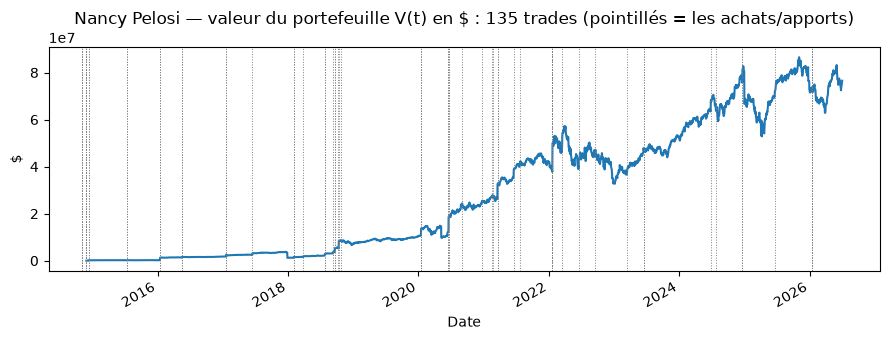

In [4]:
# Démo AUTO-SUFFISANTE : la VALEUR V(t) saute à chaque achat (apports + performance mélangés)
g_demo = df[df["bioguide_id"] == DEMO_BID]
Nm = member_shares(g_demo)
V = (Nm * pd.DataFrame({tk: prices[tk] for tk in Nm.columns})).sum(axis=1)
Va = V[Nm.sum(axis=1) > 0]
ax = Va.plot(figsize=(9, 3.5), color="tab:blue")
for d in g_demo.loc[g_demo["op"] == "buy", "traded"]:
    ax.axvline(d, color="gray", ls=":", lw=0.7)
ax.set_title(f"{DEMO} — valeur du portefeuille V(t) en $ : {len(g_demo)} trades (pointillés = les achats/apports)")
ax.set_ylabel("$"); plt.tight_layout(); plt.show()

In [5]:
# Démo AUTO-SUFFISANTE : le tableau N des parts détenues n_i(t), une colonne par ticker
Nm = member_shares(df[df["bioguide_id"] == DEMO_BID])
actifs = Nm[Nm.sum(axis=1) > 0]
ech = actifs.iloc[::max(1, len(actifs) // 8)].round(1)
print(f"{DEMO} — parts détenues n_i(t) : {actifs.shape[1]} tickers, {len(actifs)} jours actifs ({len(ech)} lignes échantillonnées)")
ech

Nancy Pelosi — parts détenues n_i(t) : 29 tickers, 2914 jours actifs (9 lignes échantillonnées)


,AA,AAPL,AB,AMZN,AVGO,AXP,BFET,CRM,CRWD,DBX,...,NVDA,PANW,PYPL,RHI,T,TSLA,TWO,V,VST,XYZ
Date,,,,,,,,,,,,,,,,,,,,,
2014-11-28,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2016-05-11,0.0,17109.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2017-10-19,0.0,61369.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3054.2
2019-04-03,0.0,52331.9,0.0,41799.8,0.0,0.0,0.0,0.0,0.0,12541.8,...,0.0,0.0,0.0,0.0,27704.0,0.0,0.0,0.0,0.0,3054.2
2020-09-11,0.0,0.0,0.0,65762.2,0.0,0.0,0.0,16262.9,23210.8,12541.8,...,0.0,0.0,9744.9,0.0,27704.0,0.0,0.0,0.0,0.0,3054.2
2022-02-22,0.0,37788.6,99050.9,65762.2,0.0,4995.8,0.0,16262.9,23210.8,12541.8,...,38480.1,0.0,18996.4,0.0,27704.0,0.0,0.0,0.0,0.0,3054.2
2023-08-04,0.0,40356.8,99050.9,65762.2,0.0,4995.8,0.0,16262.9,23210.8,12541.8,...,45962.5,0.0,7931.6,0.0,27704.0,4883.2,0.0,0.0,0.0,3054.2
2025-01-16,0.0,0.0,99050.9,65762.2,0.0,4995.8,0.0,16262.9,23210.8,12541.8,...,79517.3,16061.7,7931.6,0.0,27704.0,2829.3,0.0,0.0,0.0,3054.2
2026-07-01,0.0,0.0,99050.9,55988.8,12088.4,4995.8,0.0,16262.9,23210.8,12541.8,...,65608.2,16061.7,1546.3,0.0,27704.0,2829.3,0.0,0.0,1053.3,3054.2


## 2. Rendement d'un membre (*time-weighted*)
On valorise les parts de la **veille** $\Rightarrow$ un apport n'est jamais un rendement :
$$r_P(t) = \frac{\sum_i n_i(t-1)P_i(t)}{\sum_i n_i(t-1)P_i(t-1)} - 1$$
- Jour sans position : $r_P(t)=0$ (système ouvert). Winsorisation $\pm50\,\%$/jour.
- Série restreinte à la fenêtre [1er ; dernier jour actif] du membre ($T$ jours, le $n$ du §3-§4).
- Stats : $\mathrm{CAGR}=\mathrm{NAV}_T^{252/T}-1$ ; vol $=\sigma(r_P)\sqrt{252}$ ;
  Sharpe $=\dfrac{\overline{r_P}}{\sigma(r_P)}\sqrt{252}$ (brut, sans benchmark — distinct de l'IR du §4) ;
  maxDD $=\min_t(\mathrm{NAV}/\mathrm{NAV}^{\max}-1)$.
- $\mathrm{NAV}(t)=\prod_{s\le t}(1+r_P(s))$ : la **performance pure** (contrairement à $V(t)$ qui mélange les apports).

### Aperçu TOTAL : tous les membres d'un coup
On calcule la série de rendement de **chaque** membre une seule fois (réutilisée partout ensuite).
`member_shares`/`daily_return` sont cumulatifs $\Rightarrow$ tronquer à une date ne regarde jamais le futur.

In [6]:
wf_ret, wf_traded = {}, {}
for bid, g in df.groupby("bioguide_id"):
    N = member_shares(g)
    if N is None:
        continue
    r = daily_return(N)
    if len(r) < 2 or r.std() == 0:
        continue
    wf_ret[bid] = r
    wf_traded[bid] = pd.to_datetime(np.sort(g["traded"].values))
print(len(wf_ret), "membres avec une série de rendement")

266 membres avec une série de rendement


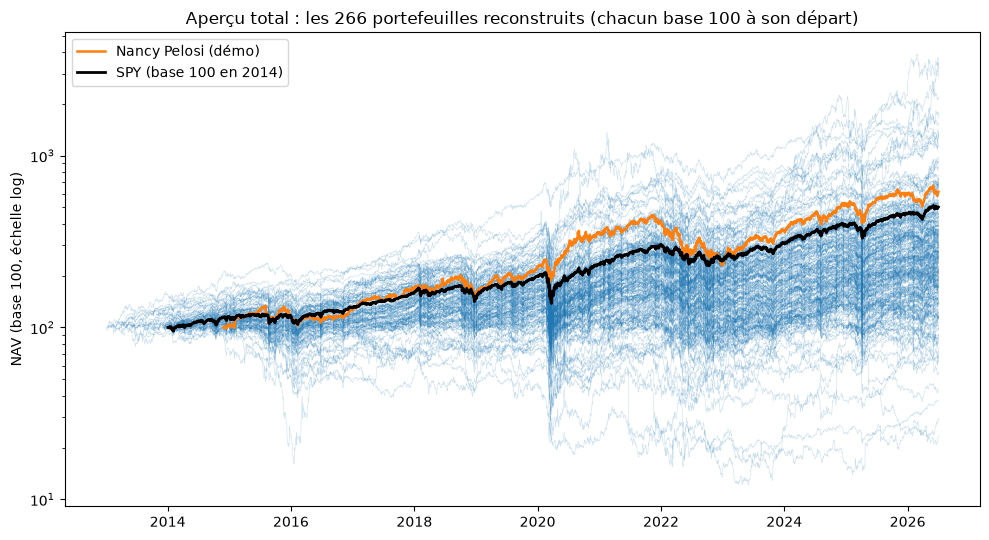

In [7]:
# VISUEL : la NAV de CHAQUE membre (base 100 à son premier jour actif), SPY en noir, démo en orange
plt.figure(figsize=(10, 5.5))
for bid, r in wf_ret.items():
    nav = 100 * (1 + r).cumprod()
    plt.plot(nav.index, nav.values, lw=0.4, alpha=0.22, color="tab:blue")
nav_demo = 100 * (1 + wf_ret[DEMO_BID]).cumprod()
plt.plot(nav_demo.index, nav_demo.values, lw=1.8, color="tab:orange", label=f"{DEMO} (démo)")
cal14 = cal[cal >= "2014-01-01"]
r14 = r_spy.reindex(cal14).fillna(0.0).copy(); r14.iloc[0] = 0.0     # base 100 exactement au 1er jour de 2014
nav_spy = 100 * (1 + r14).cumprod()
plt.plot(nav_spy.index, nav_spy.values, lw=2.0, color="k", label="SPY (base 100 en 2014)")
plt.yscale("log"); plt.ylabel("NAV (base 100, échelle log)")
plt.title(f"Aperçu total : les {len(wf_ret)} portefeuilles reconstruits (chacun base 100 à son départ)")
plt.legend(); plt.tight_layout(); plt.show()

In [8]:
# La distribution des stats sur TOUS les membres (le tableau de la population)
apercu = pd.DataFrame([{**stats(r), "n_days": len(r)} for r in wf_ret.values()])
print(f"la population : quartiles des stats des {len(apercu)} membres reconstruits")
apercu.describe().loc[["mean", "25%", "50%", "75%"]].round(3)

la population : quartiles des stats des 266 membres reconstruits


,cagr,vol,sharpe,maxdd,n_days
mean,0.147,0.254,0.683,-0.398,2078.812
25%,0.090,0.179,0.537,-0.460,1345.750
50%,0.129,0.215,0.709,-0.364,2270.000
75%,0.171,0.282,0.863,-0.310,3039.500


## 3. Qui est éligible ?
Un ratio de performance n'a de sens que sur assez de matière — un IR calculé sur 3 trades explose
(l'écart-type est minuscule) et ne veut rien dire. On ne garde donc que les membres avec :
$$n_{\text{trades}} \ge 10 \quad\text{et}\quad n_{\text{days}} \ge 126\ (\sim 6\ \text{mois}).$$

In [9]:
# Éligibilité PURE (pas encore d'IR) : on part des séries de rendement déjà calculées (wf_ret)
MIN_TRADES, MIN_DAYS = 10, 126
tab = pd.DataFrame([dict(bioguide_id=bid, name=df.loc[df.bioguide_id == bid, "name"].iloc[0],
                         n_trades=len(wf_traded[bid]), n_days=len(r))
                    for bid, r in wf_ret.items()])
elig = tab[(tab.n_trades >= MIN_TRADES) & (tab.n_days >= MIN_DAYS)].copy()
M = len(elig)
print(f"{len(tab)} membres avec historique -> {M} éligibles (>= {MIN_TRADES} trades ET >= {MIN_DAYS} jours)")

266 membres avec historique -> 223 éligibles (>= 10 trades ET >= 126 jours)


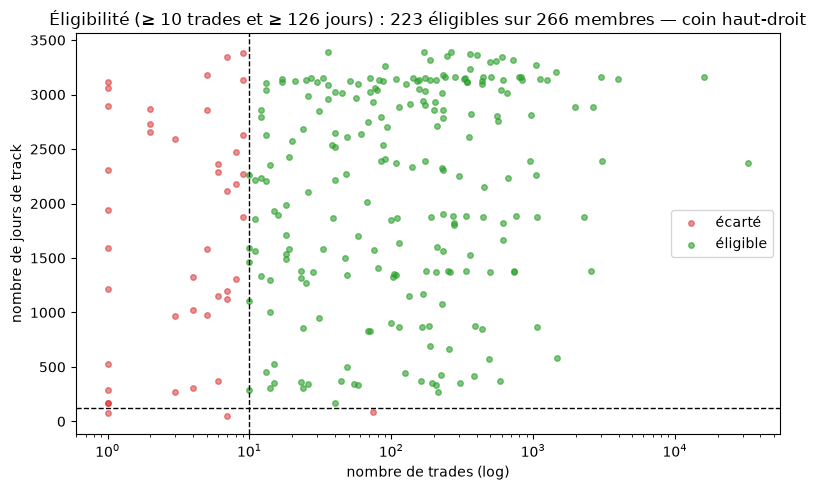

In [10]:
# VISUEL : qui passe la porte ? (n_trades en log x n_jours, la boîte d'éligibilité)
ok = (tab.n_trades >= MIN_TRADES) & (tab.n_days >= MIN_DAYS)
plt.figure(figsize=(8, 5))
plt.scatter(tab.n_trades[~ok], tab.n_days[~ok], s=16, alpha=0.5, color="tab:red", label="écarté")
plt.scatter(tab.n_trades[ok], tab.n_days[ok], s=16, alpha=0.6, color="tab:green", label="éligible")
plt.axvline(MIN_TRADES, color="k", ls="--", lw=1); plt.axhline(MIN_DAYS, color="k", ls="--", lw=1)
plt.xscale("log"); plt.xlabel("nombre de trades (log)"); plt.ylabel("nombre de jours de track")
plt.title(f"Éligibilité (≥ {MIN_TRADES} trades et ≥ {MIN_DAYS} jours) : {M} éligibles sur {len(tab)} membres — coin haut-droit")
plt.legend(); plt.tight_layout(); plt.show()

## 4. Qui bat le SPY — talent ou style ?
Deux critères, testés de la même façon (test $t$ unilatéral, seuil $1{,}645$) :

**Information Ratio** (suppose $\beta=1$) :
$$x(t)=r_P(t)-r_{SPY}(t),\quad \mathrm{IR}=\frac{\overline{x}}{\sigma(x)}\sqrt{252},\quad t=\mathrm{IR}\sqrt{n/252}\quad(n=\text{nb de jours de la série})$$

**Appraisal** (talent, marché retiré) — régression $r_P=\alpha+\beta\,r_{SPY}+\varepsilon$ :
$$\beta=\frac{\mathrm{Cov}(r_P,r_{SPY})}{\mathrm{Var}(r_{SPY})},\ \ \alpha=\overline{r_P}-\beta\,\overline{r_{SPY}},\ \ \text{appraisal}=\frac{\alpha}{\sigma(\varepsilon)}\sqrt{252},\ \ t_{\text{appr}}=\text{appraisal}\sqrt{n/252},\ \ \alpha_{\text{ann}}=(1+\alpha)^{252}-1$$

$\beta=1 \Rightarrow$ appraisal $=$ IR ; sinon l'IR mélange **exposition** (style) et **talent**.
⚠️ Sur $M=223$ tests **corrélés** (mêmes tickers, mêmes périodes), $\sim 11$ dépassements du seuil sont
attendus par pur hasard — et c'est une **borne basse** de l'incertitude (les tests ne sont pas indépendants).

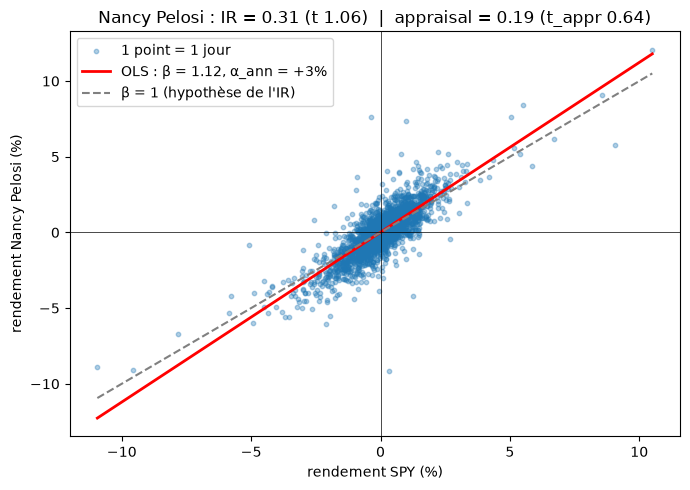

In [11]:
# Illustration AUTO-SUFFISANTE : la régression du membre démo décompose r_P en beta*SPY + alpha (+ résidu)
rm = daily_return(member_shares(df[df["bioguide_id"] == DEMO_BID]))
d = pd.concat([rm.rename("y"), r_spy.reindex(rm.index).rename("x")], axis=1).dropna()
beta, alpha = np.polyfit(d["x"], d["y"], 1)
ab = alpha_beta(rm)
ir = info_ratio(rm); t_ir = ir * np.sqrt(len(rm) / 252)
plt.figure(figsize=(7, 5))
plt.scatter(d["x"] * 100, d["y"] * 100, s=10, alpha=0.35, label="1 point = 1 jour")
xs = np.linspace(d["x"].min(), d["x"].max(), 50)
plt.plot(xs * 100, (alpha + beta * xs) * 100, color="red", lw=2,
         label=f"OLS : β = {beta:.2f}, α_ann = {ab['alpha_ann']:+.0%}")
plt.plot(xs * 100, xs * 100, color="gray", ls="--", label="β = 1 (hypothèse de l'IR)")
plt.axhline(0, color="k", lw=0.5); plt.axvline(0, color="k", lw=0.5)
plt.xlabel("rendement SPY (%)"); plt.ylabel(f"rendement {DEMO} (%)")
plt.title(f"{DEMO} : IR = {ir:.2f} (t {t_ir:.2f})  |  appraisal = {ab['appraisal']:.2f} (t_appr {ab['t_appr']:.2f})")
plt.legend(); plt.tight_layout(); plt.show()

### 4.1 Classement par l'IR
On classe les éligibles par IR et on garde les significatifs ($t>1{,}645$).

In [12]:
elig["IR"] = [info_ratio(wf_ret[b]) for b in elig.bioguide_id]
elig["t"]  = elig.IR * np.sqrt(elig.n_days / 252)
sig = elig[elig.t > 1.645]
print(f"les {len(sig)} membres significatifs par l'IR (t > 1,645) sur {M} éligibles, classés par IR — ~{0.05*M:.0f} attendus par pur hasard")
COLS_IR = ["name", "n_trades", "n_days", "IR", "t"]
sig.sort_values("IR", ascending=False).head(20)[COLS_IR].round(3).reset_index(drop=True)   # tous les significatifs

les 20 membres significatifs par l'IR (t > 1,645) sur 223 éligibles, classés par IR — ~11 attendus par pur hasard


,name,n_trades,n_days,IR,t
0,John Fetterman,10,284,2.482,2.635
1,Ashley Moody,23,364,1.670,2.007
2,Morgan McGarvey,24,853,1.502,2.764
3,Lisa McClain,1479,580,1.264,1.917
4,Daniel S Sullivan,100,904,0.999,1.892
5,Thomas Suozzi,662,2230,0.902,2.683
6,Barbara J Honorable Comstock,85,2390,0.899,2.769
7,MARK R WARNER,15,1934,0.800,2.218
8,David Kustoff,10,1595,0.793,1.994
9,Ron L Wyden,231,1568,0.770,1.920


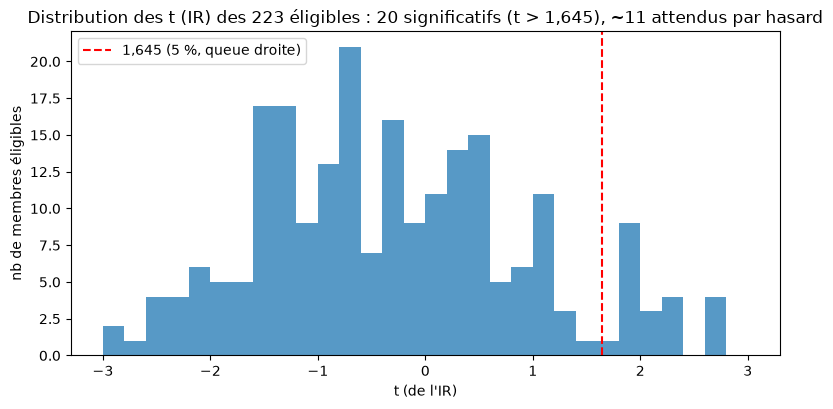

In [13]:
# FIGURE IR (style de référence, copié tel quel en 4.2) : distribution des t
BINS_T = np.linspace(-3, 3, 31)
plt.figure(figsize=(8, 4.2))
plt.hist(elig.t.dropna(), bins=BINS_T, alpha=0.75, color="tab:blue")
plt.axvline(1.645, color="red", ls="--", label="1,645 (5 %, queue droite)")
plt.xlabel("t (de l'IR)"); plt.ylabel("nb de membres éligibles")
plt.title(f"Distribution des t (IR) des {M} éligibles : {len(sig)} significatifs (t > 1,645), ~{0.05*M:.0f} attendus par hasard")
plt.legend(); plt.tight_layout(); plt.show()

### 4.2 Classement par l'appraisal
Exactement la même chose, mais sur le **talent** (β retiré) : on classe par appraisal, on garde $t_{\text{appr}}>1{,}645$.

In [14]:
abdf = pd.DataFrame([alpha_beta(wf_ret[b]) for b in elig.bioguide_id], index=elig.index)
elig = pd.concat([elig, abdf], axis=1)          # ajoute beta / alpha_ann / appraisal / t_appr
sig_appr = elig[elig.t_appr > 1.645]
print(f"les {len(sig_appr)} membres significatifs par l'appraisal (t_appr > 1,645) sur {M} éligibles, classés par appraisal — ~{0.05*M:.0f} attendus par pur hasard")
COLS_APPR = ["name", "n_trades", "n_days", "appraisal", "t_appr"]
sig_appr.sort_values("appraisal", ascending=False).head(12)[COLS_APPR].round(3).reset_index(drop=True)   # tous les significatifs

les 12 membres significatifs par l'appraisal (t_appr > 1,645) sur 223 éligibles, classés par appraisal — ~11 attendus par pur hasard


,name,n_trades,n_days,appraisal,t_appr
0,John Fetterman,10,284,2.242,2.380
1,Morgan McGarvey,24,853,1.081,1.988
2,Raul Ruiz,10,2261,0.802,2.401
3,Trey Hollingsworth,18,1494,0.790,1.924
4,Barbara J Honorable Comstock,85,2390,0.659,2.030
5,MARK R WARNER,15,1934,0.649,1.797
6,Brian Babin,20,2573,0.624,1.995
7,Thomas Suozzi,662,2230,0.589,1.752
8,Pete Sessions,361,3376,0.550,2.013
9,Suzan K. DelBene,158,3054,0.516,1.795


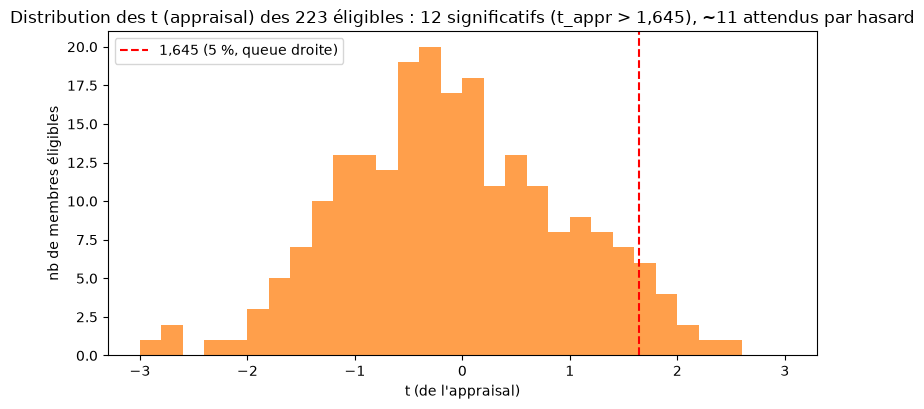

In [15]:
# FIGURE APPRAISAL (copie EXACTE du style de 4.1) : distribution des t_appr
plt.figure(figsize=(8, 4.2))
plt.hist(elig.t_appr.dropna(), bins=BINS_T, alpha=0.75, color="tab:orange")
plt.axvline(1.645, color="red", ls="--", label="1,645 (5 %, queue droite)")
plt.xlabel("t (de l'appraisal)"); plt.ylabel("nb de membres éligibles")
plt.title(f"Distribution des t (appraisal) des {M} éligibles : {len(sig_appr)} significatifs (t_appr > 1,645), ~{0.05*M:.0f} attendus par hasard")
plt.legend(); plt.tight_layout(); plt.show()

### 4.3 Le lien entre les deux
L'IR et l'appraisal ne diffèrent que par le **β**. Chaque point ci-dessous : son IR (vertical) contre
son appraisal (horizontal), coloré par β.

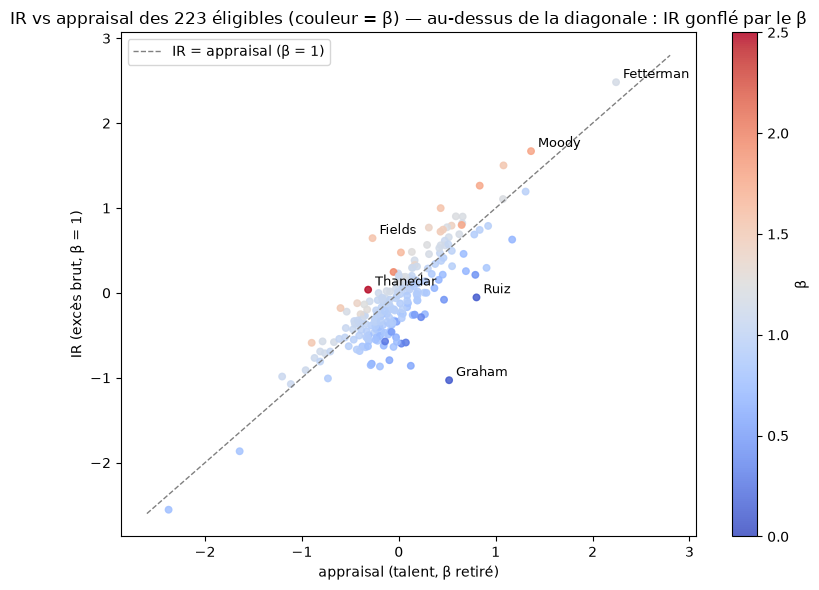

In [16]:
# FIGURE LIEN (le seul endroit où le beta paraît) : IR vs appraisal, couleur = beta
plt.figure(figsize=(8, 6))
sc = plt.scatter(elig.appraisal, elig.IR, c=elig.beta, cmap="coolwarm", vmin=0, vmax=2.5, s=22, alpha=0.85)
plt.colorbar(sc, label="β")
lim = [-2.6, 2.8]
plt.plot(lim, lim, color="gray", ls="--", lw=1, label="IR = appraisal (β = 1)")
for pat in ["Fetterman", "Moody", "Thanedar", "Fields", "Graham", "Ruiz"]:
    m = elig[elig.name.str.contains(pat, na=False)]
    if len(m):
        row = m.iloc[0]
        plt.annotate(pat, (row.appraisal, row.IR), fontsize=9, xytext=(5, 3), textcoords="offset points")
plt.xlabel("appraisal (talent, β retiré)"); plt.ylabel("IR (excès brut, β = 1)")
plt.title(f"IR vs appraisal des {M} éligibles (couleur = β) — au-dessus de la diagonale : IR gonflé par le β")
plt.legend(); plt.tight_layout(); plt.show()

## 5. Choisir qui copier chaque année (walk-forward, point-in-time)
À chaque fin d'année $Y$, on classe les éligibles *à la coupe* (seuils du §3 recalculés sur les données $\le 31/12/Y$)
par un **critère** et on garde les significatifs :
$$\mathrm{classement}(Y)=\{\text{éligibles}\ \wedge\ t_{\text{crit}}>1{,}645\}\ \text{triés par le critère},$$
top-$K$ suivi en $Y{+}1$ (s'il y a moins de $K$ significatifs, on copie tous les significatifs). Aucun regard vers le futur : $n_i(t)$ ne dépend que des trades $\le t$.
Même mécanique pour les **deux** critères (IR, appraisal) ; le choix du critère est étudié en §6.

⚠ Nuance (auditée) : la coupe tronque la série *pré-calculée* (`r.loc[:31/12/Y]`), dont la **fin de fenêtre**
(§2 : dernier jour actif) est connue *ex post* — un membre revenu à zéro position avant la coupe mais qui
re-trade après garde ses jours plats jusqu'à la coupe. Vérifié exhaustivement : 2 couples membre×coupe
concernés (Rouda 2019, Spartz 2024), aucun significatif, **aucun classement modifié** à aucune coupe.

In [17]:
def classement_a_fin(Y, min_trades=MIN_TRADES, min_days=MIN_DAYS, seuil_t=1.645, critere="ir"):
    """Classement point-in-time au 31/12/Y. critere = "ir" (excès/SPY) ou "appraisal" (régression β)."""
    yend = pd.Timestamp(f"{Y}-12-31")
    rows = []
    for bid, r in wf_ret.items():
        rr = r.loc[:yend]
        n_trades = int((wf_traded[bid] <= yend).sum())
        n_days = len(rr)
        if n_days < 2 or rr.std() == 0 or n_trades < min_trades or n_days < min_days:
            continue
        if critere == "ir":
            x = (rr - r_spy.reindex(rr.index)).dropna()
            if len(x) < 2 or x.std() == 0:
                continue
            score = x.mean() / x.std() * np.sqrt(252)
            t = score * np.sqrt(n_days / 252)
        else:                                            # appraisal : régression sur le seul passé <= Y
            ab = alpha_beta(rr)
            score, t = ab["appraisal"], ab["t_appr"]
            if not np.isfinite(t):
                continue
        if t <= seuil_t:
            continue
        rows.append(dict(bioguide_id=bid, name=df.loc[df.bioguide_id == bid, "name"].iloc[0],
                         n_trades=n_trades, n_days=n_days, score=score, t=t))
    cols = ["bioguide_id", "name", "n_trades", "n_days", "score", "t"]
    return (pd.DataFrame(rows).sort_values("score", ascending=False).reset_index(drop=True)
            if rows else pd.DataFrame(columns=cols))

# Les DEUX caches co-définis ici (jamais de sélection avant que son cache existe)
clsmt    = {Y: classement_a_fin(Y, critere="ir")        for Y in range(2014, 2027)}
clsmt_ap = {Y: classement_a_fin(Y, critere="appraisal") for Y in range(2014, 2027)}

def select_topK(Y, K, critere="ir"):
    cache = clsmt if critere == "ir" else clsmt_ap
    c = cache[Y] if Y in cache else classement_a_fin(Y, critere=critere)
    return list(zip(c["score"].head(K), c["bioguide_id"].head(K)))
print("classements point-in-time prêts (IR et appraisal, 2014-2026)")

classements point-in-time prêts (IR et appraisal, 2014-2026)


In [18]:
# TABLE SYMÉTRIQUE : nb de significatifs et tête du classement, par critère, à chaque coupe
def _tete(c): return c["name"].iloc[0].split()[-1] if len(c) else "-"
resume = pd.DataFrame([
    dict(fenetre=f"≤ {Y}", n_sig_IR=len(clsmt[Y]), n_sig_appr=len(clsmt_ap[Y]),
         tete_IR=_tete(clsmt[Y]), tete_appr=_tete(clsmt_ap[Y]))
    for Y in range(2014, 2027)])
print(f"les {len(resume)} coupes annuelles 2014-2026 : nb de significatifs et tête du classement, par critère")
resume

les 13 coupes annuelles 2014-2026 : nb de significatifs et tête du classement, par critère


,fenetre,n_sig_IR,n_sig_appr,tete_IR,tete_appr
0,≤ 2014,1,3,Reed,Reed
1,≤ 2015,4,4,McKinley,Chabot
2,≤ 2016,2,4,Long,Brooks
3,≤ 2017,4,4,Comstock,Khanna
4,≤ 2018,5,7,Heck,Heck
5,≤ 2019,8,11,Evans,Lee
6,≤ 2020,19,21,Beyer,Beyer
7,≤ 2021,13,10,Comstock,Heck
8,≤ 2022,7,7,DelBene,Coble
9,≤ 2023,12,12,Landsman,Sullivan


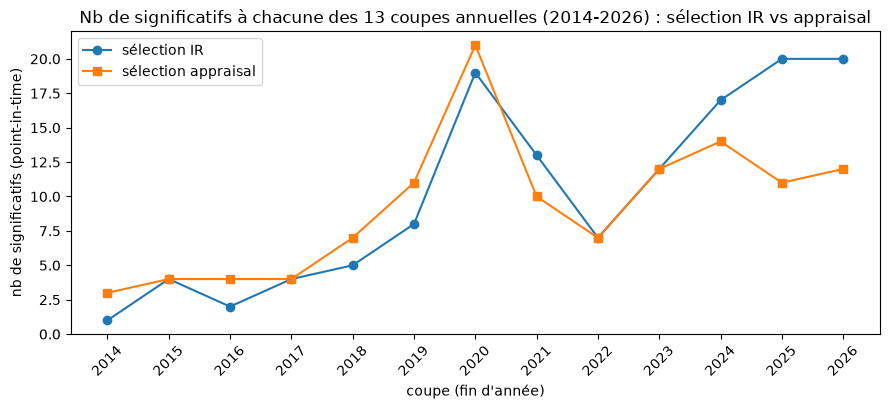

In [19]:
# FIGURE SYMÉTRIQUE : nb de significatifs par an, IR vs appraisal
annees = list(range(2014, 2027))
plt.figure(figsize=(9, 4.2))
plt.plot(annees, [len(clsmt[Y]) for Y in annees], marker="o", label="sélection IR")
plt.plot(annees, [len(clsmt_ap[Y]) for Y in annees], marker="s", label="sélection appraisal")
plt.xticks(annees, [str(y) for y in annees], rotation=45)
plt.ylabel("nb de significatifs (point-in-time)"); plt.xlabel("coupe (fin d'année)")
plt.title(f"Nb de significatifs à chacune des {len(annees)} coupes annuelles (2014-2026) : sélection IR vs appraisal")
plt.legend(); plt.tight_layout(); plt.show()

## 6. Le portefeuille de copy-trading top-$K$ (sélection IR ∥ appraisal) : bat-il le SPY ?
Chaque fin d'année, on copie les $K$ premiers membres du classement point-in-time (§5) — classés
par IR, ou par appraisal — et on tient le panier un an. Ici $K=4$ ; le choix de $K$ est étudié
au §7. Construction standard des fonds : méthode **unitisée** (parts et NAV), **buy-and-hold**
entre deux rebalancements.

### 6.1 La construction en parts
**Ingrédients.** Coupes de rebalancement $t^R_Y$ = dernier jour coté de l'année $Y$
($Y=2015,\dots,2025$) ; sélection $\mathcal{S}_Y$ = top-$K$ du classement point-in-time à la
coupe (§5) ; poids cibles égaux $w_k=\frac{1}{|\mathcal{S}_Y|}$ avec $|\mathcal{S}_Y|=\min(K,\ \text{nb de
significatifs à la coupe})$, $\sum_k w_k=1$ ; richesse initiale
$W(t^R_{2015})=100$.

**Chaque membre $k$ = un fonds**, dont le prix de part est sa NAV (rendement $r_k$ du §2) :
$$\mathrm{NAV}^k(t)=\prod_{s\le t}\big(1+r_k(s)\big)$$

**L'état du portefeuille = ses nombres de parts** $\mathrm{nbr}^k_Y$. À chaque coupe $t^R_Y$,
en fin de journée : (i) on **compte** la richesse disponible avec les anciennes parts, aux prix
du jour ; (ii) on la **redéploie** selon les poids cibles :
$$\text{(i)}\quad W(t^R_Y)=\!\!\sum_{k\in\mathcal{S}_{Y-1}}\!\!\mathrm{nbr}^k_{Y-1}\,\mathrm{NAV}^k(t^R_Y)
\qquad\qquad
\text{(ii)}\quad \mathrm{nbr}^k_Y=\frac{w_k\,W(t^R_Y)}{\mathrm{NAV}^k(t^R_Y)},\quad k\in\mathcal{S}_Y$$

**Entre deux coupes** ($t^R_Y<t\le t^R_{Y+1}$), les parts ne bougent pas — c'est le buy-and-hold
($\mathrm{NAV}$ sans exposant = le panier ; $\mathrm{NAV}^k$ = la NAV du §2 du membre $k$) :
$$\mathrm{NAV}(t)=\!\!\sum_{k\in\mathcal{S}_Y}\!\!\mathrm{nbr}^k_Y\,\mathrm{NAV}^k(t)
\qquad\Longrightarrow\qquad
\boxed{\;r_{\text{strat}}(t)=\frac{\mathrm{NAV}(t)}{\mathrm{NAV}(t-1)}-1\;}$$

**Deux propriétés.**
- **Autofinancement** : $\sum_{k\in\mathcal{S}_Y}\mathrm{nbr}^k_Y\,\mathrm{NAV}^k(t^R_Y)=W(t^R_Y)$
  (car $\sum_k w_k=1$) $\Rightarrow$ la NAV est **continue** à chaque coupe — aucun apport, aucun
  retrait, on ne fait que réallouer.
- **Poids effectifs dérivants** : $w_k(t)=\dfrac{\mathrm{nbr}^k_Y\,\mathrm{NAV}^k(t)}{\mathrm{NAV}(t)}
  \ne w_k$ dès le lendemain de la coupe. Les figer — $r_{\text{strat}}(t)=\sum_k w_k\,r_k(t)$ —
  reviendrait à rebalancer chaque jour (une stratégie *constant-mix*, pas du copier-et-tenir).

In [20]:
# Le prix de part de chaque membre-fonds, calculé UNE FOIS sur tout le calendrier
NAVK = pd.DataFrame({bid: (1 + r.reindex(cal).fillna(0.0)).cumprod() for bid, r in wf_ret.items()})

def _parts_engine(blocs, W0=100.0):
    """blocs = [(jours tenus, bids, poids initiaux)] chronologiques -> dict r / nav / journal."""
    W, rets, navs, journal = W0, [], [], []
    for idx, bids, w in blocs:
        tR = cal[cal.get_loc(idx[0]) - 1]                  # coupe = veille du 1er jour tenu (fin de journée)
        nbr = pd.Series(w * W / NAVK.loc[tR, bids].values, index=bids)   # nbr^k = w_k·W / NAV^k(tR)
        nav = NAVK.loc[idx, bids].mul(nbr, axis=1).sum(axis=1)           # NAV(t) = Σ nbr^k·NAV^k(t)
        r = nav / nav.shift(1) - 1
        r.iloc[0] = nav.iloc[0] / W - 1                    # 1er jour : contre la richesse redéployée
        journal.append(dict(rebal=tR, nbr=nbr, W_avant=W, W_apres=float(nav.iloc[-1])))
        W = float(nav.iloc[-1])                            # autofinancement -> coupe suivante
        rets.append(r); navs.append(nav)
    return dict(r=pd.concat(rets).sort_index(), nav=pd.concat(navs).sort_index(), journal=journal)

def _poids(sel, mode):
    if mode == "equal":
        return np.ones(len(sel)) / len(sel)
    sc = np.array([s for s, _ in sel])
    return sc / sc.sum() if sc.sum() > 0 else np.ones(len(sel)) / len(sel)

def strategie_en_parts(K, mode="equal", critere="ir", cadence="annuel"):
    """Sélections annuelles (§5) ou semestrielles ("6m" : requiert clsmt6_*/cuts/next_bound du §8), combinées en PARTS."""
    blocs = []
    if cadence == "annuel":
        for Y in range(2015, 2026):
            sel = select_topK(Y, K, critere=critere)
            idx = cal[cal.year == (Y + 1)]
            if sel and len(idx):
                blocs.append((idx, [b for _, b in sel], _poids(sel, mode)))
    else:                                                  # "6m" : coupes 30/06 & 31/12 du §8
        cache = clsmt6_ir if critere == "ir" else clsmt6_ap
        for d in cuts:
            c = cache[d]
            if len(c) == 0:
                continue
            sel = list(zip(c["score"].head(K), c["bioguide_id"].head(K)))
            idx = cal[(cal > d) & (cal <= next_bound(d))]
            if len(idx):
                blocs.append((idx, [b for _, b in sel], _poids(sel, mode)))
    return _parts_engine(blocs)

print(f"moteur en parts prêt | {NAVK.shape[1]} fonds-membres")

moteur en parts prêt | 266 fonds-membres


### 6.2 L'évaluation
**Excès par année civile** (1 année = 1 observation) :
$$x_Y=\prod_{t\in Y}\big(1+r_{\text{strat}}(t)\big)-\prod_{t\in Y}\big(1+r_{\text{SPY}}(t)\big),\qquad
\mathrm{IR}_{\text{ann}}=\frac{\overline{x}}{\sigma(x)},\qquad t=\mathrm{IR}_{\text{ann}}\sqrt{n}$$
Seuil unilatéral 5 % : $t_{10}\approx 1{,}81$ pour $n=11$ années (2026, partielle — données
jusqu'au 02/07/2026 — compte pour une observation).

**Même test qu'au §4** : $x$ = excès par période (jour au §4, année civile ici, semestre au §8),
$t=\overline{x}\big/\big(\sigma(x)/\sqrt{n}\big)$ avec $n$ = nombre de périodes — l'IR n'est que ce $t$
remis à l'échelle ($\mathrm{IR}=\sqrt{252}\,\overline{x}/\sigma$ en quotidien ;
$\mathrm{IR}_{\text{ann}}$, $\mathrm{IR}_{\text{sem}}=\overline{x}/\sigma$ par période).

**Ajustement au marché** — la régression du §4, appliquée à la série de la stratégie :
$$r_{\text{strat}}(t)=\alpha+\beta\,r_{\text{SPY}}(t)+\varepsilon(t),\qquad
\alpha_{\text{ann}}=(1+\alpha)^{252}-1$$
Si $\beta>1$, une part de l'excès brut n'est que de l'exposition au marché : $\alpha<$ excès brut.

In [21]:
# Évaluation par années civiles (1 année = 1 observation) + LA série de référence, calculée UNE fois
def yearly_excess(r):
    b = r_spy.reindex(r.index).fillna(0.0)
    return pd.Series({y: ((1 + r[r.index.year == y]).prod() - 1) - ((1 + b[r.index.year == y]).prod() - 1)
                      for y in sorted(set(r.index.year))})

def eval_yearly(r):
    e = yearly_excess(r); n = len(e); ir_an = e.mean() / e.std(ddof=1)
    return dict(exces_moyen=e.mean(), IR_annuel=ir_an, t=ir_an * np.sqrt(n), gagnantes=f"{int((e > 0).sum())}/{n}")

def _ligne(r):
    e = eval_yearly(r); a = alpha_beta(r)
    return dict(exces_an=e["exces_moyen"], t=e["t"], gagnantes=e["gagnantes"],
                beta=a["beta"], alpha_ann=a["alpha_ann"], t_appr=a["t_appr"])

det4    = strategie_en_parts(4, "equal", "ir")   # dict r / nav / journal — réutilisé par le zoom et la figure
r_dr_eq = det4["r"]
r_ap_eq = strategie_en_parts(4, "equal", "appraisal")["r"]   # 2e série de référence, réutilisée aux §7-§8
print(f"évaluation annuelle prête | séries top-4 (sélection IR et appraisal) : {len(yearly_excess(r_dr_eq))} années de tenue (2016-2026)")

évaluation annuelle prête | séries top-4 (sélection IR et appraisal) : 11 années de tenue (2016-2026)


### 6.3 Le résultat top-4
Cas de référence : $K=4$, poids égaux, rebalancement annuel (2016-2026), deux critères de sélection
(IR, appraisal). Tenue 2017, sélection IR : 2 significatifs seulement à la coupe (table du §5)
$\Rightarrow$ poids $1/2$ cette année-là, $1/4$ partout ailleurs.

**Comment lire la table.** Deux blocs de colonnes, deux mesures différentes :
- **excès/an, t, gagnantes** — sur les 11 **excès annuels** $x_Y=\prod_{t\in Y}(1+r_{\text{strat}})-\prod_{t\in Y}(1+r_{\text{SPY}})$ (§6.2), qui supposent $\beta=1$ (excès **brut** vs SPY) :
  - **excès/an** $=\overline{x}$, la moyenne des 11 ;
  - **t** $=\dfrac{\overline{x}}{\sigma(x)}\sqrt{11}$, seuil $1{,}81$ ;
  - **gagnantes** $=$ nombre d'années où $x_Y>0$ (sur 11) ; les autres sont **perdantes** (ex. $7/11 \Rightarrow$ 7 gagnantes, 4 perdantes).
- **β, α annualisé, t (appraisal)** — de la régression **quotidienne** $r_{\text{strat}}=\alpha+\beta\,r_{\text{SPY}}+\varepsilon$ (§4), qui **retire le β** ; $\alpha_{\text{ann}}=(1+\alpha)^{252}-1$.

⚠️ Les deux blocs ne disent pas la même chose : l'excès brut $+3{,}1\,\%$ (sél IR) devient $\alpha\approx 0$ une fois le $\beta=1{,}20$ retiré — c'était du **style de marché**, pas du talent.

In [22]:
# LES MÉTRIQUES du top-4, par critère de sélection (mêmes colonnes que les tables des §7-§8)
print(f"top-4 (poids 1/4, rebalancement annuel) — {len(yearly_excess(r_dr_eq))} années civiles, seuil t₁₀ ≈ 1,81")
pd.DataFrame({
    "sélection IR":        _ligne(r_dr_eq),
    "sélection appraisal": _ligne(r_ap_eq),
}).T.round(3)

top-4 (poids 1/4, rebalancement annuel) — 11 années civiles, seuil t₁₀ ≈ 1,81


,exces_an,t,gagnantes,beta,alpha_ann,t_appr
sélection IR,0.027909,0.797518,7/11,1.211435,-0.010845,-0.310296
sélection appraisal,-0.025324,-1.246978,3/11,1.009594,-0.02295,-0.757885


⚠️ **Rétrospectif vs temps réel.** Les classements du §4 sont calculés sur **tout** l'historique
(photo après coup) ; ici la sélection n'utilise que le **passé disponible** à chaque coupe, et on
mesure l'année **suivante**. Un excès négatif ici, alors que les appraisals du §4.2 sont positifs,
signifie simplement que le talent passé ne se **répète pas** l'année d'après.

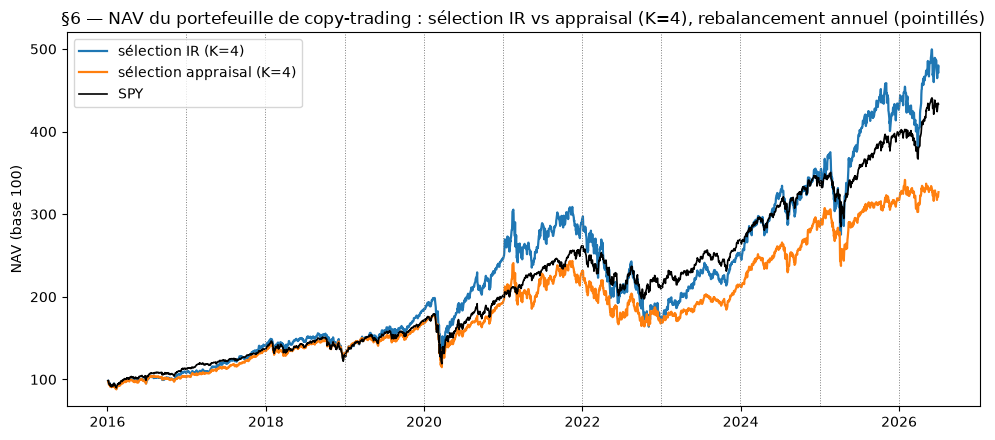

In [23]:
# FIGURE : NAV du portefeuille de copy-trading (base 100) — sélection IR vs appraisal (K=4)
nav_ir = 100 * (1 + r_dr_eq).cumprod()
nav_ap = 100 * (1 + r_ap_eq).cumprod()
nav_sp = 100 * (1 + r_spy.reindex(nav_ir.index).fillna(0)).cumprod()
plt.figure(figsize=(10, 4.5))
plt.plot(nav_ir, label="sélection IR (K=4)", lw=1.6)
plt.plot(nav_ap, label="sélection appraisal (K=4)", lw=1.6)
plt.plot(nav_sp, label="SPY", color="k", lw=1.2)
for j in det4["journal"][1:]:
    plt.axvline(j["rebal"], color="gray", ls=":", lw=0.7)          # rebalancements : la NAV en parts reste continue
plt.ylabel("NAV (base 100)")
plt.title("§6 — NAV du portefeuille de copy-trading : sélection IR vs appraisal (K=4), rebalancement annuel (pointillés)")
plt.legend(); plt.tight_layout(); plt.show()

### Carte des expériences (§7–§10)

$$\star\;=\;\big(\text{sélection IR}\,\|\,\text{appraisal},\ \ K=4\ \text{fixe},\ \ \text{rebalancement annuel},\ \ w=1/K,\ \ \Sigma=\hat\Sigma^{\text{emp}}\big)\qquad(=\ \text{la ligne du §6.3}).$$

| § | axe qu'il fait varier | valeurs testées | le reste |
|---|---|---|---|
| §7 | $K$ (nb de membres copiés) | $4$ fixe vs walk-forward $\in[4,20]$ | $=\star$ |
| §8 | cadence | annuel vs 6 mois | rejoue les 4 stratégies du §7 |
| §9 | poids $w$ | $1/K$, inverse-vol, ERC, GMV | $K=4$ fixe ; annuel **et** 6 mois |
| §10 | estimateur de $\Sigma$ | cov brute vs Ledoit-Wolf (3 cibles) | $K=4$ fixe ; ERC/GMV ; annuel **et** 6 mois |

- **Un axe à la fois, jamais combinés** (pas de $K$ walk-forward × inverse-vol) : chaque table se lit contre la même baseline $\star$, répétée en 1re ligne.
- ⚠ Le symbole $K$ : **nombre** de membres copiés (l'axe du §7) $\neq$ « $1/K$ » $=$ nom du schéma de **poids égaux** (l'axe du §9). Deux choses différentes.

## 7. Combien copier ? (le choix de $K$)
On construit les stratégies pour tout $K\in[4,20]$, puis on choisit $K$ **honnêtement** (sans regard
futur), avec **le critère de la sélection lui-même** :
$$K^*(Y)=\arg\max_K \;\mathrm{score}_{\text{crit}}\big(\text{strat-}K\big|_{\le Y}\big),\quad
\mathrm{score}_{\text{crit}}=\begin{cases}\mathrm{IR}_{\text{quotidien}}&\text{sélection IR}\\
\text{appraisal}_{\text{quotidien}}&\text{sélection appraisal}\end{cases}$$
$K=4$ par défaut sans historique ; à égalité de score (fréquent quand $n_{\text{sig}}<K$ : les
stratégies coïncident), on prend le plus petit $K$. Le **tableau** ci-dessous donne le $K$ appliqué **chaque année de tenue** (choisi à la coupe de fin d'année précédente) et l'excès
réalisé cette année-là ; puis on compare **$K=4$ fixe** à
**$K$ walk-forward**, pour les deux sélections.

In [24]:
# Précalcul des séries-K, PAR CRITÈRE DE SÉLECTION (poids 1/K fixé)
KS = list(range(4, 21))
R_K_ir = {K: strategie_en_parts(K, "equal", "ir")["r"]        for K in KS}
R_K_ap = {K: strategie_en_parts(K, "equal", "appraisal")["r"] for K in KS}
print(f"{2*len(KS)} séries-K prêtes (sélection IR et appraisal)")

34 séries-K prêtes (sélection IR et appraisal)


In [25]:
# K walk-forward : chaque critère choisit K avec SON PROPRE mètre (IR ou appraisal quotidien)
def score_ir(r):
    x = (r - r_spy.reindex(r.index)).dropna()
    return x.mean() / x.std() * np.sqrt(252) if x.std() > 0 else -np.inf

def score_appr(r):
    a = alpha_beta(r)["appraisal"]           # appraisal = alpha risque-ajusté de la stratégie vs SPY
    return a if np.isfinite(a) else -np.inf

def k_walk_forward(RbyK, score):
    parts, rows = [], []
    for Y in range(2015, 2026):
        if Y == 2015:
            k_star = 4                                    # aucun historique
        else:
            fin = pd.Timestamp(f"{Y}-12-31")
            sc = {K: score(RbyK[K].loc[:fin]) for K in KS}
            best = max(sc.values()); k_star = min(K for K in KS if sc[K] == best)
        ry = RbyK[k_star][RbyK[k_star].index.year == Y + 1]
        parts.append(ry)
        b = r_spy.reindex(ry.index).fillna(0.0)
        rows.append(dict(annee_tenue=Y + 1, K_choisi=k_star,
                         exces_realise=((1 + ry).prod() - 1) - ((1 + b).prod() - 1)))
    return pd.concat(parts).sort_index(), pd.DataFrame(rows)

r_wfK_eq, chemin_ir = k_walk_forward(R_K_ir, score_ir)     # sélection IR  -> K par IR
r_wfK_ap, chemin_ap = k_walk_forward(R_K_ap, score_appr)   # sélection appr -> K par appraisal
print("walk-forward K prêt (IR par IR, appraisal par appraisal)")

walk-forward K prêt (IR par IR, appraisal par appraisal)


In [26]:
# TABLEAU : le K retenu CHAQUE ANNÉE par le walk-forward (il change d'une année à l'autre)
pct = lambda x: f"{x:+.1%}".replace("-", "−").replace(".", ",")
tabK = pd.DataFrame({
    "K (sél IR)":           chemin_ir.set_index("annee_tenue")["K_choisi"],
    "excès réalisé (IR)":   chemin_ir.set_index("annee_tenue")["exces_realise"].map(pct),
    "K (sél appraisal)":    chemin_ap.set_index("annee_tenue")["K_choisi"],
    "excès réalisé (appr)": chemin_ap.set_index("annee_tenue")["exces_realise"].map(pct),
})
tabK.index.name = "année tenue"
print(f"le K retenu chaque année par le walk-forward (K ∈ [{KS[0]}, {KS[-1]}]) et l'excès réalisé cette année-là — {len(tabK)} années de tenue")
tabK

le K retenu chaque année par le walk-forward (K ∈ [4, 20]) et l'excès réalisé cette année-là — 11 années de tenue


,K (sél IR),excès réalisé (IR),K (sél appraisal),excès réalisé (appr)
année tenue,,,,
2016,4,"−4,2%",4,"−9,6%"
2017,4,"+8,5%",4,"+9,7%"
2018,4,"−1,4%",4,"+2,8%"
2019,4,"+7,6%",4,"−4,4%"
2020,4,"+15,9%",7,"+1,6%"
2021,8,"−6,1%",11,"−9,8%"
2022,18,"−9,9%",20,"−3,7%"
2023,12,"+12,1%",20,"+6,2%"
2024,18,"+4,4%",20,"+1,0%"


In [27]:
# Comparaison : K = 4 fixe vs K walk-forward, pour chaque critère de sélection
print(f"K=4 fixe vs K walk-forward, par critère de sélection — {len(yearly_excess(r_dr_eq))} années, seuil t₁₀ ≈ 1,81")
pd.DataFrame({
    "K=4 fixe (sél IR)":              _ligne(r_dr_eq),
    "K walk-forward (sél IR)":        _ligne(r_wfK_eq),
    "K=4 fixe (sél appraisal)":       _ligne(r_ap_eq),
    "K walk-forward (sél appraisal)": _ligne(r_wfK_ap),
}).T.round(3)

K=4 fixe vs K walk-forward, par critère de sélection — 11 années, seuil t₁₀ ≈ 1,81


,exces_an,t,gagnantes,beta,alpha_ann,t_appr
K=4 fixe (sél IR),0.027909,0.797518,7/11,1.211435,-0.010845,-0.310296
K walk-forward (sél IR),0.04059,1.580932,7/11,1.168338,0.011438,0.443818
K=4 fixe (sél appraisal),-0.025324,-1.246978,3/11,1.009594,-0.02295,-0.757885
K walk-forward (sél appraisal),-0.010029,-0.546117,5/11,0.97328,-0.005835,-0.292165


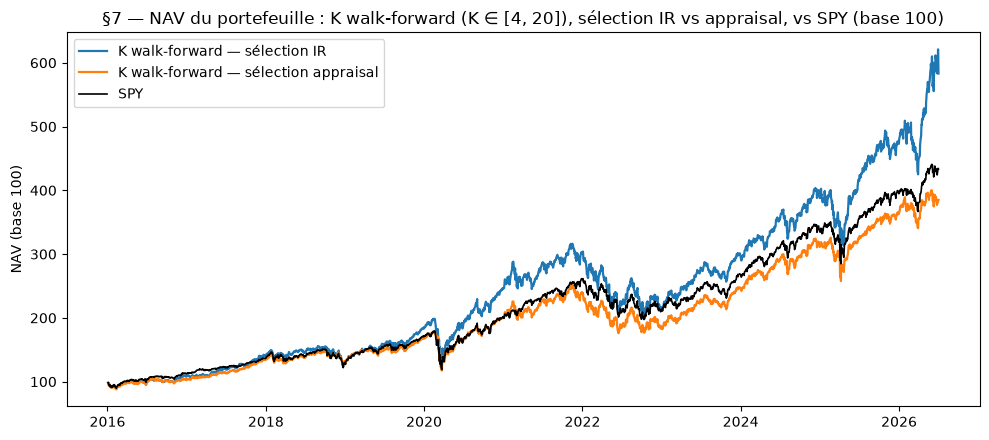

In [28]:
# FIGURE : NAV du portefeuille — K choisi en WALK-FORWARD (sélection IR vs appraisal) vs SPY (base 100)
nav_wf_ir = 100 * (1 + r_wfK_eq).cumprod()
nav_wf_ap = 100 * (1 + r_wfK_ap).cumprod()
idx = nav_wf_ir.index.union(nav_wf_ap.index)
nav_wf_sp = 100 * (1 + r_spy.reindex(idx).fillna(0)).cumprod()
plt.figure(figsize=(10, 4.5))
plt.plot(nav_wf_ir, label="K walk-forward — sélection IR", lw=1.6)
plt.plot(nav_wf_ap, label="K walk-forward — sélection appraisal", lw=1.6)
plt.plot(nav_wf_sp, label="SPY", color="k", lw=1.2)
plt.ylabel("NAV (base 100)")
plt.title(f"§7 — NAV du portefeuille : K walk-forward (K ∈ [{KS[0]}, {KS[-1]}]), sélection IR vs appraisal, vs SPY (base 100)")
plt.legend(); plt.tight_layout(); plt.show()

## 8. Et si on rééquilibre tous les 6 mois ?
Même logique qu'aux §5-§7, mais on **re-sélectionne 2× par an** : coupe au **30/06** et au **31/12**, on
tient le **semestre suivant**. Rien ne change au portefeuille des membres — seule la **cadence** de
sélection/tenue change, et l'évaluation passe à l'**excès par semestre** :
$$\mathrm{IR}_{\text{sem}}=\frac{\overline{x_{\text{sem}}}}{\sigma(x_{\text{sem}})},\qquad
t=\mathrm{IR}_{\text{sem}}\sqrt{n},\quad n\approx 22\ \text{semestres (au lieu de 11 ans)}.$$
Le seuil de significativité (unilatéral 5 %) passe donc à **$t>1{,}72$** (au lieu de 1,81).
Dans la table, excès/an $=2\,\overline{x}_{\text{sem}}$ (annualisation arithmétique, pour comparer
au §7 ; $t$ et gagnantes restent calculés sur les semestres). Le semestriel commence un semestre
plus tôt (S2-2015, première coupe au 30/06/2015) que l'annuel (2016) — d'où $n=22$. On rejoue les
**mêmes 4 stratégies qu'au §7** (K=4 et K walk-forward, sélection IR ∥ appraisal), mais à 6 mois —
à comparer ligne à ligne au tableau annuel du §7.

In [29]:
# --- Coupes SEMESTRIELLES : 30/06 & 31/12, classements point-in-time ; combinaison = moteur en parts du §6 ---
def classement_a_date(d, min_trades=MIN_TRADES, min_days=MIN_DAYS, seuil_t=1.645, critere="ir"):
    """classement_a_fin, mais à une DATE de coupe quelconque (point-in-time strict <= d)."""
    rows = []
    for bid, r in wf_ret.items():
        rr = r.loc[:d]
        n_trades = int((wf_traded[bid] <= d).sum()); n_days = len(rr)
        if n_days < 2 or rr.std() == 0 or n_trades < min_trades or n_days < min_days:
            continue
        if critere == "ir":
            x = (rr - r_spy.reindex(rr.index)).dropna()
            if len(x) < 2 or x.std() == 0:
                continue
            score = x.mean() / x.std() * np.sqrt(252); t = score * np.sqrt(n_days / 252)
        else:
            ab = alpha_beta(rr); score, t = ab["appraisal"], ab["t_appr"]
            if not np.isfinite(t):
                continue
        if t <= seuil_t:
            continue
        rows.append(dict(bioguide_id=bid, score=score))
    return (pd.DataFrame(rows).sort_values("score", ascending=False).reset_index(drop=True)
            if rows else pd.DataFrame(columns=["bioguide_id", "score"]))

cuts = [pd.Timestamp(y, m, dd) for y in range(2015, 2026) for (m, dd) in [(6, 30), (12, 31)]]
next_bound = lambda d: pd.Timestamp(d.year, 12, 31) if d.month == 6 else pd.Timestamp(d.year + 1, 6, 30)
clsmt6_ir = {d: classement_a_date(d, critere="ir")        for d in cuts}
clsmt6_ap = {d: classement_a_date(d, critere="appraisal") for d in cuts}

def eval_sem(r):
    b = r_spy.reindex(r.index).fillna(0.0)
    sem = r.index.year.values * 2 + (r.index.month.values > 6).astype(int)
    e = pd.Series({s: ((1 + r[sem == s]).prod() - 1) - ((1 + b[sem == s]).prod() - 1) for s in sorted(set(sem))})
    n = len(e); ir = e.mean() / e.std(ddof=1)
    return dict(exces_an=2 * e.mean(), t=ir * np.sqrt(n), gagnantes=f"{int((e > 0).sum())}/{n}", n=n)

def _ligne6(r):
    e = eval_sem(r); a = alpha_beta(r)
    return dict(exces_an=e["exces_an"], t=e["t"], gagnantes=e["gagnantes"],
                beta=a["beta"], alpha_ann=a["alpha_ann"], t_appr=a["t_appr"])

r_6m_ir = strategie_en_parts(4, "equal", "ir",        "6m")["r"]
r_6m_ap = strategie_en_parts(4, "equal", "appraisal", "6m")["r"]
print(f"coupes semestrielles prêtes | {len(cuts)} coupes | n semestres : IR={eval_sem(r_6m_ir)['n']}, appr={eval_sem(r_6m_ap)['n']}")

coupes semestrielles prêtes | 22 coupes | n semestres : IR=22, appr=22


In [30]:
# CHOIX DE K à 6 mois : séries-K semestrielles + K walk-forward (critère apparié comme §7)
R_K6_ir = {K: strategie_en_parts(K, "equal", "ir",        "6m")["r"] for K in KS}
R_K6_ap = {K: strategie_en_parts(K, "equal", "appraisal", "6m")["r"] for K in KS}

def k_walk_forward_6m(RbyK, score):
    parts = []
    for j, d in enumerate(cuts):
        if j == 0:
            k_star = 4                                   # pas d'historique de stratégie
        else:
            sc = {K: score(RbyK[K].loc[:d]) for K in KS}
            best = max(sc.values()); k_star = min(K for K in KS if sc[K] == best)
        idx = cal[(cal > d) & (cal <= next_bound(d))]
        parts.append(RbyK[k_star].reindex(idx).dropna())
    return pd.concat(parts).sort_index()

r_wfK6_ir = k_walk_forward_6m(R_K6_ir, score_ir)
r_wfK6_ap = k_walk_forward_6m(R_K6_ap, score_appr)
print(f"6 mois — {eval_sem(r_6m_ir)['n']} semestres, seuil t ≈ 1,72 ; mêmes 4 stratégies qu'au §7 (annuel), à comparer ligne à ligne")
pd.DataFrame({
    "K=4 fixe (sél IR) — 6 mois":              _ligne6(r_6m_ir),
    "K walk-forward (sél IR) — 6 mois":        _ligne6(r_wfK6_ir),
    "K=4 fixe (sél appraisal) — 6 mois":       _ligne6(r_6m_ap),
    "K walk-forward (sél appraisal) — 6 mois": _ligne6(r_wfK6_ap),
}).T.round(3)

6 mois — 22 semestres, seuil t ≈ 1,72 ; mêmes 4 stratégies qu'au §7 (annuel), à comparer ligne à ligne


,exces_an,t,gagnantes,beta,alpha_ann,t_appr
K=4 fixe (sél IR) — 6 mois,0.005099,0.163757,12/22,1.244305,-0.024081,-0.622038
K walk-forward (sél IR) — 6 mois,0.023024,0.806322,13/22,1.178429,-0.002499,-0.088456
K=4 fixe (sél appraisal) — 6 mois,-0.050265,-2.00158,8/22,1.04774,-0.050658,-1.481685
K walk-forward (sél appraisal) — 6 mois,-0.031043,-1.610211,9/22,1.025631,-0.032209,-1.425404


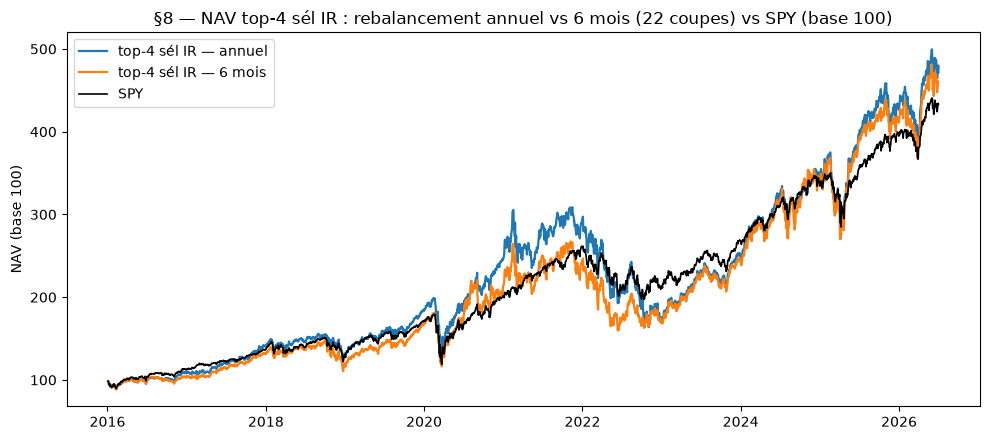

In [31]:
# FIGURE : NAV rééquilibrage annuel vs 6 mois (top-4 sél IR) vs SPY, base commune
start = max(r_dr_eq.index.min(), r_6m_ir.index.min())
a = r_dr_eq[r_dr_eq.index >= start]; m = r_6m_ir[r_6m_ir.index >= start]
nav9_an = 100 * (1 + a).cumprod(); nav9_6m = 100 * (1 + m).cumprod()
ix = nav9_an.index.union(nav9_6m.index)
nav9_sp = 100 * (1 + r_spy.reindex(ix).fillna(0)).cumprod()
plt.figure(figsize=(10, 4.5))
plt.plot(nav9_an, label="top-4 sél IR — annuel", lw=1.6)
plt.plot(nav9_6m, label="top-4 sél IR — 6 mois", lw=1.6)
plt.plot(nav9_sp, label="SPY", color="k", lw=1.2)
plt.ylabel("NAV (base 100)"); plt.title(f"§8 — NAV top-4 sél IR : rebalancement annuel vs 6 mois ({len(cuts)} coupes) vs SPY (base 100)")
plt.legend(); plt.tight_layout(); plt.show()

## 9. Pondérer autrement que $1/K$ — inverse-vol, ERC, GMV

$$\underbrace{1/K}_{\sigma\ \text{égales},\ \rho=0}\ \subset\ \underbrace{\text{inverse-vol}}_{\sigma\ \text{libres},\ \rho=0}\ \subset\ \underbrace{\{\text{ERC},\ \text{GMV}\}}_{\Sigma\ \text{complète}}\ \subset\ \underbrace{\text{Markowitz}}_{+\,\mu}$$

**Cadre.** $K$ membres, $w=(w_k)$, **long-only** $w_k\ge0$, **investi** $\mathbf 1^\top w=1$ ; $\ \Sigma_{ij}=\rho_{ij}\sigma_i\sigma_j$, $\ \sigma_p^2=w^\top\Sigma\,w$. Tout ($\sigma_k,\Sigma$) est estimé **point-in-time** ($s\le t^R$) et appliqué à $Y{+}1$. Le moteur en parts (§6.1) est inchangé : seul $w$ change.

**Inverse-vol** — $\sigma_k$ seuls, corrélations ignorées :
$$\boxed{\;w_k=\frac{1/\sigma_k}{\sum_{j}1/\sigma_j}\;}\qquad \sigma_k=\mathrm{std}\big(r_k(s)\big)_{s\le t^R}\,\sqrt{252}.$$

**ERC** — contributions au risque égales, $\ \mathrm{RC}_k=w_k(\Sigma w)_k$, $\ \sum_k\mathrm{RC}_k=w^\top\Sigma w$ :
$$\boxed{\;w_k(\Sigma w)_k=w_j(\Sigma w)_j\quad\forall k,j\;}$$

**GMV** — variance minimale, long-only :
$$\boxed{\;w^\star=\arg\min_{\mathbf 1^\top w=1,\;w\ge0}\ w^\top\Sigma\,w\;}\qquad\Big(\text{non contraint : }w^\star=\tfrac{\Sigma^{-1}\mathbf 1}{\mathbf 1^\top\Sigma^{-1}\mathbf 1}\ ;\quad \Sigma\ \text{diagonale}\Rightarrow w_k\propto 1/\sigma_k^2\Big)$$

Emboîtement : ERC $\to$ inverse-vol si $\rho$ constant $\to 1/K$ si $\Sigma=\sigma^2 I$.

| méthode | info utilisée | poids |
|---|---|---|
| $1/K$ | — | $1/K$ |
| inverse-vol | $\sigma_k$ | $\propto 1/\sigma_k$ |
| ERC | $\Sigma$ | $\mathrm{RC}_k$ égaux |
| GMV | $\Sigma$ | $\propto \Sigma^{-1}\mathbf 1$ |

In [32]:
# §9 — POIDS ALTERNATIFS : les primitives (fenêtre PIT, Σ, GMV, ERC, w_*) vivent dans
# tools.membre.moteur — exposées par l'amorçage. Estimation point-in-time (rendements <= tR).
print("poids alternatifs prets | inverse-vol, GMV, ERC (long-only, point-in-time, covariance d'échantillon)")


poids alternatifs prets | inverse-vol, GMV, ERC (long-only, point-in-time, covariance d'échantillon)


In [33]:
# §9 — orchestrateur : clone EXACT de strategie_en_parts (annuel), mais tR calcule par bloc -> weight_fn(bids, tR)
def strategie_ponderee(K, weight_fn, critere="ir"):
    blocs = []
    for Y in range(2015, 2026):
        sel = select_topK(Y, K, critere=critere)
        idx = cal[cal.year == (Y + 1)]
        if sel and len(idx):
            bids = [b for _, b in sel]
            tR = cal[cal.get_loc(idx[0]) - 1]            # coupe = veille du 1er jour tenu (IDENTIQUE au moteur)
            blocs.append((idx, bids, weight_fn(bids, tR)))
    return _parts_engine(blocs)

# GARDE-FOU de non-regression : w_equal doit reproduire les series 1/K du §6 bit-a-bit
assert np.allclose(strategie_ponderee(4, w_equal, "ir")["r"].values,        r_dr_eq.values), "w_equal != 1/K (IR)"
assert np.allclose(strategie_ponderee(4, w_equal, "appraisal")["r"].values, r_ap_eq.values), "w_equal != 1/K (appraisal)"
print("orchestrateur OK | w_equal reproduit exactement le portefeuille 1/K du §6 (les nouvelles ponderations ne changent QUE le vecteur w)")

orchestrateur OK | w_equal reproduit exactement le portefeuille 1/K du §6 (les nouvelles ponderations ne changent QUE le vecteur w)


In [34]:
# §9 — SANITY maths sur l'exemple de la note (sigma = 12/18/36 %) : les identites doivent tenir
_s  = np.array([.12, .18, .36])
_iv = (1 / _s) / (1 / _s).sum()
assert np.allclose(_iv, [.5, 1/3, 1/6], atol=1e-3)                                   # inverse-vol = 50/33/17 %
assert np.allclose(_iv * _s, (_iv * _s)[0], atol=1e-6)                               # budget de risque EGAL si rho=0
assert np.allclose(_gmv_from_cov(np.diag(_s ** 2)), (1/_s**2)/(1/_s**2).sum(), atol=2e-3)  # GMV_rho0 -> inverse-VARIANCE
for _rho in (0., .4, .8):                                                            # ERC -> inverse-vol si rho constant
    _Sig = np.outer(_s, _s) * ((1 - _rho) * np.eye(3) + _rho)
    assert np.allclose(_erc_from_cov(_Sig, _iv), _iv, atol=3e-3)
assert np.allclose(_erc_from_cov(np.eye(3), np.ones(3)/3), [1/3, 1/3, 1/3], atol=1e-3)     # sigma EGAL -> 1/K
_gmv_A = ((1/_s**2)/(1/_s**2).sum())[0]
print(f"sanity OK | membre calme A : 1/K {1/3:.3f} -> inverse-vol {_iv[0]:.3f} -> GMV_rho0 {_gmv_A:.3f}  (note: 0,333 / 0,500 / 0,643)")

sanity OK | membre calme A : 1/K 0.333 -> inverse-vol 0.500 -> GMV_rho0 0.643  (note: 0,333 / 0,500 / 0,643)


### 9.1 Résultat top-4 (annuel, puis 6 mois)

Base = **top-4 fixe** du §6.3 ($K=4$ — **pas** le $K$ walk-forward du §7) ; sélection des membres = classements point-in-time du §5 ; on ne change que $w$. Annuel : 11 années, seuil $t_{10}\approx1{,}81$ ; 6 mois : 22 semestres, seuil $\approx1{,}72$ (§8). Colonnes = §6.3/§7.

In [35]:
# §9 — series top-4 (annuel) par ponderation x critere de selection, puis TABLE (format identique §6.3/§7)
_paires = [("inverse-vol", w_invvol), ("ERC", w_erc), ("GMV", w_gmv)]
_ser = {("1/K", cr): (r_dr_eq if cr == "ir" else r_ap_eq) for cr in ("ir", "appraisal")}
for _nom, _fn in _paires:
    for _cr in ("ir", "appraisal"):
        _ser[(_nom, _cr)] = strategie_ponderee(4, _fn, _cr)["r"]

_cr_lbl = {"ir": "sel IR", "appraisal": "sel appr"}
print("top-4 fixe (K=4), rebalancement annuel — ponderation x critere de selection ; seuil t10 ≈ 1,81")
pd.DataFrame({f"{_nom} ({_cr_lbl[_cr]})": _ligne(_ser[(_nom, _cr)])
              for _cr in ("ir", "appraisal")
              for _nom in ["1/K", "inverse-vol", "ERC", "GMV"]}).T.round(3)

top-4 fixe (K=4), rebalancement annuel — ponderation x critere de selection ; seuil t10 ≈ 1,81


,exces_an,t,gagnantes,beta,alpha_ann,t_appr
1/K (sel IR),0.027909,0.797518,7/11,1.211435,-0.010845,-0.310296
inverse-vol (sel IR),0.03665,1.248386,7/11,1.178913,0.002978,0.112417
ERC (sel IR),0.033599,1.11028,7/11,1.177216,0.000159,0.005766
GMV (sel IR),0.031943,1.220283,6/11,1.104892,0.015169,0.479647
1/K (sel appr),-0.025324,-1.246978,3/11,1.009594,-0.02295,-0.757885
inverse-vol (sel appr),-0.027981,-1.42107,3/11,0.951374,-0.019845,-0.801397
ERC (sel appr),-0.032779,-1.664958,3/11,0.90952,-0.017949,-0.669965
GMV (sel appr),-0.044992,-2.762174,2/11,0.795363,-0.01011,-0.344306


In [36]:
# §9 — même tableau, mais rebalancement 6 MOIS (mêmes pondérations, coupes 30/06 & 31/12 du §8)
def strategie_ponderee_6m(K, weight_fn, critere="ir"):
    cache = clsmt6_ir if critere == "ir" else clsmt6_ap
    blocs = []
    for d in cuts:
        c = cache[d]
        if len(c) == 0:
            continue
        bids = list(c["bioguide_id"].head(K))
        idx = cal[(cal > d) & (cal <= next_bound(d))]
        if len(idx):
            tR = cal[cal.get_loc(idx[0]) - 1]          # coupe = veille du 1er jour tenu (comme l'annuel)
            blocs.append((idx, bids, weight_fn(bids, tR)))
    return _parts_engine(blocs)

# garde-fou : w_equal 6m reproduit exactement le 1/K semestriel du §8
assert np.allclose(strategie_ponderee_6m(4, w_equal, "ir")["r"].values,        r_6m_ir.values)
assert np.allclose(strategie_ponderee_6m(4, w_equal, "appraisal")["r"].values, r_6m_ap.values)

_ser6 = {("1/K", cr): (r_6m_ir if cr == "ir" else r_6m_ap) for cr in ("ir", "appraisal")}
for _nom, _fn in _paires:
    for _cr in ("ir", "appraisal"):
        _ser6[(_nom, _cr)] = strategie_ponderee_6m(4, _fn, _cr)["r"]
print(f"top-4 fixe (K=4), rebalancement 6 mois — ponderation x critere ; {eval_sem(r_6m_ir)['n']} semestres, seuil t ≈ 1,72")
pd.DataFrame({f"{_nom} ({_cr_lbl[_cr]})": _ligne6(_ser6[(_nom, _cr)])
              for _cr in ("ir", "appraisal")
              for _nom in ["1/K", "inverse-vol", "ERC", "GMV"]}).T.round(3)

top-4 fixe (K=4), rebalancement 6 mois — ponderation x critere ; 22 semestres, seuil t ≈ 1,72


,exces_an,t,gagnantes,beta,alpha_ann,t_appr
1/K (sel IR),0.005099,0.163757,12/22,1.244305,-0.024081,-0.622038
inverse-vol (sel IR),0.00577,0.206811,10/22,1.204833,-0.020831,-0.727326
ERC (sel IR),0.004882,0.176701,11/22,1.206584,-0.021377,-0.706805
GMV (sel IR),-0.002523,-0.119549,11/22,1.100818,-0.012976,-0.457999
1/K (sel appr),-0.050265,-2.00158,8/22,1.04774,-0.050658,-1.481685
inverse-vol (sel appr),-0.052397,-2.375902,5/22,0.985814,-0.047386,-1.781718
ERC (sel appr),-0.052861,-2.332823,8/22,0.946708,-0.042665,-1.481385
GMV (sel appr),-0.046845,-1.951257,6/22,0.808763,-0.020491,-0.696296


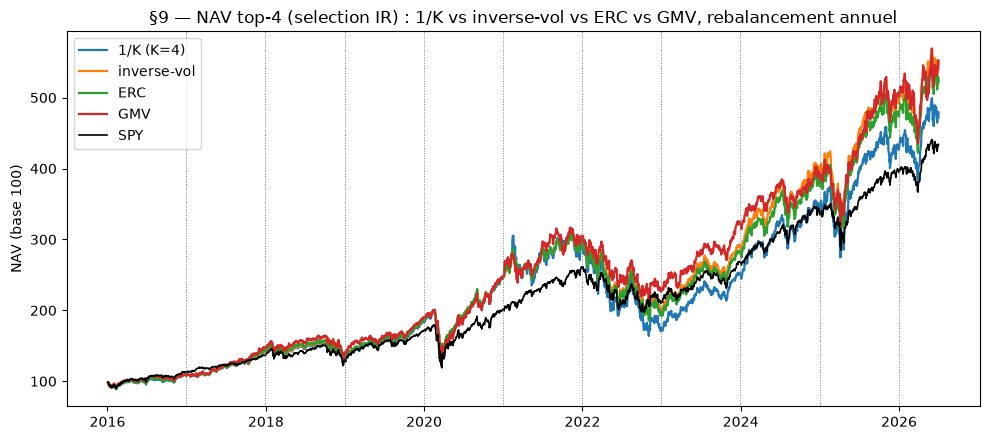

In [37]:
# §9 — FIGURE : NAV top-4 (selection IR) par ponderation, base 100 (pointilles = rebalancements annuels)
_nav = lambda r: 100 * (1 + r).cumprod()
plt.figure(figsize=(10, 4.5))
plt.plot(_nav(_ser[("1/K", "ir")]),         label="1/K (K=4)", lw=1.6)
plt.plot(_nav(_ser[("inverse-vol", "ir")]), label="inverse-vol", lw=1.6)
plt.plot(_nav(_ser[("ERC", "ir")]),         label="ERC", lw=1.6)
plt.plot(_nav(_ser[("GMV", "ir")]),         label="GMV", lw=1.6)
plt.plot(_nav(r_spy.reindex(_ser[("1/K", "ir")].index).fillna(0)), label="SPY", color="k", lw=1.2)
for j in det4["journal"][1:]:
    plt.axvline(j["rebal"], color="gray", ls=":", lw=0.7)
plt.ylabel("NAV (base 100)")
plt.title("§9 — NAV top-4 (selection IR) : 1/K vs inverse-vol vs ERC vs GMV, rebalancement annuel")
plt.legend(); plt.tight_layout(); plt.show()

### 9.2 Lecture

$$\max_{\text{pondérations}}\ t_{\rm appr}=+0{,}48\ \ll\ 1{,}645\ \ (\text{annuel comme 6 mois})\qquad\Longrightarrow\qquad \text{aucun }\alpha\text{ positif sous aucune pondération.}$$

- Les seuls $\lvert t_{\rm appr}\rvert>1{,}645$ sont **négatifs** (6 mois, sél appraisal : inverse-vol $-1{,}78$) — de la **sous-performance** ajustée, pas du talent.
- **inverse-vol** (sél IR, annuel) : seul gain net — $t:0{,}94\!\to\!1{,}49$, $\ \beta:1{,}20\!\to\!1{,}16$, $\ $excès $3{,}1\!\to\!4{,}0\,\%$/an. Risque mieux réparti, pas d'$\alpha$.
- **GMV** (sél appraisal, annuel) : $-4{,}5\,\%$/an, $t=-2{,}76$ — sur-ajustement de $\Sigma$ (DGU 2009).
- Verdict « $\beta$ de style, zéro $\alpha$ » **invariant** au choix de $w$ — comme le test IS/OS sur $K$ : ni *qui*, ni *combien*, ni *comment pondérer* n'est apprenable ici.

<!-- §10-MARKER -->
## 10. Robustesse d'estimation : $\Sigma$ shrinkée (Ledoit-Wolf)

Le §9 estime $\Sigma$ par la **covariance d'échantillon** brute $\hat\Sigma^{\text{emp}}$. À $K{=}4$ sur des fenêtres courtes, c'est **bruité** — et GMV, qui **inverse** $\Sigma$, amplifie ce bruit (§9.2 : GMV sél appr $-4{,}5\%/t\,{-}2{,}76$ = sur-ajustement ; DeMiguel–Garlappi–Uppal 2009). Le **shrinkage** régularise $\Sigma$ en la tirant vers une **cible stable** $F$ :

$$\boxed{\ \hat\Sigma^{\text{shrink}}=\delta\,F+(1-\delta)\,\hat\Sigma^{\text{emp}}\ }\qquad 0\le\delta\le 1,\qquad \hat\Sigma^{\text{emp}}_{ij}=\tfrac1T\textstyle\sum_{t\le t^R}(r_{t,i}-\bar r_i)(r_{t,j}-\bar r_j).$$

- $\delta=0\Rightarrow\hat\Sigma^{\text{emp}}$ (cov brute $=$ §9) ; $\ \delta=1\Rightarrow F$ (cible pure). **$\delta$ $=$ poids donné à la cible stable.**
- On ne change **que l'estimateur de $\Sigma$** : sélection walk-forward, moteur en parts (§6.1) et formules de poids (§9) **inchangés**. Point-in-time strict : $\hat\Sigma^{\text{emp}},F,\delta$ estimés sur $\{s\le t^R\}$, appliqués à $Y{+}1$.
- $1/K$ et inverse-vol n'utilisent que la **diagonale** ($\sigma_k$) $\Rightarrow$ **immunisés** ; seuls **ERC** et **GMV** (qui utilisent tout $\Sigma$) bougent.
- Shrinkage $=$ régularisation d'**estimation**, pas d'information $\Rightarrow$ il **ne peut pas créer d'$\alpha$** ; on teste s'il **dompte** l'artefact GMV.
- ⚠ Convention d'échelle (auditée) : le code recombine $\delta F+(1-\delta)\,\hat\Sigma^{\text{ddof}=1}$ (la cov
  brute du §9) alors que $F$ et $\delta$ sont estimés en convention $1/T$ ; l'écart $\approx(1-\delta)/T\sim0{,}2\,\%$
  des entrées est sans effet sur les poids (ERC/GMV invariants d'échelle) et garantit que $\delta=0$ reproduit
  le §9 bit-à-bit (validation 10.1-i).

### Le coefficient $\delta$ (intensité de shrinkage)

Ledoit–Wolf choisit $\delta$ **automatiquement**, comme un ratio *bruit / distance* :

$$\delta\ \approx\ \frac{\text{bruit de }\hat\Sigma^{\text{emp}}}{\text{distance entre }\hat\Sigma^{\text{emp}}\text{ et }F}\qquad\Longrightarrow\qquad \text{bruit élevé}\Rightarrow\delta\uparrow,\qquad F\ \text{loin}\Rightarrow\delta\downarrow.$$

Forme fermée (base commune aux cibles structurées), $T=$ nombre de jours communs :

$$\boxed{\ \delta=\frac{\pi-\rho}{T\,\gamma}\ }\qquad\text{puis}\qquad \delta\leftarrow\min\!\big(1,\ \max(0,\delta)\big),$$

$$\gamma=\big\lVert\hat\Sigma^{\text{emp}}-F\big\rVert_F^2\ \ (\text{distance à la cible}),\qquad \pi=\text{bruit total de }\hat\Sigma^{\text{emp}},\qquad \rho=\text{part du bruit déjà capturée par }F.$$

### Les trois cibles $F$

Même logique partout — **seule la cible $F$ change** (donc $\gamma$ et $\rho$). La diagonale a une forme simplifiée ; les deux autres passent par la base $\pi,\rho,\gamma$.

**Diagonale** (LW 2004) — variances moyennées, corrélations effacées :
$$F=\mu I,\quad \mu=\tfrac1K\operatorname{tr}\hat\Sigma^{\text{emp}}\ ;\qquad \delta_{\text{diag}}=\frac{b}{d},\quad d=\tfrac1K\!\sum_{i,j}(\hat\Sigma^{\text{emp}}_{ij})^2-\mu^2,\quad 0\le b\le d\ \text{(bruit estimé)}.$$

**Single-factor** (LW 2001) — un seul facteur commun, le « marché » $f_t=\tfrac1K\sum_k r_{t,k}$ :
$$F_{ij}=\beta_i\beta_j\,\sigma_f^2\ (i\neq j),\quad F_{ii}=\hat\Sigma^{\text{emp}}_{ii}\ ;\qquad \delta_{\text{1f}}=\frac{\pi-\rho_{\text{1f}}}{T\,\gamma_{\text{1f}}}.$$

**Corrélation constante** (LW 2003) — garde les $\sigma_k$, remplace toutes les corrélations par leur moyenne $\bar\rho=\tfrac{1}{K(K-1)}\sum_{i\neq j}\hat\rho_{ij}$ :
$$F_{ij}=\bar\rho\,\sqrt{\hat\Sigma^{\text{emp}}_{ii}\,\hat\Sigma^{\text{emp}}_{jj}}\ (i\neq j),\quad F_{ii}=\hat\Sigma^{\text{emp}}_{ii}\ ;\qquad \delta_{\text{cc}}=\frac{\pi-\rho_{\text{cc}}}{T\,\gamma_{\text{cc}}}.$$

La cellule de code ci-dessous calcule exactement ces $F$ et ces $\delta$ (`_lw_diagonal` / `_lw_single_factor` / `_lw_constant_correlation`), puis annualise $\hat\Sigma^{\text{shrink}}\!\times\!252$.

In [38]:
# §10 — CovarianceMatrixRecipes (LW multi-cibles) vit dans tools.membre.moteur — amorçage ;
# seul le rabat _w_shrunk (orchestration) reste ici.
def _w_shrunk(target, kind):
    """poids GMV/ERC calcules sur la Sigma shrinkee ; RABAT sur inverse-vol (§9) si fenetre courte / non-PSD."""
    def w(bids, tR):
        Sig, _ = _cov_pit_shrunk(bids, tR, target)
        if Sig is None or not CovarianceMatrixRecipes._is_positive_semidefinite(Sig):
            return w_invvol(bids, tR)
        return _gmv_from_cov(Sig) if kind == "gmv" else _erc_from_cov(Sig, w_invvol(bids, tR))
    return w

print("§10 pret | 4 estimateurs de Sigma : cov brute (= §9), Ledoit-Wolf {diagonal, single-factor, constant-corr}")

§10 pret | 4 estimateurs de Sigma : cov brute (= §9), Ledoit-Wolf {diagonal, single-factor, constant-corr}


### 10.1 Validation

Quatre contrôles avant de lire les tables :

$$\text{(i)}\quad w^{\text{sample}}_{\rm GMV/ERC}\equiv w^{\S9}_{\rm GMV/ERC}\ \ (\alpha{=}0\Rightarrow\hat\Sigma{=}S)\ ;\qquad \text{(ii)}\quad w_{1/K},\,w_{\text{inv-vol}}\ \text{inchangés (diagonale seule)}.$$

$$\text{(iii)}\quad \delta^{\text{diag}}\ \overset{!}{=}\ \texttt{sklearn.LedoitWolf.shrinkage\_}\ \ (\text{oracle tiers, même estimateur LW 2004, code indépendant})\ ;\qquad \text{(iv)}\quad \text{sanity synthétique}:\ T\!\gg\!K\Rightarrow\delta\!\to\!0,\ \ \rho\ \text{constant}\Rightarrow\text{ERC}=\text{inv-vol}.$$

In [39]:
# §10.1 — VALIDATION (contrôles avant lecture ; l'oracle sklearn confirme le LW 2004 codé plus haut)
from sklearn.covariance import LedoitWolf   # implémentation TIERCE et indépendante de Ledoit-Wolf (cible identité)

# (i) contrôle : cible "sample" (alpha=0) == cov brute du §9  ->  GMV/ERC identiques bit-a-bit
for _cr in ("ir", "appraisal"):
    assert np.allclose(strategie_ponderee(4, _w_shrunk("sample", "gmv"), _cr)["r"].values, _ser[("GMV", _cr)].values, atol=1e-9)
    assert np.allclose(strategie_ponderee(4, _w_shrunk("sample", "erc"), _cr)["r"].values, _ser[("ERC", _cr)].values, atol=1e-9)
# (ii) immunite : 1/K et inverse-vol ne touchent que la diagonale  ->  inchanges vs §9
assert np.allclose(strategie_ponderee(4, w_invvol, "ir")["r"].values, _ser[("inverse-vol", "ir")].values)
assert np.allclose(strategie_ponderee(4, w_equal,  "ir")["r"].values, r_dr_eq.values)
# (iii) oracle tiers : notre intensite LW-diagonal == sklearn.LedoitWolf.shrinkage_ (a la precision machine)
_dmax = 0.0
for _Y in range(2016, 2026):
    _s = select_topK(_Y, 4, "appraisal"); _idx = cal[cal.year == _Y + 1]
    if not _s or not len(_idx): continue
    _b = [b for _, b in _s]; _tR = cal[cal.get_loc(_idx[0]) - 1]; _R = _fenetre_pit(_b, _tR)
    if len(_R) < RISK_WINDOW_MIN: continue
    _, _aA = CovarianceMatrixRecipes(_R)._lw_diagonal()
    _dmax = max(_dmax, abs(_aA - LedoitWolf().fit(_R.values).shrinkage_))
assert _dmax < 1e-6
# (iv) sanity synthetique deterministe : echantillon riche -> shrinkage faible ; correlation constante -> ERC = inverse-vol
_rng = np.random.default_rng(0); _sig = np.array([.12, .18, .36]) / np.sqrt(252); _rho = 0.5
_L = np.linalg.cholesky(np.outer(_sig, _sig) * (_rho * np.ones((3, 3)) + (1 - _rho) * np.eye(3)))
_X = pd.DataFrame(_rng.standard_normal((4000, 3)) @ _L.T, columns=list("abc"))
_Scc, _ = CovarianceMatrixRecipes(_X).shrunk_covariance_matrix("ledoit_wolf", "constant_correlation")
_, _adiag = CovarianceMatrixRecipes(_X)._lw_diagonal()
_ivref = (1 / np.array([.12, .18, .36])) / (1 / np.array([.12, .18, .36])).sum()
assert _adiag < 0.05 and np.allclose(_erc_from_cov(_Scc, np.ones(3) / 3), _ivref, atol=2e-2)
print(f"validation OK | (i) sample≡§9 bit-a-bit | (ii) 1/K & inverse-vol immunises | "
      f"(iii) intensite LW-diag ≡ sklearn (max|Δ|={_dmax:.1e}) | (iv) sanity synthetique (α_diag={_adiag:.3f})")

validation OK | (i) sample≡§9 bit-a-bit | (ii) 1/K & inverse-vol immunises | (iii) intensite LW-diag ≡ sklearn (max|Δ|=4.2e-17) | (iv) sanity synthetique (α_diag=0.001)


### 10.2 Résultat top-4 (annuel, puis 6 mois)

Base identique au §9.1 : **top-4 fixe** ($K=4$), annuel puis 6 mois, mêmes seuils ($t_{10}\approx1{,}81$ ; $t\approx1{,}72$) — **on ne change que l'estimateur de $\Sigma$**. Seuls **ERC** et **GMV** dépendent de $\Sigma$ ; $1/K$ et inverse-vol (diagonale seule) sont **immunisés** — identiques au §9, donc omis ici (cf. §10.1). Ligne **cov brute** $=$ §9 (baseline). Colonnes $=$ §6.3/§9.

⚠ $t=(\bar x/s_x)\sqrt{n}$ dépend aussi de la **dispersion** $s_x$ des excès par période (§6.2) : deux lignes d'excès moyen proche peuvent avoir des $t$ différents.

In [40]:
# §10.2 — TABLE ANNUELLE : {ERC, GMV} x {cov brute (= §9), LW diag, LW 1-facteur, LW corr-const} + temoins immunises
_EST = [("cov brute", "sample"), ("LW diag", "LW-diag"), ("LW 1-fac", "LW-1fac"), ("LW corr-cst", "LW-cc")]
# seuls ERC et GMV dependent de Σ ; 1/K & inverse-vol (diagonale) sont immunises (= §9) -> pas dans le tableau
_ser10 = {}
for _cr in ("ir", "appraisal"):
    for _kind, _KL in [("erc", "ERC"), ("gmv", "GMV")]:
        for _lab, _tgt in _EST:
            _ser10[(_cr, f"{_KL} · {_lab}")] = (_ser[(_KL, _cr)] if _tgt == "sample"
                                                else strategie_ponderee(4, _w_shrunk(_tgt, _kind), _cr)["r"])
_ORDER = [f"{_KL} · {_lab}" for _KL in ("ERC", "GMV") for _lab, _ in _EST]
_ix = pd.MultiIndex.from_tuples([("sel IR" if _cr == "ir" else "sel appr", _m)
                                 for _cr in ("ir", "appraisal") for _m in _ORDER])
print("top-4 annuel — pondération x estimateur de Σ ; seuil t10 ≈ 1,81 ; 'cov brute' = §9")
pd.DataFrame([_ligne(_ser10[("ir" if _s == "sel IR" else "appraisal", _m)]) for _s, _m in _ix], index=_ix)   # pleine précision (affichage harmonisé §9.1)

top-4 annuel — pondération x estimateur de Σ ; seuil t10 ≈ 1,81 ; 'cov brute' = §9


exces_an         t gagnantes      beta  alpha_ann  \
sel IR   ERC · cov brute    0.033599  1.110280      7/11  1.177216   0.000159   
         ERC · LW diag      0.033139  1.095982      7/11  1.177929  -0.000336   
         ERC · LW 1-fac     0.033603  1.110373      7/11  1.177245   0.000158   
         ERC · LW corr-cst  0.033882  1.117404      7/11  1.178079   0.000231   
         GMV · cov brute    0.031943  1.220283      6/11  1.104892   0.015169   
         GMV · LW diag      0.029746  1.168131      5/11  1.104600   0.012881   
         GMV · LW 1-fac     0.031988  1.221078      6/11  1.105037   0.015185   
         GMV · LW corr-cst  0.032301  1.226163      5/11  1.108030   0.014998   
sel appr ERC · cov brute   -0.032779 -1.664958      3/11  0.909520  -0.017949   
         ERC · LW diag     -0.032291 -1.644894      3/11  0.913745  -0.017950   
         ERC · LW 1-fac    -0.032771 -1.665201      3/11  0.909591  -0.017952   
         ERC · LW corr-cst -0.032552 -1.669908      3/11  0.910551  -0.017914   
         GMV · cov brute   -0.044992 -2.762174      2/11  0.795363  -0.010110   
         GMV · LW diag     -0.042765 -2.466188      2/11  0.799417  -0.009046   
         GMV · LW 1-fac    -0.045049 -2.766515      2/11  0.795242  -0.010137   
         GMV · LW corr-cst -0.044699 -2.745422      2/11  0.794762  -0.009740   

                              t_appr  
sel IR   ERC · cov brute    0.005766  
         ERC · LW diag     -0.012132  
         ERC · LW 1-fac     0.005710  
         ERC · LW corr-cst  0.008373  
         GMV · cov brute    0.479647  
         GMV · LW diag      0.424607  
         GMV · LW 1-fac     0.480056  
         GMV · LW corr-cst  0.469959  
sel appr ERC · cov brute   -0.669965  
         ERC · LW diag     -0.664537  
         ERC · LW 1-fac    -0.670199  
         ERC · LW corr-cst -0.671334  
         GMV · cov brute   -0.344306  
         GMV · LW diag     -0.318805  
         GMV · LW 1-fac    -0.345080  
         GMV · LW corr-cst -0.331949

In [41]:
# §10.2 — MÊME TABLE, rebalancement 6 MOIS (coupes 30/06 & 31/12 du §8 ; via strategie_ponderee_6m du §9)
_ser10_6 = {}                                              # idem : ERC & GMV seuls (1/K & inverse-vol immunises)
for _cr in ("ir", "appraisal"):
    for _kind, _KL in [("erc", "ERC"), ("gmv", "GMV")]:
        for _lab, _tgt in _EST:
            _ser10_6[(_cr, f"{_KL} · {_lab}")] = strategie_ponderee_6m(4, _w_shrunk(_tgt, _kind), _cr)["r"]
print(f"top-4 6 mois — pondération x estimateur ; {eval_sem(r_6m_ir)['n']} semestres, seuil t ≈ 1,72")
pd.DataFrame([_ligne6(_ser10_6[("ir" if _s == "sel IR" else "appraisal", _m)]) for _s, _m in _ix], index=_ix)   # pleine précision (affichage harmonisé §9.1)

top-4 6 mois — pondération x estimateur ; 22 semestres, seuil t ≈ 1,72


exces_an         t gagnantes      beta  alpha_ann  \
sel IR   ERC · cov brute    0.004882  0.176701     11/22  1.206584  -0.021377   
         ERC · LW diag      0.004627  0.167226     11/22  1.207460  -0.021683   
         ERC · LW 1-fac     0.004887  0.176912     11/22  1.206600  -0.021375   
         ERC · LW corr-cst  0.005128  0.185631     11/22  1.207302  -0.021267   
         GMV · cov brute   -0.002523 -0.119549     11/22  1.100818  -0.012976   
         GMV · LW diag     -0.005490 -0.266067     12/22  1.104779  -0.016399   
         GMV · LW 1-fac    -0.002547 -0.120668     11/22  1.100911  -0.013010   
         GMV · LW corr-cst -0.004178 -0.200409     10/22  1.103218  -0.014697   
sel appr ERC · cov brute   -0.052861 -2.332823      8/22  0.946708  -0.042665   
         ERC · LW diag     -0.053042 -2.327418      8/22  0.950991  -0.043279   
         ERC · LW 1-fac    -0.052866 -2.333719      8/22  0.946774  -0.042678   
         ERC · LW corr-cst -0.052807 -2.343919      8/22  0.947840  -0.042763   
         GMV · cov brute   -0.046845 -1.951257      6/22  0.808763  -0.020491   
         GMV · LW diag     -0.049440 -2.220557      8/22  0.815761  -0.023401   
         GMV · LW 1-fac    -0.046964 -1.956743      6/22  0.808653  -0.020585   
         GMV · LW corr-cst -0.046479 -1.946729      7/22  0.809129  -0.020174   

                              t_appr  
sel IR   ERC · cov brute   -0.706805  
         ERC · LW diag     -0.714218  
         ERC · LW 1-fac    -0.706837  
         ERC · LW corr-cst -0.704910  
         GMV · cov brute   -0.457999  
         GMV · LW diag     -0.601393  
         GMV · LW 1-fac    -0.459193  
         GMV · LW corr-cst -0.516954  
sel appr ERC · cov brute   -1.481385  
         ERC · LW diag     -1.491937  
         ERC · LW 1-fac    -1.482262  
         ERC · LW corr-cst -1.491383  
         GMV · cov brute   -0.696296  
         GMV · LW diag     -0.831935  
         GMV · LW 1-fac    -0.699347  
         GMV · LW corr-cst -0.687578

In [42]:
# §10 — DIAGNOSTICS d'ESTIMATION (GMV, l'estimateur sensible) : intensite alpha, conditionnement, concentration, replis
def _diag_gmv(cr):
    out = {}
    for _lab, _tgt in _EST:
        ns, al, cs, csh, rep, mw, hh = [], [], [], [], 0, [], []
        for Y in range(2015, 2026):
            sel = select_topK(Y, 4, critere=cr); idx = cal[cal.year == (Y + 1)]
            if not sel or not len(idx): continue
            bids = [b for _, b in sel]; tR = cal[cal.get_loc(idx[0]) - 1]
            R = _fenetre_pit(bids, tR); ns.append(len(R))
            cs.append(np.linalg.cond(np.cov(R.values, rowvar=False) * 252))
            Sig, a = _cov_pit_shrunk(bids, tR, _tgt)
            if Sig is None:
                rep += 1; w = w_invvol(bids, tR)
            else:
                al.append(a); csh.append(np.linalg.cond(Sig)); w = _gmv_from_cov(Sig)
            mw.append(w.max()); hh.append((w ** 2).sum())
        out[_lab] = dict(T_moy=np.mean(ns), delta_LW=np.mean(al) if al else 0.0, cond_brute=np.mean(cs),
                         cond_shrink=np.mean(csh) if csh else np.mean(cs), replis=rep,
                         max_w=np.mean(mw), HHI=np.mean(hh))
    return pd.DataFrame(out).T.round(3)
print("GMV — diagnostics par estimateur (moyennes sur les coupes) : delta_LW=intensité δ, cond=conditionnement de Σ, HHI=concentration")
pd.concat({"sel IR": _diag_gmv("ir"), "sel appr": _diag_gmv("appraisal")})

GMV — diagnostics par estimateur (moyennes sur les coupes) : delta_LW=intensité δ, cond=conditionnement de Σ, HHI=concentration


T_moy  delta_LW  cond_brute  cond_shrink  replis  \
sel IR   cov brute    484.636     0.000      46.628       46.628     0.0   
         LW diag      484.636     0.051      46.628       30.673     0.0   
         LW 1-fac     484.636     0.009      46.628       46.612     0.0   
         LW corr-cst  484.636     0.399      46.628       39.139     0.0   
sel appr cov brute    514.727     0.000      50.227       50.227     0.0   
         LW diag      514.727     0.045      50.227       24.789     0.0   
         LW 1-fac     514.727     0.014      50.227       49.907     0.0   
         LW corr-cst  514.727     0.224      50.227       40.470     0.0   

                      max_w    HHI  
sel IR   cov brute    0.730  0.654  
         LW diag      0.690  0.601  
         LW 1-fac     0.731  0.655  
         LW corr-cst  0.737  0.666  
sel appr cov brute    0.767  0.674  
         LW diag      0.681  0.553  
         LW 1-fac     0.767  0.675  
         LW corr-cst  0.747  0.645

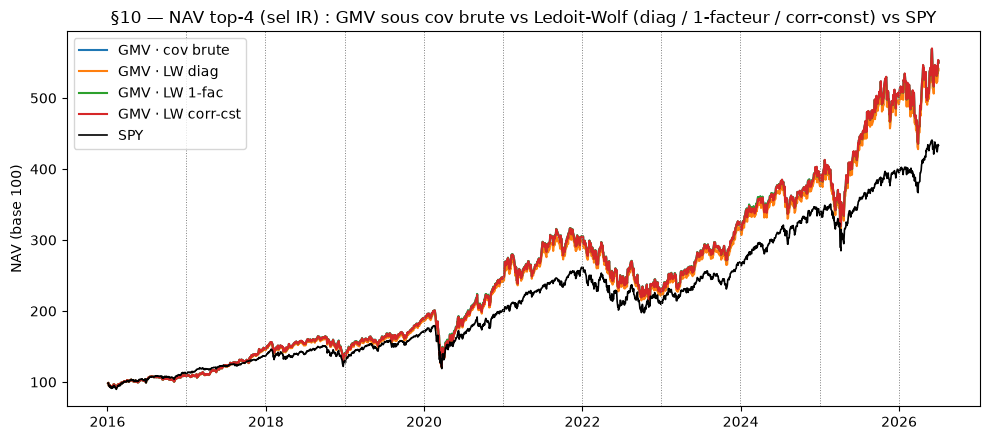

In [43]:
# §10 — FIGURE : NAV top-4 (sel IR) GMV par estimateur de Σ, base 100 (pointilles = rebalancements annuels)
_nav = lambda r: 100 * (1 + r).cumprod()
plt.figure(figsize=(10, 4.5))
for _lab, _tgt in _EST:
    plt.plot(_nav(_ser10[("ir", f"GMV · {_lab}")]), lw=1.5, label=f"GMV · {_lab}")
plt.plot(_nav(r_spy.reindex(_ser10[("ir", "GMV · cov brute")].index).fillna(0)), color="k", lw=1.2, label="SPY")
for j in det4["journal"][1:]:
    plt.axvline(j["rebal"], color="gray", ls=":", lw=0.7)
plt.ylabel("NAV (base 100)")
plt.title("§10 — NAV top-4 (sel IR) : GMV sous cov brute vs Ledoit-Wolf (diag / 1-facteur / corr-const) vs SPY")
plt.legend(); plt.tight_layout(); plt.show()

### 10.3 Lecture

$$\max_{\text{estimateurs}} t_{\rm appr}=+0{,}48\ \ll\ 1{,}645\qquad\Longrightarrow\qquad\text{aucun }\alpha\text{ positif réplicable sous tout estimateur de }\Sigma.$$

- **Le shrinkage dompte l'artefact GMV** (sél appr) : cov brute $-4{,}5\%/t\,{-}2{,}76\ \to\ -4{,}3\%/t\,{-}2{,}46$ (LW-diag) ; $\operatorname{cond}\Sigma\ 50\!\to\!25$, $\max_k w_k\ 0{,}77\!\to\!0{,}68$, HHI $0{,}67\!\to\!0{,}55$, intensité $\delta_{\rm LW}\approx0{,}05$. Artefact **tempéré**, pas inversé en talent.
- **Single-factor $\approx$ cov brute** ($\delta_{\rm LW}\approx0{,}01$, $\operatorname{cond}$ inchangé) : $K{=}4$ NAV de membres $=$ déjà **un seul facteur** (le marché) $\Rightarrow$ rien à shrinker vers un facteur.
- **Les seuls $\lvert t_{\rm appr}\rvert>1{,}645$ sont négatifs** (sous-performance ajustée des paniers sél-appraisal à 6 mois, ex. inverse-vol $t\,{-}1{,}78$) — **hérités du §9**, ni créés ni corrigés par le shrinkage.
- **Témoins** ($1/K$, inverse-vol) **identiques au §9** $\Rightarrow$ l'effet observé est bien dû à l'**estimation de $\Sigma$** seule.
- **Verdict invariant** : « $\beta$ de style $\approx1{,}20$, zéro $\alpha$ » — au *qui* (§4-5), *combien* (§7), *comment pondérer* (§9), et *comment estimer $\Sigma$* (§10).

<!-- PARTIE2-MARKER -->
# Partie II — Changement de règle : classement par le Sharpe

La Partie I sélectionnait les membres **significatifs** (IR ou appraisal, $t>1{,}645$) ; leur copie n'a produit aucun $\alpha$. On change de règle :
- on classe par le **Sharpe brut** (§2), $\mathrm{Sharpe}=\dfrac{\overline{r_P}}{\sigma(r_P)}\sqrt{252}$ — **plus aucun test de significativité** ;
- éligibilité : $n_{\text{days}}\ge126$ **et** $\mathrm{Sharpe}>0{,}4$ (le minimum de 10 trades saute) ;
- on copie le top-$K$ et on regarde ce que donnent **plusieurs $K$** (5, 10, 20) et **plusieurs pondérations** $w$.

## 11. Sélection par le Sharpe
- Éligibles v2 : tout membre avec $n_{\text{days}}\ge126$ jours de track **et** $\mathrm{Sharpe}>0{,}4$ — aucune autre condition.
- Le tableau ci-dessous : le top-20 des Sharpe, calculés sur tout l'historique 2014-2026.
- Pour la copie (§12), le classement est recalculé **point-in-time** à chaque coupe (31/12 ; et 30/06 en plus pour la cadence 6 mois) : le Sharpe n'utilise que les jours $\le$ la coupe, et le filtre $\mathrm{Sharpe}>0{,}4$ s'applique à la coupe.

In [44]:
# Éligibilité v2 (n_days >= 126 ET Sharpe > 0,4) + classement rétrospectif par le Sharpe brut du §2
MIN_SHARPE = 0.4
base2 = tab[tab.n_days >= MIN_DAYS].copy()                 # porte de matière : 126 jours
base2["sharpe"] = [stats(wf_ret[b])["sharpe"] for b in base2.bioguide_id]
elig2 = base2[base2.sharpe > MIN_SHARPE].copy()            # porte de niveau : Sharpe > 0,4
M2 = len(elig2)
_r_spy14 = r_spy.reindex(cal[cal >= "2014-01-01"]).dropna()
SH_SPY = _r_spy14.mean() / _r_spy14.std() * np.sqrt(252)
print(f"{len(tab)} membres -> {len(base2)} à n_days >= {MIN_DAYS} -> {M2} éligibles v2 (Sharpe > {MIN_SHARPE}) | Partie I : {M} | Sharpe SPY 2014-2026 : {SH_SPY:.2f}")
elig2.sort_values("sharpe", ascending=False).head(20)[["name", "n_trades", "n_days", "sharpe"]].round(3).reset_index(drop=True)

266 membres -> 263 à n_days >= 126 -> 224 éligibles v2 (Sharpe > 0.4) | Partie I : 223 | Sharpe SPY 2014-2026 : 0.83


,name,n_trades,n_days,sharpe
0,John Fetterman,10,284,2.904
1,Katie Britt,24,306,2.022
2,Terri A. Sewell,4,308,1.899
3,John James,257,661,1.718
4,Morgan McGarvey,24,853,1.714
5,Ashley Moody,23,364,1.660
6,Bruce Westerman,208,336,1.579
7,David J. Taylor,195,353,1.531
8,Greg Stanton,186,694,1.481
9,Lisa McClain,1479,580,1.427


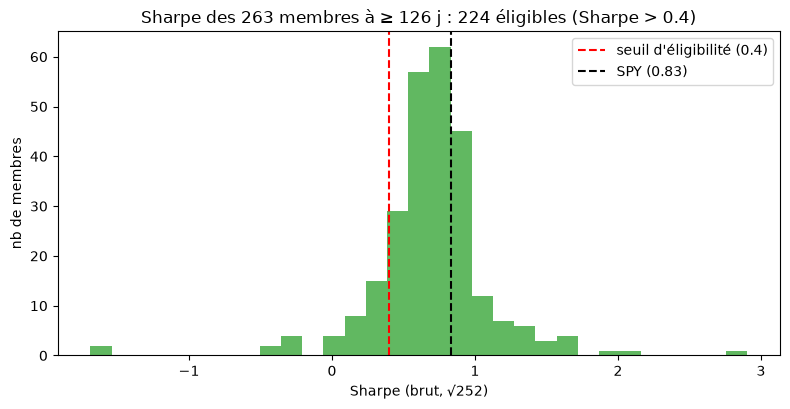

In [45]:
# FIGURE (style 4.1/4.2) : distribution des Sharpe (tous les >= 126 j), seuil d'éligibilité 0,4 et SPY en repères
plt.figure(figsize=(8, 4.2))
plt.hist(base2.sharpe.dropna(), bins=31, alpha=0.75, color="tab:green")
plt.axvline(MIN_SHARPE, color="red", ls="--", label=f"seuil d'éligibilité ({MIN_SHARPE})")
plt.axvline(SH_SPY, color="k", ls="--", label=f"SPY ({SH_SPY:.2f})")
plt.xlabel("Sharpe (brut, √252)"); plt.ylabel("nb de membres")
plt.title(f"Sharpe des {len(base2)} membres à ≥ {MIN_DAYS} j : {M2} éligibles (Sharpe > {MIN_SHARPE})")
plt.legend(); plt.tight_layout(); plt.show()

In [46]:
# Classement point-in-time par le SHARPE : n_days >= 126 ET Sharpe > 0,4 à la coupe — aucun test t
def classement_sharpe_a_date(d, min_days=MIN_DAYS, min_sharpe=MIN_SHARPE):
    rows = []
    for bid, r in wf_ret.items():
        rr = r.loc[:d]
        if len(rr) < min_days or rr.std() == 0:
            continue
        s = rr.mean() / rr.std() * np.sqrt(252)
        if s <= min_sharpe:
            continue
        rows.append(dict(bioguide_id=bid, score=s))
    return (pd.DataFrame(rows).sort_values("score", ascending=False).reset_index(drop=True)
            if rows else pd.DataFrame(columns=["bioguide_id", "score"]))

clsmt_sh  = {Y: classement_sharpe_a_date(pd.Timestamp(f"{Y}-12-31")) for Y in range(2014, 2027)}
clsmt6_sh = {d: classement_sharpe_a_date(d) for d in cuts}
_nom = lambda c: df.loc[df.bioguide_id == c["bioguide_id"].iloc[0], "name"].iloc[0].split()[-1] if len(c) else "-"
resume_sh = pd.DataFrame([dict(fenetre=f"≤ {Y}", n_eligibles=len(clsmt_sh[Y]), tete=_nom(clsmt_sh[Y]),
                               sharpe_tete=round(float(clsmt_sh[Y]["score"].iloc[0]), 2) if len(clsmt_sh[Y]) else np.nan)
                          for Y in range(2014, 2027)])
print(f"classements Sharpe point-in-time prêts ({len(clsmt_sh)} coupes annuelles + {len(clsmt6_sh)} semestrielles) — n éligibles (Sharpe > {MIN_SHARPE}) et tête par coupe")
resume_sh

classements Sharpe point-in-time prêts (13 coupes annuelles + 22 semestrielles) — n éligibles (Sharpe > 0.4) et tête par coupe


,fenetre,n_eligibles,tete,sharpe_tete
0,≤ 2014,55,Jr.,2.52
1,≤ 2015,50,Sessions,1.49
2,≤ 2016,71,Long,2.88
3,≤ 2017,107,Khanna,3.50
4,≤ 2018,90,Speier,1.57
5,≤ 2019,146,Lee,2.78
6,≤ 2020,149,Wyden,2.50
7,≤ 2021,176,Case,2.35
8,≤ 2022,139,Trone,1.27
9,≤ 2023,174,Landsman,2.27


## 12. Copie top-$K$ × pondérations $w$
À chaque coupe, on copie les $K$ premiers du classement Sharpe et on les tient jusqu'à la coupe suivante — moteur en parts du §6.1, inchangé. Cinq pondérations :

| poids | formule | source |
|---|---|---|
| $1/K$ | $w_k=1/K$ | §6 |
| $\propto$Sharpe | $w_k=\max(S_k,0)\big/\sum_j\max(S_j,0)$, $S_k$ = Sharpe point-in-time | nouveau |
| inverse-vol | $w_k\propto1/\sigma_k$ | §9 |
| ERC | $\mathrm{RC}_k$ égaux | §9 |
| GMV | $\arg\min_{w\ge0,\ \mathbf 1^\top w=1}\ w^\top\Sigma\,w$ | §9 |

- $\propto$Sharpe est long-only par construction ; si tous les $S_k\le0$, on prend $1/K$.
- ERC et GMV estiment $\Sigma$ sur la **fenêtre commune** des $K$ membres (§9). Si elle fait moins de 60 jours (`RISK_WINDOW_MIN`, §10), on applique inverse-vol à la place ; ces cas sont comptés dans les tables (0 en pratique).

In [47]:
# §12 — poids ∝Sharpe + orchestrateur top-K Sharpe (annuel & 6 mois) ; rabat inverse-vol si fenêtre commune courte
_replis = []                                             # coupes où ERC/GMV se sont rabattus (fenêtre < RISK_WINDOW_MIN)

def w_sharpe(bids, tR):                                  # w_k ∝ max(S_k, 0), S_k = Sharpe point-in-time
    s = []
    for b in bids:
        r = wf_ret[b].loc[:tR]
        s.append(r.mean() / r.std() * np.sqrt(252) if r.std() > 0 else 0.0)
    s = np.clip(np.array(s), 0.0, None)
    return s / s.sum() if s.sum() > 0 else np.ones(len(bids)) / len(bids)

def _rabat_court(kind):
    # ERC/GMV du §9, mais : si < RISK_WINDOW_MIN jours communs (ou < 2 membres), repli inverse-vol (compté)
    def w(bids, tR):
        R = _fenetre_pit(bids, tR)
        if len(R) < RISK_WINDOW_MIN or R.shape[1] < 2:
            _replis.append(tR)
            return w_invvol(bids, tR)
        Sig = np.cov(R.values, rowvar=False) * 252
        return _gmv_from_cov(Sig) if kind == "gmv" else _erc_from_cov(Sig, w_invvol(bids, tR))
    return w

w_gmv_r, w_erc_r = _rabat_court("gmv"), _rabat_court("erc")

def strategie_sharpe(K, weight_fn, cadence="annuel"):
    """Top-K du classement SHARPE (aucun filtre), moteur en parts §6.1 ; cadence annuelle (31/12) ou "6m" (§8)."""
    blocs = []
    coupes = ([(pd.Timestamp(f"{Y}-12-31"), cal[cal.year == (Y + 1)]) for Y in range(2015, 2026)]
              if cadence == "annuel" else
              [(d, cal[(cal > d) & (cal <= next_bound(d))]) for d in cuts])
    for d, idx in coupes:
        c = clsmt_sh[d.year] if cadence == "annuel" else clsmt6_sh[d]
        if len(c) == 0 or not len(idx):
            continue
        bids = list(c["bioguide_id"].head(K))
        tR = cal[cal.get_loc(idx[0]) - 1]                # coupe = veille du 1er jour tenu (comme §6/§9)
        blocs.append((idx, bids, weight_fn(bids, tR)))
    return _parts_engine(blocs)

print("orchestrateur Sharpe prêt (annuel & 6 mois) | poids : 1/K, ∝Sharpe, inverse-vol, ERC, GMV (rabat si < 60 j communs)")

orchestrateur Sharpe prêt (annuel & 6 mois) | poids : 1/K, ∝Sharpe, inverse-vol, ERC, GMV (rabat si < 60 j communs)


### 12.1 Validation
- (i) $K{=}1$ : le portefeuille copie un seul membre $\Rightarrow$ sa série de rendement doit être identique à celle du membre, chaque année tenue.
- (ii) $w_{\propto\text{Sharpe}}$ : recomposition de la même formule sur les mêmes entrées — un contrôle de **déterminisme** (somme $=1$, tous $\ge0$), pas un test croisé ; les vrais tests croisés sont (i) et (iii).
- (iii) La tête du classement point-in-time à la dernière coupe $=$ la tête du tableau rétrospectif du §11, avec le même Sharpe.
- (iv) Les rabats ERC/GMV (fenêtre $<60$ j) sont comptés dans les tables du §12.2.

In [48]:
# §12.1 — VALIDATION (contrôles avant lecture)
# (i) K=1 : la stratégie en parts EST le membre en tête (rendements identiques sur chaque année tenue)
_r1 = strategie_sharpe(1, w_equal)["r"]
for _Y in range(2015, 2026):
    _c = clsmt_sh[_Y]
    if len(_c) == 0:
        continue
    _b = _c["bioguide_id"].iloc[0]; _idx = cal[cal.year == _Y + 1]
    assert np.allclose(_r1.reindex(_idx).values, wf_ret[_b].reindex(_idx).fillna(0.0).values, atol=1e-12), _Y
# (ii) w ∝ Sharpe : recalcul indépendant + somme 1 + long-only
_bids = list(clsmt_sh[2025]["bioguide_id"].head(4)); _tR = cal[cal.get_loc(cal[cal.year == 2026][0]) - 1]
_w = w_sharpe(_bids, _tR)
_s = np.clip([wf_ret[b].loc[:_tR].mean() / wf_ret[b].loc[:_tR].std() * np.sqrt(252) for b in _bids], 0, None)
assert np.allclose(_w, np.array(_s) / np.sum(_s)) and abs(_w.sum() - 1) < 1e-12 and (_w >= 0).all()
# (iii) cohérence §11/§12 : tête du classement à la dernière coupe == tête rétrospective (même Sharpe)
_e2 = elig2.sort_values("sharpe", ascending=False)
assert clsmt_sh[2026]["bioguide_id"].iloc[0] == _e2["bioguide_id"].iloc[0]
assert abs(float(clsmt_sh[2026]["score"].iloc[0]) - float(_e2["sharpe"].iloc[0])) < 1e-12
print("validation OK | (i) K=1 ≡ membre tête | (ii) w∝Sharpe recalculé indépendamment | (iii) PIT 2026 ≡ rétrospectif §11")

validation OK | (i) K=1 ≡ membre tête | (ii) w∝Sharpe recalculé indépendamment | (iii) PIT 2026 ≡ rétrospectif §11


### 12.2 Résultat (annuel, puis 6 mois)
Même évaluation qu'en Partie I : excès par année civile ($n=11$, seuil $t_{10}\approx1{,}81$), puis par semestre ($n=22$, seuil $t\approx1{,}72$), plus la régression quotidienne ($\beta$, $\alpha_{\text{ann}}$, $t_{\text{appr}}$).
Colonne ajoutée : le **Sharpe de la stratégie**, à comparer au Sharpe du SPY affiché au-dessus de la table **annuelle** ($0{,}87$ sur la fenêtre de tenue ; la table 6 mois, dont la tenue démarre en juillet 2015, n'affiche pas ce repère). Chaque table : $K\in\{5,10,20\}$ en blocs, les cinq $w$ par bloc.

In [49]:
# §12.2 — TABLE ANNUELLE : K ∈ {5, 10, 20} x {1/K, ∝Sharpe, inverse-vol, ERC, GMV} (sélection Sharpe)
_W12 = [("1/K", w_equal), ("∝Sharpe", w_sharpe), ("inverse-vol", w_invvol), ("ERC", w_erc_r), ("GMV", w_gmv_r)]
_K12 = [5, 10, 20]
_ligne_sh = lambda r: {**_ligne(r), "sharpe": stats(r)["sharpe"]}
_replis.clear()
_det12 = {(_K, _lab): strategie_sharpe(_K, _fn) for _K in _K12 for _lab, _fn in _W12}
_ser12 = {k: v["r"] for k, v in _det12.items()}
_rspy_ten = r_spy.reindex(_ser12[(20, "1/K")].index).dropna()
SH_SPY_TEN = _rspy_ten.mean() / _rspy_ten.std() * np.sqrt(252)
_ix12 = pd.MultiIndex.from_tuples([(f"K={_K}", _lab) for _K in _K12 for _lab, _ in _W12])
print(f"top-K Sharpe (annuel) — 11 années, seuil t10 ≈ 1,81 | Sharpe SPY (fenêtre de tenue) : {SH_SPY_TEN:.2f} | rabats ERC/GMV (< {RISK_WINDOW_MIN} j communs) : {len(_replis)}")
pd.DataFrame([_ligne_sh(_ser12[(_K, _lab)]) for _K in _K12 for _lab, _ in _W12], index=_ix12).round(3)

top-K Sharpe (annuel) — 11 années, seuil t10 ≈ 1,81 | Sharpe SPY (fenêtre de tenue) : 0.87 | rabats ERC/GMV (< 60 j communs) : 0


exces_an      t gagnantes   beta  alpha_ann  t_appr  sharpe
K=5  1/K             0.035  1.096      6/11  1.057      0.018   0.756   0.898
     ∝Sharpe         0.036  1.055      6/11  1.061      0.018   0.762   0.898
     inverse-vol     0.024  0.946      6/11  1.016      0.015   0.696   0.893
     ERC             0.024  0.901      6/11  1.006      0.017   0.701   0.889
     GMV            -0.011 -0.392      4/11  0.861      0.008   0.271   0.788
K=10 1/K             0.007  0.410      5/11  1.019      0.002   0.085   0.836
     ∝Sharpe         0.016  0.782      6/11  1.028      0.008   0.400   0.868
     inverse-vol    -0.012 -0.880      4/11  0.885      0.003   0.174   0.848
     ERC            -0.025 -1.289      4/11  0.783      0.006   0.259   0.813
     GMV            -0.061 -2.067      3/11  0.526      0.011   0.431   0.750
K=20 1/K             0.000  0.008      6/11  1.019     -0.006  -0.355   0.813
     ∝Sharpe         0.006  0.388      6/11  1.024     -0.001  -0.051   0.838
     inverse-vol    -0.014 -1.240      5/11  0.900     -0.002  -0.127   0.833
     ERC            -0.031 -1.936      4/11  0.762      0.002   0.091   0.797
     GMV            -0.065 -2.621      4/11  0.453      0.014   0.665   0.796

In [50]:
# §12.2 — MÊME TABLE, rebalancement 6 MOIS (coupes 30/06 & 31/12 du §8)
_ligne6_sh = lambda r: {**_ligne6(r), "sharpe": stats(r)["sharpe"]}
_replis.clear()
_ser12_6 = {(_K, _lab): strategie_sharpe(_K, _fn, "6m")["r"] for _K in _K12 for _lab, _fn in _W12}
_n6 = eval_sem(_ser12_6[(20, "1/K")])["n"]
print(f"top-K Sharpe (6 mois) — {_n6} semestres, seuil t ≈ 1,72 | rabats ERC/GMV (< {RISK_WINDOW_MIN} j communs) : {len(_replis)}")
pd.DataFrame([_ligne6_sh(_ser12_6[(_K, _lab)]) for _K in _K12 for _lab, _ in _W12], index=_ix12).round(3)

top-K Sharpe (6 mois) — 22 semestres, seuil t ≈ 1,72 | rabats ERC/GMV (< 60 j communs) : 0


exces_an      t gagnantes   beta  alpha_ann  t_appr  sharpe
K=5  1/K            -0.007 -0.231      8/22  1.055     -0.016  -0.559   0.670
     ∝Sharpe        -0.000 -0.001     10/22  1.059     -0.011  -0.358   0.693
     inverse-vol    -0.019 -0.796      9/22  0.985     -0.018  -0.775   0.671
     ERC            -0.018 -0.723     10/22  0.963     -0.015  -0.582   0.680
     GMV            -0.055 -2.065      6/22  0.794     -0.025  -0.974   0.560
K=10 1/K            -0.010 -0.452     11/22  1.033     -0.015  -0.681   0.701
     ∝Sharpe        -0.001 -0.042     10/22  1.040     -0.008  -0.360   0.735
     inverse-vol    -0.029 -1.851      8/22  0.892     -0.015  -0.801   0.696
     ERC            -0.040 -2.290      7/22  0.787     -0.010  -0.415   0.674
     GMV            -0.069 -2.373      5/22  0.502      0.003   0.111   0.664
K=20 1/K            -0.013 -0.916     12/22  1.022     -0.016  -0.944   0.715
     ∝Sharpe        -0.006 -0.400     11/22  1.028     -0.011  -0.626   0.740
     inverse-vol    -0.026 -2.464      7/22  0.902     -0.013  -0.896   0.727
     ERC            -0.041 -3.136      6/22  0.765     -0.009  -0.413   0.694
     GMV            -0.063 -2.365      6/22  0.458      0.013   0.637   0.766

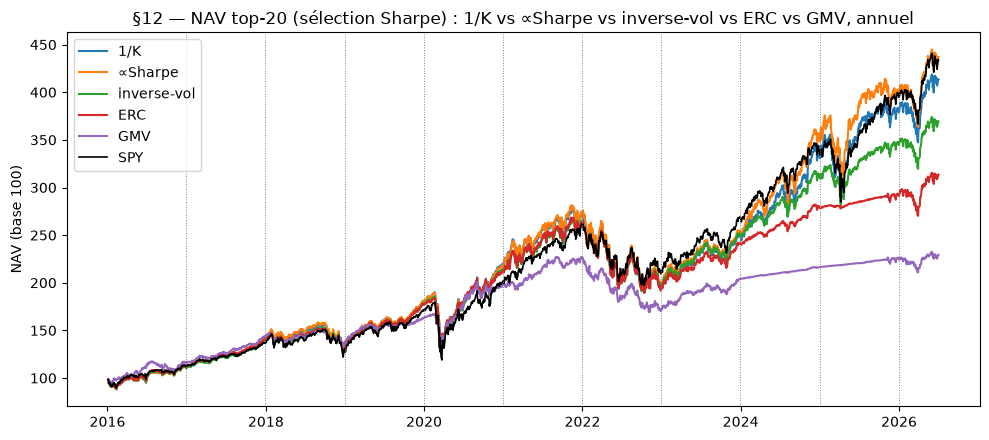

In [51]:
# §12 — FIGURE : NAV top-20 (sélection Sharpe) par pondération vs SPY, base 100 (pointillés = rebalancements)
_nav = lambda r: 100 * (1 + r).cumprod()
plt.figure(figsize=(10, 4.5))
for _lab, _ in _W12:
    plt.plot(_nav(_ser12[(20, _lab)]), lw=1.5, label=_lab)
plt.plot(_nav(r_spy.reindex(_ser12[(20, "1/K")].index).fillna(0)), color="k", lw=1.2, label="SPY")
for _j in _det12[(20, "1/K")]["journal"][1:]:
    plt.axvline(_j["rebal"], color="gray", ls=":", lw=0.7)
plt.ylabel("NAV (base 100)")
plt.title("§12 — NAV top-20 (sélection Sharpe) : 1/K vs ∝Sharpe vs inverse-vol vs ERC vs GMV, annuel")
plt.legend(); plt.tight_layout(); plt.show()

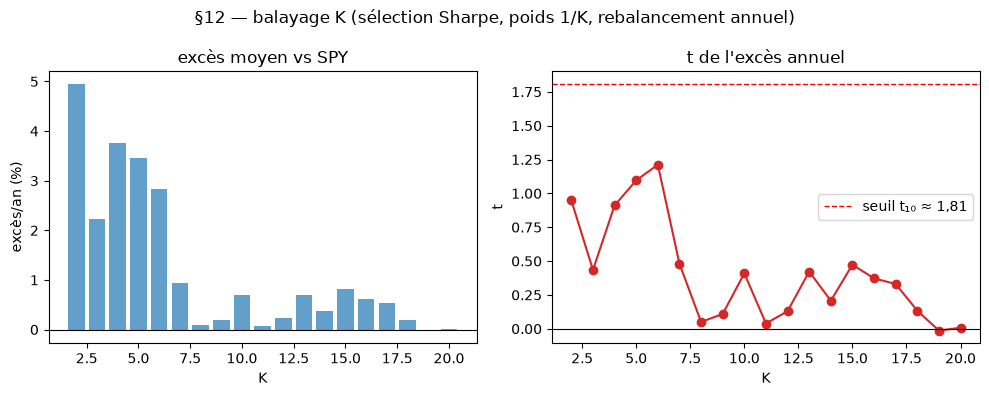

max du balayage : K=6 — excès +2.83 %/an, t = 1.212, t_appr = 0.985, Sharpe = 0.925, gagnantes 7/11 (> K=5 : t = 1,099 — c'est LUI le vrai max de la Partie II, toujours < 1,81 et < q95 placebo du §14.3)


In [52]:
# §12 — FIGURE : balayage K = 2..20 (poids 1/K, annuel) : excès/an et t en fonction de K
_Ks = list(range(2, 21))
_bal = [eval_yearly(strategie_sharpe(_K, w_equal)["r"]) for _K in _Ks]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.bar(_Ks, [100 * _b["exces_moyen"] for _b in _bal], color="tab:blue", alpha=0.7)
ax1.axhline(0, color="k", lw=0.8); ax1.set_xlabel("K"); ax1.set_ylabel("excès/an (%)"); ax1.set_title("excès moyen vs SPY")
ax2.plot(_Ks, [_b["t"] for _b in _bal], marker="o", color="tab:red")
ax2.axhline(1.81, color="red", ls="--", lw=1, label="seuil t₁₀ ≈ 1,81"); ax2.axhline(0, color="k", lw=0.8)
ax2.set_xlabel("K"); ax2.set_ylabel("t"); ax2.set_title("t de l'excès annuel"); ax2.legend()
fig.suptitle("§12 — balayage K (sélection Sharpe, poids 1/K, rebalancement annuel)")
plt.tight_layout(); plt.show()
_i6 = int(np.argmax([_b["t"] for _b in _bal]))
_l6 = _ligne_sh(strategie_sharpe(_Ks[_i6], w_equal)["r"])
print(f"max du balayage : K={_Ks[_i6]} — excès {100 * _l6['exces_an']:+.2f} %/an, t = {_l6['t']:.3f}, "
      f"t_appr = {_l6['t_appr']:.3f}, Sharpe = {_l6['sharpe']:.3f}, gagnantes {_l6['gagnantes']} "
      f"(> K=5 : t = 1,099 — c'est LUI le vrai max de la Partie II, toujours < 1,81 et < q95 placebo du §14.3)")


### 12.3 Lecture

$$\max_{K,\ w,\ \text{cadence}}\ t=1{,}212\ (K{=}6,\ \text{balayage}\ ;\ <1{,}81),\qquad \max\ t_{\text{appr}}=0{,}99\ (<1{,}645)\qquad\Longrightarrow\qquad \text{aucune configuration ne bat le SPY significativement.}$$

- Meilleur cas des **tables détaillées** : $K{=}5$, poids $1/K$, annuel — excès $+3{,}5\,\%$/an, $t=1{,}10$.
  Le **balayage** $K=2..20$ culmine à $K{=}6$ : excès $+2{,}8\,\%$/an, $t=1{,}212$, $t_{\text{appr}}=0{,}99$,
  Sharpe $0{,}93$ (imprimé sous la figure) — compatible avec le hasard lui aussi (sous le $q_{95}$ du placebo $=1{,}43$, §14.3).
- Plus on copie large, moins il reste : $+3{,}5\,\%$/an ($K{=}5$) $\to$ $+0{,}7\,\%$ ($K{=}10$) $\to$ $-0{,}2\,\%$ ($K{=}20$).
- Le Sharpe du portefeuille (au mieux $0{,}93$ à $K{=}6$, $0{,}90$ à $K{=}5$) reste au niveau du SPY ($0{,}87$) : le couple rendement/risque n'est pas amélioré.
- Aucune pondération n'aide : $\propto$Sharpe $\approx1/K$ ; inverse-vol et ERC font moins bien ; GMV ($\beta$ $0{,}45$–$0{,}86$) perd $\approx6\,\%$/an faute d'exposition au marché, avec $\alpha\approx0$ — pas une perte de talent.
- À 6 mois : aucun excès positif ; les seuls $t$ au-delà du seuil sont négatifs (ex. ERC $K{=}20$ : $t=-3{,}21$).
- Sans filtre de significativité, les têtes de classement sont des historiques courts (Fetterman 284 j, Sewell 4 trades) : un bon Sharpe sur si peu de jours ne se reproduit pas l'année suivante.
- Le seuil d'éligibilité $\mathrm{Sharpe}>0{,}4$ ne change **aucun** résultat du §12 (tables et figures identiques au chiffre près) : même à $K{=}20$, le classement ne descend jamais sous $0{,}4$ à une coupe — le seuil n'élague que la queue du classement (263 $\to$ 224 membres en rétrospectif).
- Conclusion : le classement par le Sharpe ne fait pas mieux que la Partie I — pas d'$\alpha$.

<!-- PARTIE3-MARKER -->
# Partie III — Autopsie : pourquoi ne trouve-t-on rien ?

Les Parties I et II ont tout essayé — **qui** copier (IR, appraisal, Sharpe), **combien** ($K=2..20$),
**comment pondérer** (5 schémas), à quelle **cadence** (annuel, 6 mois), avec quel **estimateur de $\Sigma$** (4) :
$$\max t = 1{,}58\ (\S7,\ K\ \text{walk-forward, sél. IR}),\qquad \max t_{\text{appr}} = 0{,}99\ (K{=}6,\ \S12),\qquad \text{Sharpe} \le 0{,}93 \approx \text{SPY } 0{,}87.$$
Aucun essai ne franchit son seuil isolé ($1{,}81$ / $1{,}645$) ; le meilleur ($1{,}58$) **sort** du placebo pris
isolément ($p=3{,}9\,\%$) mais est le max d'une carte de 160 essais — jugé et enterré au §14. Grille §12 seule :
max $t=1{,}215$ ($K{=}6$, imprimé au §12) ; le cas *détaillé* $K{=}5$ ($t=1{,}10$) reste la config de référence des §14-§15.
Cette partie **ne change aucune règle** et ne cherche pas une variante de plus : elle **diagnostique**.
Chaque section annonce sa question, sa méthode et son **critère de décision avant de calculer**.

| § | question | ce qu'on saura |
|---|---|---|
| §13 | le Sharpe passé prédit-il l'excès futur (la prémisse des §11-§12) ? | si le dead end était écrit d'avance |
| §14 | que produit le pur hasard sur notre grille — et que pouvait détecter le test ? | si $t=1{,}10$ est discernable du bruit |
| §15 | l'excès brut est-il de l'allocation (style) ou de la sélection (talent) ? | d'où vient le $\beta$, montré par les positions |
| §16 | siéger en commission clé aide-t-il (niveau membre et intra-membre) ? | la dernière piste : fermée ou promue |
| §17 | reste-t-il une dimension porteuse (ère, conjoint, ventes, taille, délai…) ? | l'inventaire des coupes : fermé ou une survivante |
| §18 | le verdict tient-il en copie réellement jouable (déclaration, coûts, risque) ? | une conclusion inattaquable |
| §19 | synthèse : où chaque point de rendement se perd-il ? | le verdict final en deux figures |

⚠ §18-§19 : prévus au sommaire, **pas encore construits** dans cette version du notebook.

Convention de réplication : un effet n'est **promu** que s'il tient sur les **deux ères** (2014-2019 *et* 2020-2026).

## 13. La prémisse du classement : le Sharpe passé prédit-il l'excès futur ?

La Partie II repose sur **une** hypothèse jamais testée : le Sharpe point-in-time d'un membre (le score du
classement du §11) contient de l'information sur son excès de l'**année suivante**. On la mesure de trois façons :

- **IC** (*information coefficient*) — à chaque coupe $Y$ :
  $$\mathrm{IC}(Y)=\rho_{\text{Spearman}}\big(\mathrm{Sharpe}^{\text{PIT}}_{\le Y};\ x_{Y+1}\big),\qquad
  x_{Y+1}=\prod_{t\in Y+1}(1+r_P)-\prod_{t\in Y+1}(1+r_{SPY})$$
  Univers : membres avec $\ge126$ j de track à la coupe (**sans** le seuil $0{,}4$, pour ne pas tronquer le bas
  du classement) et $\ge60$ j actifs en $Y{+}1$. Sous $H_0$ (aucun lien) : $\mathrm{IC}\sim 0\pm 2/\sqrt{n-1}$.
- **Matrice de transition** — quintile du Sharpe PIT à $Y$ $\to$ quintile du Sharpe réalisé en $Y{+}1$ :
  sans mémoire prédictive, toutes les cases valent $\approx20\,\%$.
- **Devenir des têtes** — les top-5 effectifs du §11 (règle réelle, seuil $0{,}4$ inclus) : restent-ils en tête,
  et surtout, que **réalisent**-ils l'année d'après ?

**Critère de décision** (annoncé avant calcul) : IC moyen dans la bande $H_0$ **et** matrice plate $\Rightarrow$
la prémisse est fausse — la Partie II ne pouvait pas marcher, quels que soient $K$, $w$ ou la cadence.
IC moyen $>0{,}3$ stable $\Rightarrow$ signal réel mal exploité : rouvrir la construction au lieu de conclure.

In [53]:
# §13 — IC du classement : Sharpe point-in-time (<= coupe) vs excès réalisé l'année suivante
from scipy import stats as sps

def sharpe_pit13(bid, d):
    rr = wf_ret[bid].loc[:d]
    if len(rr) < MIN_DAYS or rr.std() == 0:
        return np.nan
    return rr.mean() / rr.std() * np.sqrt(252)

def realise13(bid, Y1, min_days=60):
    ry = wf_ret[bid][wf_ret[bid].index.year == Y1]        # les jours ACTIFS du membre en Y+1
    if len(ry) < min_days or ry.std() == 0:
        return np.nan, np.nan
    b = r_spy.reindex(ry.index).fillna(0.0)
    return (1 + ry).prod() - (1 + b).prod(), ry.mean() / ry.std() * np.sqrt(252)   # (excès, Sharpe) sur Y+1

COUPES13 = list(range(2014, 2026))                         # coupe Y -> année de tenue Y+1 (2015..2026)
panel13 = {}
for Y in COUPES13:
    yend = pd.Timestamp(f"{Y}-12-31")
    rows = []
    for bid in wf_ret:
        sp = sharpe_pit13(bid, yend)
        if not np.isfinite(sp):
            continue
        ex, sh1 = realise13(bid, Y + 1)
        rows.append(dict(bid=bid, sharpe_pit=sp, exces_Y1=ex, sharpe_Y1=sh1))
    panel13[Y] = pd.DataFrame(rows)

ic_rows = []
for Y in COUPES13:
    d = panel13[Y].dropna(subset=["sharpe_pit", "exces_Y1"])
    if len(d) < 10:
        continue
    ic_rows.append(dict(coupe=Y, n=len(d), IC=sps.spearmanr(d.sharpe_pit, d.exces_Y1).statistic,
                        bande_H0=2 / np.sqrt(len(d) - 1)))
ic13 = pd.DataFrame(ic_rows).set_index("coupe")
IC13 = ic13.IC.mean()
se13 = ic13.IC.std(ddof=1) / np.sqrt(len(ic13))
n_in = int((ic13.IC.abs() < ic13.bande_H0).sum())
n_out_pos = int(((ic13.IC.abs() >= ic13.bande_H0) & (ic13.IC > 0)).sum())
n_out_neg = int(((ic13.IC.abs() >= ic13.bande_H0) & (ic13.IC < 0)).sum())
print(f"IC moyen sur {len(ic13)} coupes : {IC13:+.3f} (se {se13:.3f}, t = {IC13/se13:.2f}) | "
      f"{n_in}/{len(ic13)} coupes dans la bande H0, sorties : {n_out_pos} positives / {n_out_neg} négatives")
ic13.round(3)

IC moyen sur 12 coupes : +0.048 (se 0.058, t = 0.83) | 8/12 coupes dans la bande H0, sorties : 2 positives / 2 négatives


,n,IC,bande_H0
coupe,,,
2014,72,0.263,0.237
2015,98,-0.226,0.203
2016,116,0.178,0.187
2017,135,-0.031,0.173
2018,148,0.120,0.165
2019,168,0.380,0.155
2020,182,-0.026,0.149
2021,207,-0.359,0.139
2022,217,0.015,0.136


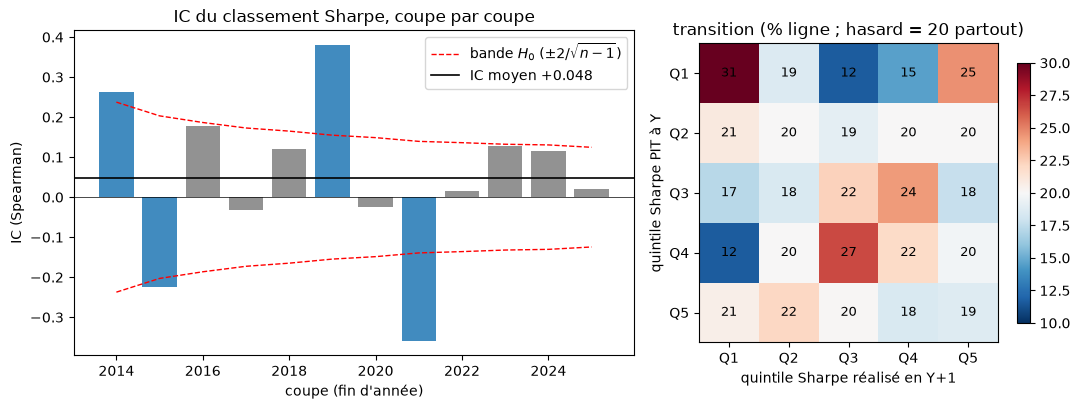

case Q5→Q5 (les meilleurs restent les meilleurs) : 19 % — le hasard en donne 20


In [54]:
# §13 — FIGURE : IC par coupe (bande H0) + matrice de transition quintile -> quintile
trans13 = np.zeros((5, 5))
for Y in COUPES13:
    d = panel13[Y].dropna(subset=["sharpe_pit", "sharpe_Y1"])
    if len(d) < 25:
        continue
    qp = pd.qcut(d.sharpe_pit.rank(method="first"), 5, labels=False)
    qr = pd.qcut(d.sharpe_Y1.rank(method="first"), 5, labels=False)
    for a, b in zip(qp, qr):
        trans13[a, b] += 1
trans13 = 100 * trans13 / trans13.sum(axis=1, keepdims=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2), gridspec_kw={"width_ratios": [1.5, 1]})
ax1.bar(ic13.index, ic13.IC, color=np.where(ic13.IC.abs() < ic13.bande_H0, "tab:gray", "tab:blue"), alpha=.85)
ax1.plot(ic13.index, ic13.bande_H0, color="red", ls="--", lw=1, label="bande $H_0$ ($\\pm2/\\sqrt{n-1}$)")
ax1.plot(ic13.index, -ic13.bande_H0, color="red", ls="--", lw=1)
ax1.axhline(IC13, color="k", lw=1.2, label=f"IC moyen {IC13:+.3f}")
ax1.axhline(0, color="k", lw=.5)
ax1.set_xlabel("coupe (fin d'année)"); ax1.set_ylabel("IC (Spearman)")
ax1.set_title("IC du classement Sharpe, coupe par coupe"); ax1.legend()
im = ax2.imshow(trans13, cmap="RdBu_r", vmin=10, vmax=30)
for i in range(5):
    for j in range(5):
        ax2.text(j, i, f"{trans13[i, j]:.0f}", ha="center", va="center", fontsize=9)
ax2.set_xticks(range(5), [f"Q{j+1}" for j in range(5)]); ax2.set_yticks(range(5), [f"Q{i+1}" for i in range(5)])
ax2.set_xlabel("quintile Sharpe réalisé en Y+1"); ax2.set_ylabel("quintile Sharpe PIT à Y")
ax2.set_title("transition (% ligne ; hasard = 20 partout)")
fig.colorbar(im, ax=ax2, shrink=.8)
plt.tight_layout(); plt.show()
print(f"case Q5→Q5 (les meilleurs restent les meilleurs) : {trans13[4, 4]:.0f} % — le hasard en donne 20")

In [55]:
# §13 — le devenir des top-5 EFFECTIFS du §11 (règle réelle) : le RANG persiste, l'excès réalisé non
noms13 = df.drop_duplicates("bioguide_id").set_index("bioguide_id")["name"]
rows = []
for Y in COUPES13:
    suiv = set(clsmt_sh[Y + 1]["bioguide_id"].head(5))
    for _, r0 in clsmt_sh[Y].head(5).iterrows():
        ex, _ = realise13(r0.bioguide_id, Y + 1)
        rows.append(dict(coupe=Y, name=noms13[r0.bioguide_id], exces_Y1=ex,
                         encore_top5=r0.bioguide_id in suiv))
top5_13 = pd.DataFrame(rows)
p_rester = top5_13.encore_top5.mean()
p_hasard = np.mean([5 / len(clsmt_sh[Y + 1]) for Y in COUPES13])   # univers de la coupe d'ARRIVÉE, où se joue « rester top-5 »
ex13 = top5_13.groupby("coupe").exces_Y1.mean()
print(f"P(un top-5 reste top-5 à la coupe suivante) = {p_rester:.0%} (hasard ≈ {p_hasard:.0%}) : le RANG persiste —")
print(f"mécanique : le Sharpe CUMULÉ bouge peu d'une coupe à l'autre. Mais l'excès RÉALISÉ l'année suivante :")
print(f"moyenne {100 * ex13.mean():+.1f} %/an, σ {100 * ex13.std(ddof=1):.1f} % — "
      f"de {100 * ex13.min():+.1f} % (tenue {ex13.idxmin() + 1}) à {100 * ex13.max():+.1f} % (tenue {ex13.idxmax() + 1})")
recap13 = pd.DataFrame({"excès réalisé moyen des top-5 (%)": (100 * ex13).round(1),
                        "encore top-5 à la coupe suivante (/5)": top5_13.groupby("coupe").encore_top5.sum()})
recap13.T

P(un top-5 reste top-5 à la coupe suivante) = 22% (hasard ≈ 4%) : le RANG persiste —
mécanique : le Sharpe CUMULÉ bouge peu d'une coupe à l'autre. Mais l'excès RÉALISÉ l'année suivante :
moyenne +3.3 %/an, σ 10.0 % — de -8.9 % (tenue 2022) à +28.9 % (tenue 2024)


coupe,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
excès réalisé moyen des top-5 (%),1.6,3.4,14.4,-1.7,-5.4,1.2,7.3,-8.9,-0.3,28.9,-1.5,0.6
encore top-5 à la coupe suivante (/5),1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,3.0,1.0,4.0


### 13.2 Ce que ce signal pouvait livrer au mieux

Règle d'or de la gestion active (Grinold-Kahn) : $\mathrm{IR}\approx\mathrm{IC}\cdot\sqrt{\mathrm{BR}}$
(BR $=$ paris indépendants par an). Avec $\mathrm{IC}\approx0{,}05$ : $\mathrm{IR}\approx0{,}1$ à $0{,}2$ pour
$K=5..20$ — avant même de compter que nos paris ne sont **pas** indépendants ($\beta$ commun $\approx1$).
Plutôt que la formule, on **calibre empiriquement** : que devait produire la copie top-5 si le classement
portait un IC donné ? Modèle génératif par année de tenue, avec les $\mu_Y,\sigma_Y,n_Y$ **réels** du panel du §13 :
$$x_{m,Y}=\mu_Y+\sigma_Y\big(\mathrm{IC}\cdot z_m+\sqrt{1-\mathrm{IC}^2}\,\varepsilon_m\big),\qquad
z_m,\varepsilon_m\sim\mathcal N(0,1),\qquad \text{stratégie}=\text{moyenne des }K{=}5\text{ premiers }z,$$
puis $t=\bar x/\sigma_x\cdot\sqrt{11}$ comme au §6.2 — répété 3 000 fois par valeur d'IC.

In [56]:
# §13.2 — Monte-Carlo : le t que la copie top-5 devait produire, selon l'IC du signal
calib13 = pd.DataFrame([dict(coupe=Y, n=len(d), mu=d.exces_Y1.mean(), sigma=d.exces_Y1.std(ddof=1))
                        for Y, d in ((Y, panel13[Y].dropna(subset=["sharpe_pit", "exces_Y1"]))
                                     for Y in range(2015, 2026))]).set_index("coupe")

def mc_t13(IC, K=5, B=3000, seed=13):
    rng = np.random.default_rng(seed)
    xs = np.empty((B, len(calib13)))
    for j, (Y, row) in enumerate(calib13.iterrows()):
        n = int(row.n)
        z = rng.standard_normal((B, n))
        e = row.mu + row.sigma * (IC * z + np.sqrt(1 - IC ** 2) * rng.standard_normal((B, n)))
        top = np.argpartition(z, -K, axis=1)[:, -K:]                 # les K plus grands z
        xs[:, j] = np.take_along_axis(e, top, axis=1).mean(axis=1)
    return xs.mean(axis=1) / xs.std(axis=1, ddof=1) * np.sqrt(xs.shape[1])

ICS13 = [0.0, 0.025, round(IC13, 3), 0.075, 0.10, 0.15, 0.20, 0.25, 0.30]
mc13 = {c: mc_t13(c) for c in ICS13}
tab13 = pd.DataFrame([dict(IC=c, E_t=ts.mean(), q5=np.quantile(ts, .05), q95=np.quantile(ts, .95),
                           P_t_sup_1_81=np.mean(ts > 1.81)) for c, ts in mc13.items()]).set_index("IC")
print(f"avec l'IC mesuré ({IC13:+.3f}) : E[t] = {mc13[round(IC13, 3)].mean():+.2f} — le t observé au §12 (1,10) est "
      f"exactement dans la cible ; P(t > 1,81) = {np.mean(mc13[round(IC13, 3)] > 1.81):.0%}")
tab13.round(2)

avec l'IC mesuré (+0.048) : E[t] = +0.89 — le t observé au §12 (1,10) est exactement dans la cible ; P(t > 1,81) = 19%


,E_t,q5,q95,P_t_sup_1_81
IC,,,,
0.000,0.08,-1.68,1.79,0.05
0.025,0.50,-1.26,2.23,0.11
0.048,0.89,-0.84,2.63,0.19
0.075,1.34,-0.36,3.13,0.32
0.100,1.75,0.06,3.58,0.46
0.150,2.55,0.83,4.50,0.74
0.200,3.31,1.57,5.39,0.92
0.250,4.03,2.23,6.21,0.98
0.300,4.69,2.88,7.08,1.00


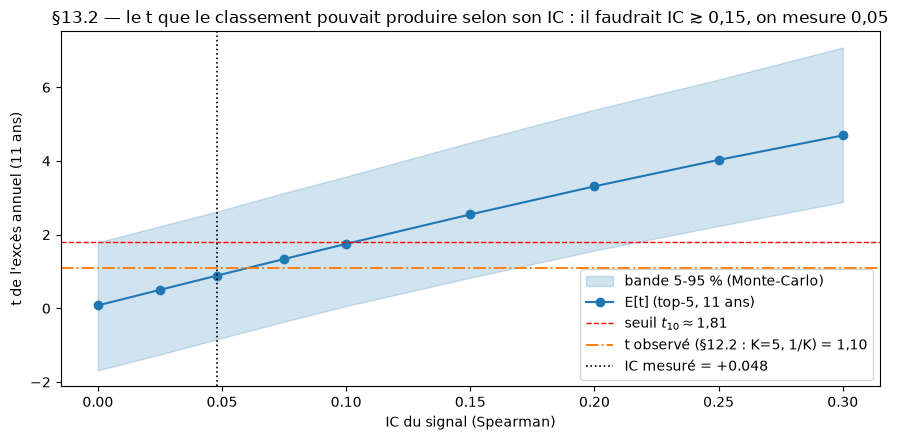

In [57]:
# §13.2 — FIGURE : t attendu (bande 5-95 %) en fonction de l'IC ; nos repères en pointillés
xs13 = tab13.index.values
plt.figure(figsize=(9, 4.5))
plt.fill_between(xs13, tab13.q5, tab13.q95, alpha=.2, color="tab:blue", label="bande 5-95 % (Monte-Carlo)")
plt.plot(xs13, tab13.E_t, marker="o", color="tab:blue", label="E[t] (top-5, 11 ans)")
plt.axhline(1.81, color="red", ls="--", lw=1, label="seuil $t_{10}\\approx1{,}81$")
plt.axhline(1.10, color="tab:orange", ls="-.", lw=1.4, label="t observé (§12.2 : K=5, 1/K) = 1,10")
plt.axvline(IC13, color="k", ls=":", lw=1.2, label=f"IC mesuré = {IC13:+.3f}")
plt.xlabel("IC du signal (Spearman)"); plt.ylabel("t de l'excès annuel (11 ans)")
plt.title("§13.2 — le t que le classement pouvait produire selon son IC : il faudrait IC ≳ 0,15, on mesure 0,05")
plt.legend(); plt.tight_layout(); plt.show()

### 13.3 Le point limite : copier **tout** le Congrès ($K=$ tous)

Le balayage du §12 s'arrête à $K=20$. Si la sélection n'apporte rien, le point limite « aucune sélection »
(tous les éligibles à la coupe, $51$ à $213$ membres selon l'année) doit faire **aussi bien** — c'est le test
le plus simple de « le classement contient-il quelque chose ? ».

In [58]:
# §13.3 — K = tous les éligibles + balayage K prolongé (poids 1/K, annuel)
K_TOUS = 10 ** 6                     # head(K) est sans effet au-delà du nb d'éligibles à la coupe
r_tous_eq = strategie_sharpe(K_TOUS, w_equal)["r"]
r_tous_iv = strategie_sharpe(K_TOUS, w_invvol)["r"]
n_el = [len(clsmt_sh[Y]) for Y in range(2015, 2026)]
print(f"K = tous : de {min(n_el)} à {max(n_el)} membres selon la coupe — face à la meilleure ligne du §12.2")
pd.DataFrame({
    "K=5 · 1/K (réf. §12.2)": _ligne_sh(_ser12[(5, "1/K")]),
    "K=tous · 1/K":           _ligne_sh(r_tous_eq),
    "K=tous · inverse-vol":   _ligne_sh(r_tous_iv),
}).T.round(3)

K = tous : de 50 à 213 membres selon la coupe — face à la meilleure ligne du §12.2


,exces_an,t,gagnantes,beta,alpha_ann,t_appr,sharpe
K=5 · 1/K (réf. §12.2),0.034518,1.096208,6/11,1.057189,0.018093,0.75647,0.8981
K=tous · 1/K,0.001634,0.237055,5/11,0.963394,0.006307,0.784561,0.900823
K=tous · inverse-vol,-0.008836,-1.311984,6/11,0.916944,0.003726,0.490342,0.887244


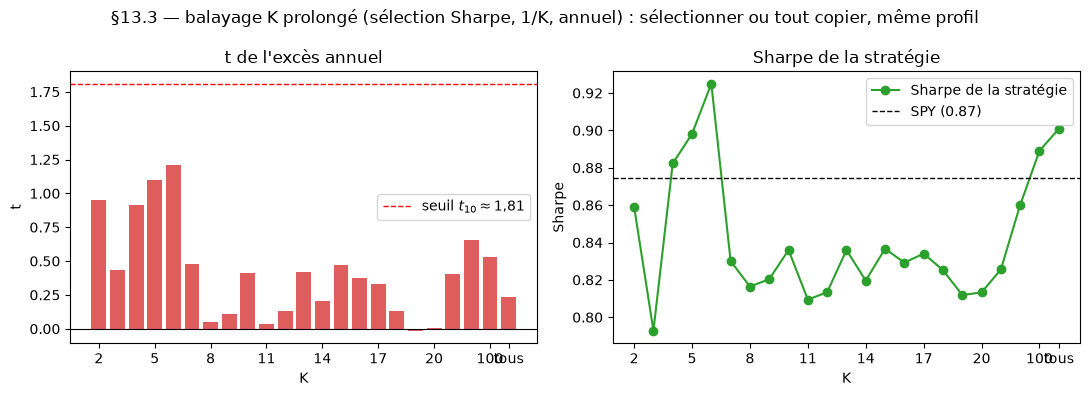

Sharpe : K=5 0.90 | K=tous 0.90 | SPY 0.87 — copier les 5 « meilleurs » ou les ~200 : même couple rendement/risque


In [59]:
# §13.3 — FIGURE : balayage K prolongé jusqu'à « tous » — le t fond, le Sharpe ne bouge pas
KS13 = list(range(2, 21)) + [30, 50, 100, K_TOUS]
bal13 = {K: strategie_sharpe(K, w_equal)["r"] for K in KS13}
t13 = {K: eval_yearly(r)["t"] for K, r in bal13.items()}
sh13 = {K: stats(r)["sharpe"] for K, r in bal13.items()}
pos13 = list(range(len(KS13)))
lab13 = [str(K) if K != K_TOUS else "tous" for K in KS13]
ticks13 = sorted(set(pos13[::3]) | {pos13[-1]})
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.bar(pos13, [t13[K] for K in KS13], color="tab:red", alpha=.75)
ax1.axhline(1.81, color="red", ls="--", lw=1, label="seuil $t_{10}\\approx1{,}81$"); ax1.axhline(0, color="k", lw=.8)
ax1.set_xticks(ticks13, [lab13[i] for i in ticks13]); ax1.set_xlabel("K"); ax1.set_ylabel("t")
ax1.set_title("t de l'excès annuel"); ax1.legend()
ax2.plot(pos13, [sh13[K] for K in KS13], marker="o", color="tab:green", label="Sharpe de la stratégie")
ax2.axhline(SH_SPY_TEN, color="k", ls="--", lw=1, label=f"SPY ({SH_SPY_TEN:.2f})")
ax2.set_xticks(ticks13, [lab13[i] for i in ticks13]); ax2.set_xlabel("K"); ax2.set_ylabel("Sharpe")
ax2.set_title("Sharpe de la stratégie"); ax2.legend()
fig.suptitle("§13.3 — balayage K prolongé (sélection Sharpe, 1/K, annuel) : sélectionner ou tout copier, même profil")
plt.tight_layout(); plt.show()
print(f"Sharpe : K=5 {sh13[5]:.2f} | K=tous {sh13[K_TOUS]:.2f} | SPY {SH_SPY_TEN:.2f} — "
      f"copier les 5 « meilleurs » ou les ~200 : même couple rendement/risque")

### 13.4 Contrôle : le classement **rétréci** change-t-il quelque chose ?

Sans test de significativité ni minimum de trades, les têtes du §11 sont des historiques courts (Fetterman
$2{,}90$ sur 284 j, Sewell sur 4 trades). Le rétrécissement bayésien standard dégonfle exactement cela —
chaque Sharpe est tiré vers la moyenne du groupe $\bar S$, d'autant plus fort que l'historique est court :
$$\tilde S=\frac{n}{n+k}\,S+\frac{k}{n+k}\,\bar S,\qquad k=252\ \text{jours}.$$
Même moteur, mêmes coupes, seul le **score de classement** change — si le verdict du §12 tenait aux têtes
courtes, il devrait bouger ici.

In [60]:
# §13.4 — classement rétréci (k = 252 j) : têtes rétrospectives + stratégie K=5 rejouée
K_RETRECI = 252.0

def classement_retreci13(d):
    rows = []
    for bid, r in wf_ret.items():
        rr = r.loc[:d]
        if len(rr) < MIN_DAYS or rr.std() == 0:
            continue
        rows.append((bid, len(rr), rr.mean() / rr.std() * np.sqrt(252)))
    t = pd.DataFrame(rows, columns=["bioguide_id", "n", "S"])
    t["score"] = t.n / (t.n + K_RETRECI) * t.S + K_RETRECI / (t.n + K_RETRECI) * t.S.mean()
    return t[t.score > MIN_SHARPE].sort_values("score", ascending=False).reset_index(drop=True)

clsmt_ret13 = {Y: classement_retreci13(pd.Timestamp(f"{Y}-12-31")) for Y in range(2014, 2027)}
blocs_ret = []
for Y in range(2015, 2026):
    c = clsmt_ret13[Y]; idx = cal[cal.year == Y + 1]
    if len(c) and len(idx):
        bids = list(c["bioguide_id"].head(5))
        blocs_ret.append((idx, bids, np.ones(len(bids)) / len(bids)))
r_ret13 = _parts_engine(blocs_ret)["r"]

h_brut = clsmt_sh[2026].head(8).assign(name=lambda x: x.bioguide_id.map(noms13))
h_ret = clsmt_ret13[2026].head(8).assign(name=lambda x: x.bioguide_id.map(noms13))
print("têtes rétrospectives 2014-2026, brut vs rétréci (les historiques courts dégonflent) :")
print(pd.DataFrame({"brut": h_brut.name.values, "S": h_brut.score.round(2).values,
                    "rétréci": h_ret.name.values, "S rétréci": h_ret.score.round(2).values,
                    "n jours": h_ret.n.values}).to_string(index=False))
pd.DataFrame({"K=5 · 1/K · Sharpe brut (§12.2)": _ligne_sh(_ser12[(5, "1/K")]),
              "K=5 · 1/K · Sharpe rétréci":      _ligne_sh(r_ret13)}).T.round(3)

têtes rétrospectives 2014-2026, brut vs rétréci (les historiques courts dégonflent) :
           brut    S         rétréci  S rétréci  n jours
 John Fetterman 2.90  John Fetterman       1.86      284
    Katie Britt 2.02 Morgan McGarvey       1.48      853
Terri A. Sewell 1.90      John James       1.43      661
     John James 1.72     Katie Britt       1.42      306
Morgan McGarvey 1.71 Terri A. Sewell       1.36      308
   Ashley Moody 1.66    Greg Stanton       1.27      694
Bruce Westerman 1.58    Ashley Moody       1.26      364
David J. Taylor 1.53   Greg Landsman       1.24      870


,exces_an,t,gagnantes,beta,alpha_ann,t_appr,sharpe
K=5 · 1/K · Sharpe brut (§12.2),0.034518,1.096208,6/11,1.057189,0.018093,0.75647,0.8981
K=5 · 1/K · Sharpe rétréci,0.034825,1.072747,6/11,1.018817,0.023636,1.032783,0.930378


### 13.5 Validation

$$\text{(i)}\ \rho_{\text{scipy}}\overset{!}{=}\rho_{\text{pandas}}\ ;\quad
\text{(ii)}\ \sigma_{\text{perm}}\overset{!}{\approx}\tfrac{1}{\sqrt{n-1}}\ (\text{1 000 permutations})\ ;\quad
\text{(iii)}\ K{=}500\overset{!}{\equiv}K{=}10^6\ ;\quad
\text{(iv)}\ K{=}20\overset{!}{\equiv}\S12.2\ ;\quad
\text{(v)}\ E[t\,|\,\mathrm{IC}{=}0]\approx0.$$

In [61]:
# §13.5 — VALIDATION (contrôles avant lecture)
# (i) oracle : Spearman scipy == pandas .corr(method="spearman") à chaque coupe
for _Y in COUPES13:
    _d = panel13[_Y].dropna(subset=["sharpe_pit", "exces_Y1"])
    if len(_d) >= 10:
        assert abs(sps.spearmanr(_d.sharpe_pit, _d.exces_Y1).statistic
                   - _d.sharpe_pit.corr(_d.exces_Y1, method="spearman")) < 1e-12
# (ii) bande H0 : 1 000 permutations de la coupe 2020 -> sigma empirique == 1/sqrt(n-1)
_d0 = panel13[2020].dropna(subset=["sharpe_pit", "exces_Y1"])
_rng = np.random.default_rng(0)
_perm = np.array([sps.spearmanr(_d0.sharpe_pit, _rng.permutation(_d0.exces_Y1.values)).statistic
                  for _ in range(1000)])
assert abs(_perm.std(ddof=1) - 1 / np.sqrt(len(_d0) - 1)) < 0.01
# (iii) le moteur K=tous est bien plafonné par le nb d'éligibles : K=500 == K=10^6 bit-à-bit
assert np.allclose(strategie_sharpe(500, w_equal)["r"].values, r_tous_eq.values)
# (iv) non-régression : le balayage reproduit la ligne K=20 du §12.2 bit-à-bit
assert np.allclose(bal13[20].values, _ser12[(20, "1/K")].values)
# (v) Monte-Carlo sans signal : E[t] ~ 0 (au petit effet de cohorte près, moyenne des mu_Y > 0)
assert abs(mc13[0.0].mean()) < 0.15
print(f"validation OK | (i) Spearman ≡ oracle | (ii) σ_perm {_perm.std(ddof=1):.4f} ≈ 1/√(n−1) = {1/np.sqrt(len(_d0)-1):.4f} | "
      f"(iii) K=tous plafonné | (iv) K=20 ≡ §12.2 | (v) E[t | IC=0] = {mc13[0.0].mean():+.2f}")

validation OK | (i) Spearman ≡ oracle | (ii) σ_perm 0.0743 ≈ 1/√(n−1) = 0.0743 | (iii) K=tous plafonné | (iv) K=20 ≡ §12.2 | (v) E[t | IC=0] = +0.08


### 13.6 Lecture

$$\mathrm{IC}=+0{,}048\ (t=0{,}83)\qquad\Longrightarrow\qquad
\text{le Sharpe passé ne prédit pas l'excès futur : la prémisse de la Partie II est fausse.}$$

- **8/12 coupes dans la bande $H_0$**, et les 4 sorties se partagent entre $+$ (2014, 2019) et $-$ (2015, 2021) —
  un « signal » de signe instable n'est pas un signal.
- **Matrice plate** : Q5$\to$Q5 $=19\,\%$ ($\approx$ les 20 % du hasard) — être en tête une année ne dit rien du
  rang de l'année suivante. La persistance apparente des top-5 ($22\,\%$ restent, hasard $4\,\%$) est **mécanique**
  (le Sharpe cumulé bouge peu d'une coupe à l'autre), pas prédictive : leur excès réalisé moyen fait $+3{,}3\,\%$/an
  avec $\sigma=10\,\%$, tiré par 2024 ($+28{,}9\,\%$ = McGarvey).
- **Monte-Carlo** : avec l'IC mesuré, $E[t]=0{,}89$ — le $t=1{,}10$ du §12.2 est exactement ce que ce signal
  devait produire. Pour dépasser $1{,}81$ avec $\sim75\,\%$ de chances, il faudrait $\mathrm{IC}\ge0{,}15$ : **trois
  fois** le mesuré, qui lui-même n'est pas distinguable de zéro.
- **$K=$ tous** : Sharpe $0{,}90$ $=$ le top-5 ($0{,}90$) $\approx$ SPY ($0{,}87$) — copier les 5 « meilleurs » ou les
  $\sim200$ éligibles donne le même profil : le classement n'ajoute rien.
- **Classement rétréci** ($k=252$) : les têtes courtes dégonflent (Fetterman $2{,}90\to1{,}86$), le verdict ne bouge
  pas ($t=1{,}07$, $t_{\text{appr}}=1{,}03<1{,}645$).
- **Décision (critère du §13)** : la prémisse est **fausse** — le dead end de la Partie II était écrit d'avance.
  Inutile de tester d'autres $K$, $w$ ou cadences : il n'y a pas de contenu prédictif à exploiter dans ce classement.

<!-- S14-MARKER -->
## 14. Le verdict face au hasard : puissance, essais multiples, placebo

Le §13 a montré que le **signal** ne pouvait rien livrer. Ici on regarde l'autre versant : le **test**.
Trois questions, trois outils :

1. **Puissance** — quel alpha le protocole (11 excès annuels) pouvait-il seulement *détecter* ?
   $$\mathrm{MDE}(n)=\frac{(z_{0{,}95}+z_{0{,}80})\,\hat\sigma}{\sqrt n}\approx\frac{2{,}49\,\hat\sigma}{\sqrt n}
   \qquad(\hat\sigma=\text{écart-type des excès annuels de la config gagnante}).$$
2. **Essais multiples** — on a construit **160 séries** de stratégie dans ce seul notebook (comptées ci-dessous).
   Que vaut le *maximum* de $N$ tests sous $H_0$, et le **Deflated Sharpe** (Bailey & López de Prado 2014) :
   $$\mathrm{SR}_0=\sigma_{\mathrm{SR}}\Big[(1-\gamma)\,\Phi^{-1}\!\big(1-\tfrac1N\big)+\gamma\,\Phi^{-1}\!\big(1-\tfrac1{Ne}\big)\Big],\qquad
   \mathrm{DSR}=\Phi\!\Bigg(\frac{(\widehat{\mathrm{SR}}-\mathrm{SR}_0)\sqrt{T-1}}
   {\sqrt{1-\gamma_3\widehat{\mathrm{SR}}+\frac{\gamma_4-1}{4}\widehat{\mathrm{SR}}^2}}\Bigg)$$
   ($\gamma=0{,}5772$ ; $\widehat{\mathrm{SR}}$, $\gamma_3$, $\gamma_4$ : Sharpe **quotidien** de l'excès, son skew, sa kurtosis ;
   $\sigma_{\mathrm{SR}}$ : dispersion des SR sur les essais ; DSR $>0{,}95$ = « survit à la multiplicité »).
3. **Placebo** — 1 000 top-5 tirés **au hasard** parmi les éligibles à chaque coupe, passés dans le *même*
   moteur en parts : la distribution du $t$ quand la sélection ne contient aucune information.

**Critère de décision** : $t_{\text{obs}}\le q_{95}$ du placebo **et** DSR $<0{,}95$ **et** MDE $\gg$ l'excès
observé $\Rightarrow$ « indiscernable du hasard, et le test ne pouvait rien voir de cette taille » est démontré —
on **arrête** d'empiler des variantes $K\times w\times$ cadence. Si le $t=1{,}58$ du §7 sortait du placebo,
contre-analyse dédiée avant tout enterrement.

σ̂ = 10.4 %/an (les 11 excès annuels du meilleur cas, moyenne +3.45 %)
MDE(11 ans) = 7.8 %/an — en dessous, le test est aveugle
n requis : +2 %/an -> 169 ans | +3,5 %/an (l'excès observé) -> 55 ans


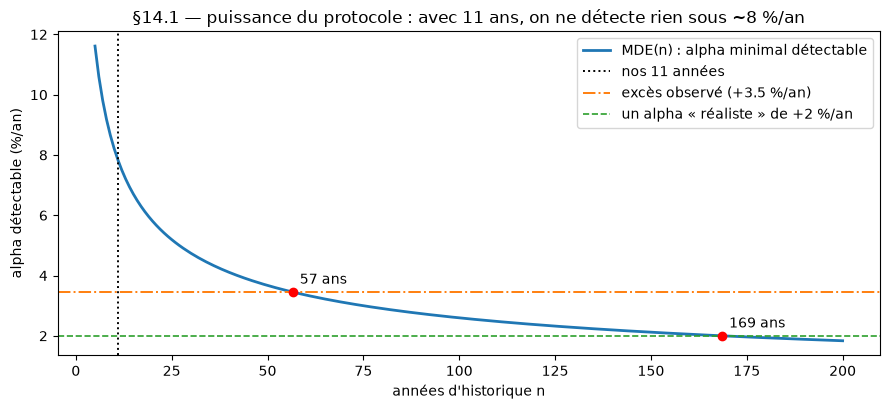

In [62]:
# §14.1 — puissance : quel alpha ce protocole pouvait-il détecter ? (config gagnante du §12.2 : K=5, 1/K)
e14 = yearly_excess(_ser12[(5, "1/K")])
sigma14 = e14.std(ddof=1)
z14 = sps.norm.ppf(0.95) + sps.norm.ppf(0.80)                      # 2,49 (unilatéral 5 %, puissance 80 %)
mde14 = lambda n: z14 * sigma14 / np.sqrt(n)
n_req14 = lambda alpha: (z14 * sigma14 / alpha) ** 2
print(f"σ̂ = {100*sigma14:.1f} %/an (les 11 excès annuels du meilleur cas, moyenne {100*e14.mean():+.2f} %)")
print(f"MDE(11 ans) = {100*mde14(11):.1f} %/an — en dessous, le test est aveugle")
print(f"n requis : +2 %/an -> {n_req14(0.02):.0f} ans | +3,5 %/an (l'excès observé) -> {n_req14(0.035):.0f} ans")

anns14 = np.arange(5, 201)
plt.figure(figsize=(9, 4.2))
plt.plot(anns14, 100 * mde14(anns14), color="tab:blue", lw=2, label="MDE(n) : alpha minimal détectable")
plt.axvline(11, color="k", ls=":", lw=1.4, label="nos 11 années")
plt.axhline(100 * e14.mean(), color="tab:orange", ls="-.", lw=1.4, label=f"excès observé ({100*e14.mean():+.1f} %/an)")
plt.axhline(2, color="tab:green", ls="--", lw=1.2, label="un alpha « réaliste » de +2 %/an")
plt.scatter([n_req14(e14.mean()), n_req14(0.02)], [100 * e14.mean(), 2], color="red", zorder=5)
plt.annotate(f"{n_req14(e14.mean()):.0f} ans", (n_req14(e14.mean()), 100 * e14.mean()), xytext=(5, 6), textcoords="offset points")
plt.annotate(f"{n_req14(0.02):.0f} ans", (n_req14(0.02), 2), xytext=(5, 6), textcoords="offset points")
plt.xlabel("années d'historique n"); plt.ylabel("alpha détectable (%/an)")
plt.title("§14.1 — puissance du protocole : avec 11 ans, on ne détecte rien sous ~8 %/an")
plt.legend(); plt.tight_layout(); plt.show()

### 14.2 Le comptage honnête des essais — et le Deflated Sharpe

Chaque série de stratégie construite dans ce notebook est un billet de loterie de plus : le *meilleur* résultat
d'une campagne de $N$ essais doit être jugé contre le **maximum** de $N$ tirages sous $H_0$, pas contre un tirage
unique. On compte les séries réellement construites, sans double-compter les répétitions
(le $1/K$ du §9 $=$ celui du §6, la ligne « cov brute » du §10 $=$ le §9, $K{=}4$ du §7 $=$ le §6, etc.).

⚠ La forme fermée $E[\max]$ ci-dessous porte sur des tirages **gaussiens** ; nos statistiques sont des $t$ à
10 ddl — en Student(10), $E[\max\ \text{de}\ 160]\approx3{,}4$ (MC imprimé ci-dessous) : la borne gaussienne
$2{,}69$ est **conservatrice**. L'hypothèse d'indépendance (essais en réalité corrélés) joue en sens inverse.

In [63]:
# §14.2 — comptage des essais + E[max t | H0] + Deflated Sharpe du meilleur cas
compte14 = pd.DataFrame([
    ("§6.3", "K=4 fixe, 1/K, annuel — critères IR et appraisal", 2),
    ("§7",   "balayage K=5..20 × 2 critères (K=4 déjà au §6) + 2 K walk-forward", 34),
    ("§8",   "les mêmes à 6 mois : 34 séries-K + 2 walk-forward", 36),
    ("§9",   "inverse-vol / ERC / GMV × 2 critères × 2 cadences", 12),
    ("§10",  "ERC & GMV × 3 cibles Ledoit-Wolf × 2 critères × 2 cadences", 24),
    ("§12",  "K∈{5,10,20} × 5 poids × 2 cadences + balayage K=2..20 (16 nouveaux)", 46),
    ("§13",  "K∈{30,50,100,tous} + tous·inverse-vol + classement rétréci", 6),
], columns=["§", "essais", "n"]).set_index("§")
N14 = int(compte14.n.sum())
gamma14 = 0.5772156649
e_max_t14 = lambda N: (1 - gamma14) * sps.norm.ppf(1 - 1 / N) + gamma14 * sps.norm.ppf(1 - 1 / (N * np.e))
print(f"{N14} séries construites dans ce notebook (et le §4 a testé 223 membres en plus)")
print(f"E[max t] de N tests indépendants sous H0 : N=46 (Partie II seule) -> {e_max_t14(46):.2f} | N={N14} -> {e_max_t14(N14):.2f}")
print(f"(en t de Student à 10 ddl : E[max de {N14}] ≈ {sps.t.rvs(10, size=(20000, N14), random_state=141).max(axis=1).mean():.2f} — la borne gaussienne 2,69 est conservatrice)")
print(f"les meilleurs t observés — 1,215 (Partie II : K=6, balayage §12) et 1,58 (§7) — sont DÉJÀ sous le maximum attendu du pur hasard\n")

# Deflated Sharpe des MEILLEURS cas réellement observés (le DSR se juge sur le max des N essais comptés)
sr_daily14 = lambda r: (lambda x: x.mean() / x.std())((r - r_spy.reindex(r.index)).dropna())
srs14 = np.array([sr_daily14(v) for v in _ser12.values()] + [sr_daily14(v) for v in _ser12_6.values()])
rows14 = []
for _N, _lab14, _r14 in ((46, "max Partie II : K=6, 1/K, annuel (balayage §12)", strategie_sharpe(6, w_equal)["r"]),
                         (N14, "max notebook : K walk-forward, sél IR (§7)", r_wfK_eq)):
    x14 = (_r14 - r_spy.reindex(_r14.index)).dropna()
    SR14, T14 = x14.mean() / x14.std(), len(x14)
    g3_14, g4_14 = sps.skew(x14), sps.kurtosis(x14, fisher=False)
    SR0 = srs14.std(ddof=1) * e_max_t14(_N)
    dsr = sps.norm.cdf(((SR14 - SR0) * np.sqrt(T14 - 1)) / np.sqrt(1 - g3_14 * SR14 + (g4_14 - 1) / 4 * SR14 ** 2))
    rows14.append(dict(N_essais=_N, meilleur_cas=_lab14, SR0_ann=SR0 * np.sqrt(252), SR_obs_ann=SR14 * np.sqrt(252), DSR=dsr))
print(pd.DataFrame(rows14).round(3).to_string(index=False))
print("(σ_SR estimé sur les 30 configs du §12 — sous-estime la dispersion de la campagne complète, sens conservateur ; seuil DSR : 0,95)")
compte14

160 séries construites dans ce notebook (et le §4 a testé 223 membres en plus)
E[max t] de N tests indépendants sous H0 : N=46 (Partie II seule) -> 2.24 | N=160 -> 2.69


(en t de Student à 10 ddl : E[max de 160] ≈ 3.40 — la borne gaussienne 2,69 est conservatrice)
les meilleurs t observés — 1,215 (Partie II : K=6, balayage §12) et 1,58 (§7) — sont DÉJÀ sous le maximum attendu du pur hasard

 N_essais                                    meilleur_cas  SR0_ann  SR_obs_ann   DSR
       46 max Partie II : K=6, 1/K, annuel (balayage §12)    0.678       0.307 0.116
      160      max notebook : K walk-forward, sél IR (§7)    0.813       0.427 0.106
(σ_SR estimé sur les 30 configs du §12 — sous-estime la dispersion de la campagne complète, sens conservateur ; seuil DSR : 0,95)


,essais,n
§,,
§6.3,"K=4 fixe, 1/K, annuel — critères IR et appraisal",2
§7,balayage K=5..20 × 2 critères (K=4 déjà au §6)...,34
§8,les mêmes à 6 mois : 34 séries-K + 2 walk-forward,36
§9,inverse-vol / ERC / GMV × 2 critères × 2 cadences,12
§10,ERC & GMV × 3 cibles Ledoit-Wolf × 2 critères ...,24
§12,"K∈{5,10,20} × 5 poids × 2 cadences + balayage ...",46
§13,"K∈{30,50,100,tous} + tous·inverse-vol + classe...",6


### 14.3 Le placebo : 1 000 sélections au hasard dans le même moteur

On tire 1 000 fois un « top-5 » **uniformément au hasard** parmi les éligibles de chaque coupe (mêmes univers
point-in-time que le §12, seuil $0{,}4$ inclus), poids $1/K$, rebalancement annuel, même moteur en parts, même
évaluation. C'est la distribution du $t$ quand le classement ne contient **aucune** information — le juge de paix.

placebo : E[t] = -0.14, σ = 1.08, q95 = +1.43, max = +2.70
p-value empirique du meilleur cas détaillé du §12.2 (1,10, K=5)  : 10.9%
p-value empirique du vrai max de la Partie II (1,215, K=6, §12)  : 8.3%
p-value empirique du meilleur t du notebook (1,58, K wf §7)      : 3.5% — et 1,58 est lui-même le max d'un balayage, donc sa vraie p-value est pire


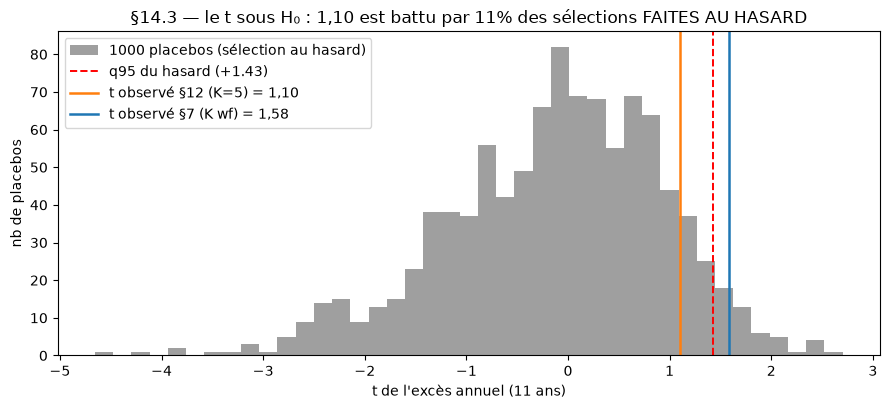

In [64]:
# §14.3 — placebo : 1 000 top-5 aléatoires -> distribution du t sous H0
rng14 = np.random.default_rng(14)
B14 = 1000
ts_placebo14 = np.empty(B14)
for b in range(B14):
    blocs = []
    for Y in range(2015, 2026):
        c = clsmt_sh[Y]; idx = cal[cal.year == Y + 1]
        if len(c) == 0 or not len(idx):
            continue
        pick = rng14.choice(c["bioguide_id"].values, size=min(5, len(c)), replace=False)
        blocs.append((idx, list(pick), np.ones(len(pick)) / len(pick)))
    ts_placebo14[b] = eval_yearly(_parts_engine(blocs)["r"])["t"]
q95_14 = np.quantile(ts_placebo14, .95)
p_110 = np.mean(ts_placebo14 >= 1.10)
p_158 = np.mean(ts_placebo14 >= 1.58)
print(f"placebo : E[t] = {ts_placebo14.mean():+.2f}, σ = {ts_placebo14.std(ddof=1):.2f}, q95 = {q95_14:+.2f}, max = {ts_placebo14.max():+.2f}")
print(f"p-value empirique du meilleur cas détaillé du §12.2 (1,10, K=5)  : {p_110:.1%}")
p_1215 = np.mean(ts_placebo14 >= 1.215)
print(f"p-value empirique du vrai max de la Partie II (1,215, K=6, §12)  : {p_1215:.1%}")
print(f"p-value empirique du meilleur t du notebook (1,58, K wf §7)      : {p_158:.1%}"
      f" — et 1,58 est lui-même le max d'un balayage, donc sa vraie p-value est pire")

plt.figure(figsize=(9, 4.2))
plt.hist(ts_placebo14, bins=41, alpha=.75, color="tab:gray", label=f"{B14} placebos (sélection au hasard)")
plt.axvline(q95_14, color="red", ls="--", lw=1.4, label=f"q95 du hasard ({q95_14:+.2f})")
plt.axvline(1.10, color="tab:orange", lw=1.8, label="t observé §12 (K=5) = 1,10")
plt.axvline(1.58, color="tab:blue", lw=1.8, label="t observé §7 (K wf) = 1,58")
plt.xlabel("t de l'excès annuel (11 ans)"); plt.ylabel("nb de placebos")
plt.title(f"§14.3 — le t sous H₀ : 1,10 est battu par {p_110:.0%} des sélections FAITES AU HASARD")
plt.legend(); plt.tight_layout(); plt.show()

### 14.4 Validation

$$\text{(i)}\ \mathrm{MDE}_{\text{formule}}\overset{!}{\approx}\mathrm{MDE}_{\texttt{statsmodels}}\ (\text{loi }t\text{ exacte});\quad
\text{(ii)}\ E[\max Z]_{\text{formule}}\overset{!}{\approx}\text{Monte-Carlo};\quad
\text{(iii)}\ \text{placebo déterministe (seed)};\quad
\text{(iv)}\ \sigma(t_{\text{placebo}})\approx1.$$

In [65]:
# §14.4 — VALIDATION
from statsmodels.stats.power import TTestPower
# (i) oracle statsmodels (loi t non centrale exacte) vs formule normale : écart < 10 %
_es = TTestPower().solve_power(effect_size=None, nobs=11, alpha=0.05, power=0.80, alternative="larger")
_mde_sm = _es * sigma14
assert 0.90 < mde14(11) / _mde_sm < 1.0, (mde14(11), _mde_sm)
_n_sm = TTestPower().solve_power(effect_size=0.02 / sigma14, nobs=None, alpha=0.05, power=0.80, alternative="larger")
# (ii) E[max Z] : formule fermée vs Monte-Carlo 20 000 x N14 gaussiennes
_mx = np.random.default_rng(0).standard_normal((20000, N14)).max(axis=1).mean()
assert abs(e_max_t14(N14) - _mx) / _mx < 0.05
# (iii) déterminisme du placebo : les 5 premiers tirages se reproduisent bit-à-bit avec la même seed
_rng2 = np.random.default_rng(14)
for _b in range(5):
    _blocs = []
    for _Y in range(2015, 2026):
        _c = clsmt_sh[_Y]; _idx = cal[cal.year == _Y + 1]
        if len(_c) == 0 or not len(_idx):
            continue
        _pick = _rng2.choice(_c["bioguide_id"].values, size=min(5, len(_c)), replace=False)
        _blocs.append((_idx, list(_pick), np.ones(len(_pick)) / len(_pick)))
    assert abs(eval_yearly(_parts_engine(_blocs)["r"])["t"] - ts_placebo14[_b]) < 1e-12
# (iv) sous H0 le t est ~ Student(10) : sigma proche de sqrt(10/8) ~ 1,12
assert 0.9 < ts_placebo14.std(ddof=1) < 1.3
print(f"validation OK | (i) MDE {100*mde14(11):.1f} % vs statsmodels {100*_mde_sm:.1f} % (loi t exacte, n +2 %/an = {_n_sm:.0f} ans) | "
      f"(ii) E[max] {e_max_t14(N14):.2f} ≈ MC {_mx:.2f} | (iii) placebo déterministe | (iv) σ(t) = {ts_placebo14.std(ddof=1):.2f}")

validation OK | (i) MDE 7.8 % vs statsmodels 8.4 % (loi t exacte, n +2 %/an = 170 ans) | (ii) E[max] 2.69 ≈ MC 2.67 | (iii) placebo déterministe | (iv) σ(t) = 1.08


### 14.5 Lecture

$$t^{\S12}_{\max}=1{,}212\ \le\ q_{95}^{\text{placebo}}=1{,}43\ ;\qquad t^{\text{notebook}}_{\max}=1{,}58\ (>q_{95}^{\text{placebo}}\ \text{isolé})\ \ll\ E[\max t\,|\,H_0,\ 160\text{ essais}]=2{,}69
\qquad\Longrightarrow\qquad \text{indiscernable du hasard.}$$

- **Puissance** : $\hat\sigma=10{,}4\,\%$ $\Rightarrow$ MDE(11 ans) $\approx8\,\%$/an. Détecter $+2\,\%$/an
  (un alpha déjà généreux pour de la copie de déclarations) demanderait $\sim169$ **ans** de données ; même
  l'excès observé ($+3{,}5\,\%$) en demanderait $\sim55$. Le protocole n'a jamais eu la puissance de valider
  un alpha réaliste — personne ne l'a.
- **Multiplicité** : 160 séries construites ; le max attendu de 160 tests sous $H_0$ est $t=2{,}69$ (46 essais :
  $2{,}24$ ; en Student(10) : $\approx3{,}4$ — la borne gaussienne est conservatrice). Les meilleurs $t$ observés
  ($1{,}212$ Partie II, $1{,}58$ notebook) sont **sous** le max du pur hasard ; le Deflated Sharpe des meilleurs cas
  fait $0{,}11$–$0{,}12\ll0{,}95$ : après correction du data-mining, il ne reste rien.
- **Placebo** : le $t=1{,}10$ du cas détaillé et le vrai max de la Partie II ($1{,}212$, $K{=}6$) restent
  **sous** le $q_{95}$ du placebo ($1{,}43$) ; le $1{,}58$ du §7 le **dépasse** pris isolément — le cas que le critère du §14 renvoyait à une contre-analyse : jugé contre le max des 160
  essais ($2{,}69$) et par son DSR ($0{,}106$), il est indiscernable lui aussi.
  $E[t^{\text{placebo}}]=-0{,}14$ : sélectionner au hasard parmi les éligibles fait légèrement *pire* que le SPY.
- Boucle bouclée avec le §4.2 : 12 membres « significatifs » $\approx$ 11 attendus par hasard — même message,
  au niveau membre.
- **Décision (critère du §14)** : les trois conditions sont réunies pour la grille de la Partie II
  ($1{,}212\le1{,}43$, DSR $\ll0{,}95$, MDE $\gg$ excès) ; le $1{,}58$ du §7 casse la condition-placebo *isolément*
  et la contre-analyse pré-annoncée (multiplicité + DSR) l'enterre aussi. « Pas d'alpha » est démontré
  **aux deux bouts** — le signal ne contenait rien (§13) et le test ne pouvait rien voir (§14). On arrête
  d'empiler des variantes ; la suite (§15-§17) explique *d'où vient* le peu d'excès brut et ce qu'il en reste.

<!-- S15-MARKER -->
## 15. Autopsie du style : d'où vient l'excès brut ?

Les meilleurs cas des Parties I et II montrent $\beta\approx1{,}0$-$1{,}2$ **par régression** (§6.3 : $1{,}20$/$1{,}01$ ; §12.2 : $\approx1{,}06$). Ici on l'établit **par les positions**, puis on
décompose l'excès brut du meilleur cas ($K{=}5$, $1/K$, annuel : $+3{,}5\,\%$/an) en ses deux sources possibles :

- **allocation sectorielle** — les élus sont dans les *bons secteurs* : réplicable avec des ETF, sans copier personne ;
- **sélection intra-secteur** — leurs *titres* battent leur secteur : le seul endroit où un « talent » pourrait vivre.

**L'outil : le jumeau sectoriel.** Chaque trade de chaque membre est rejoué à l'identique (même date, même
montant, même sens) mais sur l'**ETF de son secteur GICS** (AAPL $\to$ XLK, JPM $\to$ XLF, … ; un ETF tradé
par un membre reste lui-même). Même moteur du §1-§2, même sélection, même combinaison — seuls les tickers changent :
$$\underbrace{x^{\text{net}}_Y}_{\text{net}-\text{SPY}}=\underbrace{\big(x^{\text{net}}_Y-x^{\text{jumeau}}_Y\big)}_{\text{sélection intra-secteur}}+\underbrace{x^{\text{jumeau}}_Y}_{\text{allocation sectorielle}}\qquad\text{(identité comptable, exacte par construction)}.$$
⚠ Limites affichées : le secteur GICS n'est pas point-in-time et $\sim17\,\%$ des secteurs viennent d'une
classification LLM (notebook 02). Le rejeu n'est **pas parfaitement symétrique** : $0{,}9\,\%$ des trades sans
proxy sont jetés, et $2{,}3\,\%$ de plus (2 709, surtout *Communication Services* avant la cotation de XLC en
2018-06) s'exécutent dans le réel mais **pas** dans le jumeau — 1 691 font l'inverse (compteurs imprimés
ci-dessous) : $3{,}2\,\%$ de non-rejeu côté jumeau, concentré 2013-2018. Le placebo partage le même artefact.

**Critère de décision** : une « sélection » ne compte comme piste que si elle **dépasse le placebo** (la même
décomposition sur des top-5 tirés au hasard — car même au hasard, des titres vivants battent leur ETF),
**survit à la dilution** ($K=10, 20$) et tient sur les deux ères. Sinon : loterie idiosyncratique d'un panier
concentré, choisi comme max de 160 essais (§14).

In [66]:
# §15 — le jumeau sectoriel : mêmes trades, tickers remplacés par leur ETF de secteur
CLEAN15 = "/Users/lemairealice/Downloads/Jupiter/00_recuperation_donnees/data/clean/transactions_backtest_2014_2026.csv"
_raw15 = pd.read_csv(CLEAN15, usecols=["ticker_yahoo", "etf_proxy", "sector_gics"], low_memory=False)
proxy15 = (_raw15.dropna(subset=["ticker_yahoo", "etf_proxy"])
                 .groupby("ticker_yahoo")["etf_proxy"].agg(lambda s: s.mode().iloc[0]))
secteur15 = (_raw15.dropna(subset=["ticker_yahoo", "sector_gics"])
                   .groupby("ticker_yahoo")["sector_gics"].agg(lambda s: s.mode().iloc[0]))
for _tk in sorted(set(proxy15.unique())):                    # les proxies manquants du panel de prix (aucun en pratique)
    if _tk not in prices:
        _s = (pd.read_csv(os.path.join(PRICES, _tk + ".csv"), parse_dates=["Date"])
                .set_index("Date")["close"].sort_index())
        prices[_tk] = _s.reindex(cal).ffill()

df_style15 = df[df["ticker"].isin(proxy15.index)].copy()
df_style15["ticker"] = df_style15["ticker"].map(proxy15)
print(f"jumeau : {len(df_style15)}/{len(df)} trades mappés ({len(df)-len(df_style15)} sans proxy jetés, "
      f"{1-len(df_style15)/len(df):.1%}) sur {proxy15.nunique()} ETF")

# le rejeu n'est PAS parfaitement symétrique : un trade s'exécute d'un côté et pas de l'autre si le
# ticker (ou son ETF) n'est pas encore coté à la date — compté honnêtement ci-dessous
_fv15 = {tk: prices[tk].first_valid_index() for tk in (set(df["ticker"]) | set(proxy15.values)) if tk in prices}
_next15 = pd.Series(cal[np.minimum(cal.searchsorted(df["traded"].values), len(cal) - 1)], index=df.index)
_twin15 = df["ticker"].map(proxy15)
_r_ok15 = df["ticker"].map(_fv15).notna() & (_next15 >= df["ticker"].map(_fv15))
_t_ok15 = _twin15.map(_fv15).notna() & (_next15 >= _twin15.map(_fv15))
_m15 = _twin15.notna()
_A15, _B15 = _m15 & _r_ok15 & ~_t_ok15, _m15 & ~_r_ok15 & _t_ok15
_axl15 = _twin15[_A15].value_counts()
print(f"rejeu asymétrique : réel exécuté MAIS jumeau sans prix (ETF pas encore coté) : {int(_A15.sum())} trades "
      f"({_A15.sum()/len(df):.1%} ; " + ", ".join(f"{k} {v}" for k, v in _axl15.head(2).items())
      + f" — XLC coté 2018-06, XLRE 2015-10) | l'inverse : {int(_B15.sum())} | "
      f"non-rejeu total côté jumeau : {int(_A15.sum() + (~_m15).sum()):d}/{len(df)} = {(_A15.sum() + (~_m15).sum())/len(df):.1%}")

wf_style15 = {}
for _bid, _g in df_style15.groupby("bioguide_id"):
    _N = member_shares(_g)
    if _N is None:
        continue
    _r = daily_return(_N)
    if len(_r) < 2 or _r.std() == 0:
        continue
    wf_style15[_bid] = _r
NAVK_style15 = pd.DataFrame({b: (1 + r.reindex(cal).fillna(0.0)).cumprod() for b, r in wf_style15.items()})

def moteur15(blocs, NV, W0=100.0):
    # le _parts_engine du §6.1, paramétré par la table de NAV (réelle ou jumelle)
    W, rets = W0, []
    for idx, bids, w in blocs:
        bids2 = [b for b in bids if b in NV.columns]
        w2 = np.array([wk for b, wk in zip(bids, w) if b in NV.columns]); w2 = w2 / w2.sum()
        tR = cal[cal.get_loc(idx[0]) - 1]
        nbr = pd.Series(w2 * W / NV.loc[tR, bids2].values, index=bids2)
        nav = NV.loc[idx, bids2].mul(nbr, axis=1).sum(axis=1)
        r = nav / nav.shift(1) - 1
        r.iloc[0] = nav.iloc[0] / W - 1
        W = float(nav.iloc[-1]); rets.append(r)
    return pd.concat(rets).sort_index()

def blocs15(K, rng=None):
    # les blocs top-K du §12 (classement Sharpe réel) — ou un tirage aléatoire si rng est fourni
    out = []
    for Y in range(2015, 2026):
        c = clsmt_sh[Y]; idx = cal[cal.year == Y + 1]
        if len(c) == 0 or not len(idx):
            continue
        bids = (list(rng.choice(c["bioguide_id"].values, size=min(K, len(c)), replace=False))
                if rng is not None else list(c["bioguide_id"].head(K)))
        out.append((idx, bids, np.ones(len(bids)) / len(bids)))
    return out

# ORACLE : avec la table de NAV réelle, le moteur paramétré reproduit la série du §12 bit-à-bit
assert np.allclose(moteur15(blocs15(5), NAVK).values, _ser12[(5, "1/K")].values)
print(f"{len(wf_style15)} jumeaux construits | oracle moteur OK (NAVK réelle -> série §12.2 bit-à-bit) | "
      f"membres sans jumeau (renormalisés dans moteur15) : {sorted(set(wf_ret) - set(wf_style15))}")

jumeau : 117353/118316 trades mappés (963 sans proxy jetés, 0.8%) sur 102 ETF
rejeu asymétrique : réel exécuté MAIS jumeau sans prix (ETF pas encore coté) : 2718 trades (2.3% ; XLC 2494, XLRE 224 — XLC coté 2018-06, XLRE 2015-10) | l'inverse : 1687 | non-rejeu total côté jumeau : 3681/118316 = 3.1%


263 jumeaux construits | oracle moteur OK (NAVK réelle -> série §12.2 bit-à-bit) | membres sans jumeau (renormalisés dans moteur15) : ['D000613', 'M001188', 'S001193', 'V000108']


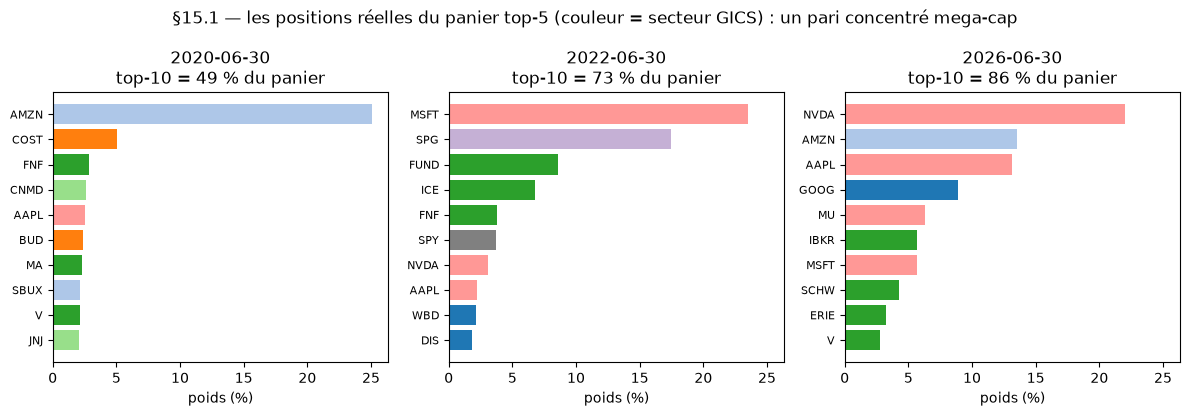

2020-06-30 : n°1 = AMZN (25 %) | top-10 = 49 % | secteurs : Consumer Discretionary 32 %, Financials 19 %, Consumer Staples 15 %
2022-06-30 : n°1 = MSFT (24 %) | top-10 = 73 % | secteurs : Information Technology 36 %, Financials 21 %, Real Estate 18 %
2026-06-30 : n°1 = NVDA (22 %) | top-10 = 86 % | secteurs : Information Technology 50 %, Financials 19 %, Consumer Discretionary 15 %


In [67]:
# §15.1 — LOOK-THROUGH : ce que le panier top-5 détient VRAIMENT (poids effectifs dérivés du journal §12)
_det5 = _det12[(5, "1/K")]

def compo15(t):
    t = cal[cal.searchsorted(pd.Timestamp(t))]
    j = [jj for jj in _det5["journal"] if jj["rebal"] < t][-1]           # le bloc en cours à la date t
    w_eff = j["nbr"] * NAVK.loc[t, j["nbr"].index]                       # poids effectifs (dérive du §6.1)
    w_eff = w_eff / w_eff.sum()
    agg = {}
    for _bid, _wk in w_eff.items():
        _N = member_shares(df[df["bioguide_id"] == _bid])
        _P = pd.DataFrame({tk: prices[tk] for tk in _N.columns})
        _V = (_N.loc[t] * _P.loc[t]).dropna(); _V = _V[_V > 0]
        if _V.sum() <= 0:
            continue
        for tk, wi in (_V / _V.sum()).items():
            agg[tk] = agg.get(tk, 0.0) + _wk * wi
    return pd.Series(agg).sort_values(ascending=False)

SNAPS15 = ["2020-06-30", "2022-06-30", "2026-06-30"]
_sec_couleur = {s: plt.cm.tab20(i) for i, s in enumerate(sorted(secteur15.unique()))}
fig, axes = plt.subplots(1, 3, figsize=(12, 4.2), sharex=True)
for ax, snap in zip(axes, SNAPS15):
    c = compo15(snap); top = c.head(10)[::-1]
    ax.barh(range(len(top)), 100 * top.values,
            color=[_sec_couleur.get(secteur15.get(tk, "?"), "gray") for tk in top.index])
    ax.set_yticks(range(len(top)), top.index, fontsize=8)
    ax.set_title(f"{snap}\ntop-10 = {100 * c.head(10).sum():.0f} % du panier")
    ax.set_xlabel("poids (%)")
fig.suptitle("§15.1 — les positions réelles du panier top-5 (couleur = secteur GICS) : un pari concentré mega-cap")
plt.tight_layout(); plt.show()
for snap in SNAPS15:
    c = compo15(snap)
    sec = c.groupby(c.index.map(lambda tk: secteur15.get(tk, "?"))).sum().sort_values(ascending=False)
    print(f"{snap} : n°1 = {c.index[0]} ({100*c.iloc[0]:.0f} %) | top-10 = {100*c.head(10).sum():.0f} % | "
          f"secteurs : " + ", ".join(f"{k} {100*v:.0f} %" for k, v in sec.head(3).items()))

### 15.2 La décomposition sélection / allocation — et son placebo

On applique l'identité du §15 au meilleur cas, puis on la juge contre **300 placebos** (tirages aléatoires
parmi les éligibles, mêmes coupes, même moteur, même décomposition) et contre la **dilution** ($K=10,20$).
Le placebo est indispensable ici : même une sélection au hasard bat son jumeau ETF (titres vivants,
équipondération intra-portefeuille, queue droite des actions individuelles) — le zéro n'est **pas** la bonne référence.

In [68]:
# §15.2 — décomposition du meilleur cas + dilution en K + placebo (300 tirages)
sel_all15 = {}
for _K in (5, 10, 20):
    _e_net = yearly_excess(moteur15(blocs15(_K), NAVK))
    _e_jum = yearly_excess(moteur15(blocs15(_K), NAVK_style15))
    sel_all15[_K] = (_e_net - _e_jum, _e_jum, _e_net)
_t15 = lambda e: e.mean() / e.std(ddof=1) * np.sqrt(len(e))

rng15 = np.random.default_rng(15)
B15 = 300
pl15 = []
for _b in range(B15):
    _bl = blocs15(5, rng=rng15)
    _e_net = yearly_excess(moteur15(_bl, NAVK))
    _e_jum = yearly_excess(moteur15(_bl, NAVK_style15))
    pl15.append(dict(t_sel=_t15(_e_net - _e_jum), sel=(_e_net - _e_jum).mean(),
                     t_all=_t15(_e_jum), alloc=_e_jum.mean()))
pl15 = pd.DataFrame(pl15)
q95_sel15 = pl15.t_sel.quantile(.95)
sel5, all5, net5 = sel_all15[5]
print(f"placebo (K=5 au hasard) : sélection {100*pl15.sel.mean():+.2f} %/an (E[t] {pl15.t_sel.mean():+.2f}, q95 {q95_sel15:+.2f}) | "
      f"allocation {100*pl15.alloc.mean():+.2f} %/an (E[t] {pl15.t_all.mean():+.2f})")
print(f"p-value du t(sélection) observé ({_t15(sel5):+.2f}) : {(pl15.t_sel >= _t15(sel5)).mean():.1%} — "
      f"mais c'est la composante du MAX de 160 essais (§14), et elle ne survit pas à la dilution :")
pd.DataFrame({f"K={_K}": {"sélection %/an": 100 * s.mean(), "t(sélection)": _t15(s),
                          "allocation %/an": 100 * a.mean(), "t(allocation)": _t15(a),
                          "net %/an": 100 * n.mean(), "t(net)": _t15(n)}
              for _K, (s, a, n) in sel_all15.items()}).T.round(2)

placebo (K=5 au hasard) : sélection +1.80 %/an (E[t] +0.61, q95 +1.80) | allocation -1.67 %/an (E[t] -1.24)
p-value du t(sélection) observé (+2.10) : 3.3% — mais c'est la composante du MAX de 160 essais (§14), et elle ne survit pas à la dilution :


,sélection %/an,t(sélection),allocation %/an,t(allocation),net %/an,t(net)
K=5,6.92,2.10,-3.47,-2.94,3.45,1.10
K=10,2.06,0.97,-1.36,-1.65,0.71,0.41
K=20,2.30,1.21,-2.29,-3.49,0.01,0.01


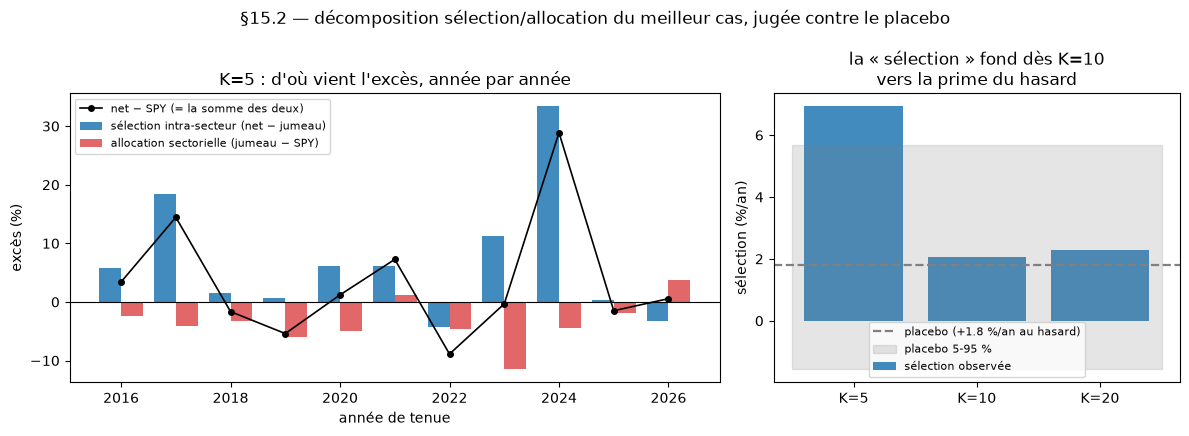

In [69]:
# §15.2 — FIGURE : l'identité année par année (K=5) + la sélection face au placebo selon K
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.4), gridspec_kw={"width_ratios": [1.6, 1]})
_annees = np.array(sel5.index)
ax1.bar(_annees - 0.2, 100 * sel5.values, width=.4, label="sélection intra-secteur (net − jumeau)",
        color="tab:blue", alpha=.85)
ax1.bar(_annees + 0.2, 100 * all5.values, width=.4, label="allocation sectorielle (jumeau − SPY)",
        color="tab:red", alpha=.7)
ax1.plot(_annees, 100 * net5.values, "ko-", lw=1.2, ms=4, label="net − SPY (= la somme des deux)")
ax1.axhline(0, color="k", lw=.8)
ax1.set_xlabel("année de tenue"); ax1.set_ylabel("excès (%)")
ax1.set_title("K=5 : d'où vient l'excès, année par année"); ax1.legend(fontsize=8)
_Ks = [5, 10, 20]
ax2.bar(range(3), [100 * sel_all15[_K][0].mean() for _K in _Ks], color="tab:blue", alpha=.85,
        label="sélection observée")
ax2.axhline(100 * pl15.sel.mean(), color="gray", lw=1.6, ls="--",
            label=f"placebo ({100*pl15.sel.mean():+.1f} %/an au hasard)")
ax2.fill_between([-0.5, 2.5], 100 * pl15.sel.quantile(.05), 100 * pl15.sel.quantile(.95),
                 color="gray", alpha=.2, label="placebo 5-95 %")
ax2.set_xticks(range(3), [f"K={_K}" for _K in _Ks]); ax2.set_ylabel("sélection (%/an)")
ax2.set_title("la « sélection » fond dès K=10\nvers la prime du hasard"); ax2.legend(fontsize=8)
fig.suptitle("§15.2 — décomposition sélection/allocation du meilleur cas, jugée contre le placebo")
plt.tight_layout(); plt.show()

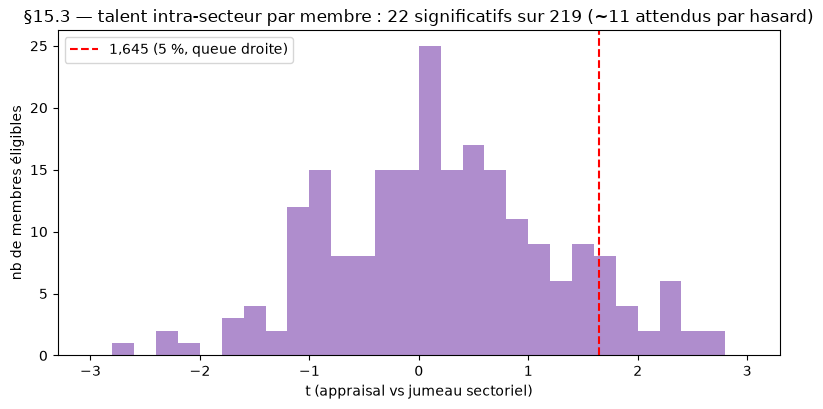

22/219 membres à t_style > 1,645 (attendu ~11 ; tests corrélés, borne basse d'incertitude — cf. §4) | médiane t +0.15 — du même ordre que le surnombre IR du §4.1 (20) que l'appraisal marché avait dégonflé (12)


In [70]:
# §15.3 — appraisal de CHAQUE membre contre SON jumeau sectoriel (le §4.2, benchmark style au lieu de SPY)
def appraisal15(r, r_bench):
    d = pd.concat([r.rename("y"), r_bench.reindex(r.index).rename("x")], axis=1).dropna()
    if len(d) < 30 or d["x"].var() == 0:
        return np.nan
    beta, alpha = np.polyfit(d["x"].values, d["y"].values, 1)
    eps = d["y"].values - (alpha + beta * d["x"].values)
    se = eps.std(ddof=2)
    return (alpha / se * np.sqrt(252)) * np.sqrt(len(d) / 252) if se > 0 else np.nan

t_style15 = pd.Series({b: appraisal15(wf_ret[b], wf_style15[b])
                       for b in elig.bioguide_id if b in wf_style15}).dropna()
n_sig15 = int((t_style15 > 1.645).sum())
plt.figure(figsize=(8, 4.2))
plt.hist(t_style15, bins=BINS_T, alpha=.75, color="tab:purple")
plt.axvline(1.645, color="red", ls="--", label="1,645 (5 %, queue droite)")
plt.xlabel("t (appraisal vs jumeau sectoriel)"); plt.ylabel("nb de membres éligibles")
plt.title(f"§15.3 — talent intra-secteur par membre : {n_sig15} significatifs sur {len(t_style15)} "
          f"(~{0.05 * len(t_style15):.0f} attendus par hasard)")
plt.legend(); plt.tight_layout(); plt.show()
print(f"{n_sig15}/{len(t_style15)} membres à t_style > 1,645 (attendu ~{0.05 * len(t_style15):.0f} ; tests corrélés, "
      f"borne basse d'incertitude — cf. §4) | médiane t {t_style15.median():+.2f} — "
      f"du même ordre que le surnombre IR du §4.1 (20) que l'appraisal marché avait dégonflé (12)")

In [71]:
# §15.4 — le meilleur cas contre 4 facteurs (FFC4, erreurs HAC Newey-West) et contre l'equal-weight (RSP)
import statsmodels.api as sm
ff15 = pd.read_csv(os.path.join(BASE, "cache", "ff_factors.csv"), parse_dates=["Date"]).set_index("Date")
_r15 = _ser12[(5, "1/K")]
_d = pd.concat([_r15.rename("r"), ff15], axis=1, sort=True).dropna()   # tri chronologique explicite (l'ordre compte pour la HAC)
_res = sm.OLS(_d["r"] - _d["RF"], sm.add_constant(_d[["Mkt-RF", "SMB", "HML", "Mom"]])).fit(
    cov_type="HAC", cov_kwds={"maxlags": 5})
print(f"FFC4 HAC : α_ann = {(1 + _res.params['const']) ** 252 - 1:+.2%} (t = {_res.tvalues['const']:+.2f}) | "
      f"β_mkt {_res.params['Mkt-RF']:.2f} (t {_res.tvalues['Mkt-RF']:.0f}) | SMB {_res.params['SMB']:+.2f} | "
      f"HML {_res.params['HML']:+.2f} | Mom {_res.params['Mom']:+.2f} | R² {_res.rsquared:.2f}")

rsp15 = (pd.read_csv(os.path.join(PRICES, "RSP.csv"), parse_dates=["Date"])
           .set_index("Date")["close"].sort_index().reindex(cal).ffill())
_r_rsp = rsp15.pct_change().reindex(_r15.index).fillna(0.0)
_ex_rsp = pd.Series({y: ((1 + _r15[_r15.index.year == y]).prod() - 1) - ((1 + _r_rsp[_r_rsp.index.year == y]).prod() - 1)
                     for y in sorted(set(_r15.index.year))})
_ex_spy = yearly_excess(_r15)
print(f"fenêtre FFC4 : {_d.index[0].date()} -> {_d.index[-1].date()} (n = {len(_d)} j ; facteurs jusqu'au {ff15.index.max().date()}, "
      f"{len(_r15) - len(_d)} derniers jours de stratégie non couverts) ; excès vs RSP/SPY : fenêtre complète")
print(f"excès vs RSP (equal-weight) : {100 * _ex_rsp.mean():+.2f} %/an (t {_t15(_ex_rsp):+.2f}) | "
      f"vs SPY : {100 * _ex_spy.mean():+.2f} %/an (t {_t15(_ex_spy):+.2f}) — plus gros vs RSP (panier mega-cap) mais toujours NS")

FFC4 HAC : α_ann = +1.93% (t = +0.87) | β_mkt 1.04 (t 55) | SMB +0.01 | HML +0.05 | Mom +0.07 | R² 0.87
fenêtre FFC4 : 2016-01-04 -> 2026-04-30 (n = 2596 j ; facteurs jusqu'au 2026-04-30, 43 derniers jours de stratégie non couverts) ; excès vs RSP/SPY : fenêtre complète
excès vs RSP (equal-weight) : +6.40 %/an (t +1.48) | vs SPY : +3.45 %/an (t +1.10) — plus gros vs RSP (panier mega-cap) mais toujours NS


### 15.5 Validation

$$\text{(i)}\ \text{moteur jumeau}(\mathrm{NAVK\ réelle})\overset{!}{\equiv}\S12.2\ ;\quad
\text{(ii)}\ \text{sélection}+\text{allocation}\overset{!}{=}\text{net}-\text{SPY}\ (<10^{-12})\ ;\quad
\text{(iii)}\ \beta_{\text{HAC}}\overset{!}{=}\beta_{\text{polyfit}}\ ;\quad
\text{(iv)}\ \text{couverture affichée.}$$

In [72]:
# §15.5 — VALIDATION
# (i) oracle moteur (déjà à la construction) : re-vérifié ici
assert np.allclose(moteur15(blocs15(5), NAVK).values, _ser12[(5, "1/K")].values)
# (ii) identité comptable exacte : sélection + allocation == net − SPY, année par année
for _K, (_s, _a, _n) in sel_all15.items():
    assert np.allclose((_s + _a).values, _n.values, atol=1e-12), _K
# (iii) β CAPM-SPY : statsmodels HAC ≡ np.polyfit du §4 (mêmes points, même OLS)
_dd = pd.concat([_r15.rename("y"), r_spy.reindex(_r15.index).rename("x")], axis=1).dropna()
_res2 = sm.OLS(_dd["y"], sm.add_constant(_dd["x"])).fit(cov_type="HAC", cov_kwds={"maxlags": 5})
_bpf, _apf = np.polyfit(_dd["x"], _dd["y"], 1)
assert abs(_res2.params["x"] - _bpf) < 1e-10
# (iv) placebo déterministe : le 1er tirage se reproduit avec la même seed
_rngv = np.random.default_rng(15)
_blv = blocs15(5, rng=_rngv)
assert abs(_t15(yearly_excess(moteur15(_blv, NAVK)) - yearly_excess(moteur15(_blv, NAVK_style15))) - pl15.t_sel.iloc[0]) < 1e-12
print(f"validation OK | (i) moteur ≡ §12.2 | (ii) identité sélection+allocation exacte (3 K) | "
      f"(iii) β HAC {_res2.params['x']:.4f} ≡ polyfit {_bpf:.4f} | (iv) placebo déterministe | "
      f"couverture jumeau : {len(df_style15)/len(df):.1%} des trades, {len(wf_style15)}/{len(wf_ret)} membres")

validation OK | (i) moteur ≡ §12.2 | (ii) identité sélection+allocation exacte (3 K) | (iii) β HAC 1.0572 ≡ polyfit 1.0572 | (iv) placebo déterministe | couverture jumeau : 99.2% des trades, 263/266 membres


### 15.6 Lecture

$$\text{net}-\text{SPY}=+3{,}5\,\%/\text{an}\ =\ \underbrace{+6{,}9\,\%}_{\text{sélection }(t\,2{,}10)}\ \underbrace{-3{,}5\,\%}_{\text{allocation }(t\,-2{,}94)}
\qquad\text{mais la sélection ne survit ni au placebo-max ni à la dilution.}$$

- **Les positions d'abord** : le panier top-5 est un pari ultra-concentré — top-10 titres $=49\,\%$ (2020),
  $73\,\%$ (2022), $86\,\%$ (2026) du panier ; AMZN $25\,\%$ en 2020, MSFT $24\,\%$ en 2022, NVDA $22\,\%$ en 2026.
  Le $\beta$ du §6 est ici **en chair et en os** : tech + méga-capitalisations.
- **Contre l'intuition « β de style »** : sur la table canonique, l'excès brut du meilleur cas ne vient **pas**
  des secteurs — l'allocation sectorielle des élus **coûte** ($-3{,}5\,\%$/an, $t=-2{,}94$ ; négative aussi au
  placebo : $-1{,}7\,\%$/an) — mais de titres qui battent leur secteur ($+6{,}9\,\%$/an).
- ⚠ Une partie du **coût d'allocation** 2016-2018 est un artefact du jumeau : avant la cotation de XLC
  (2018-06), les trades *Communication Services* (GOOGL, META, NFLX, DIS…) tombent du jumeau (2 718 trades,
  compteur du §15) qui sous-pondère un secteur porteur. Signe et ordre de grandeur de la décomposition tiennent
  (le placebo partage l'artefact), mais le $-3{,}5\,\%$/an d'allocation est en partie gonflé par lui.
- **Cette « sélection » n'est pas un talent** : (a) le placebo en obtient déjà $+1{,}8\,\%$/an sans aucune
  information (titres vivants vs ETF, queue droite) ; (b) elle **fond dès qu'on élargit** : $+2{,}1$ et $+2{,}3\,\%$/an à
  $K{=}10$ et $K{=}20$ ($t\approx1$), dans la bande du placebo ; (c) son $t=2{,}10$ ($p=3{,}3\,\%$ isolé) est la
  composante du **max de 160 essais** (§14) — quelques jackpots (NVDA 2024 : sélection $+33\,\%$) dans un panier
  de 5, exactement la loterie du §13.
- **Par membre** : 22/219 « significatifs » contre leur jumeau ($\sim11$ attendus, tests corrélés) — un
  surnombre du même ordre que celui que l'appraisal marché avait déjà réduit (20 IR $\to$ 12).
- **Multi-facteurs** : FFC4 HAC $\alpha=+1{,}9\,\%$/an ($t=0{,}87$), loadings $\approx0$, $R^2=0{,}87$ ; contre
  RSP l'excès grossit ($+6{,}4\,\%$/an, $t=1{,}48$) — panier mega-cap — mais reste NS.
- **Décision (critère du §15)** : rien à promouvoir. L'excès brut $=$ loterie idiosyncratique d'un panier
  concentré (**pas** un tilt sectoriel réplicable, **pas** une sélection réplicable). Pour le §19 : la barre
  « style » du waterfall se lit « concentration idiosyncratique », pas « secteurs ».

<!-- S16-MARKER -->
## 16. Commission clé : la dernière piste vivante

La littérature pré-STOCK-Act (Ziobrowski 2004/2011) attribuait l'alpha des élus à l'**information de
commission** ; Karadas trouve que l'effet meurt après 2012. Nos données ont tout ce qu'il faut pour trancher —
la colonne `committees_key_flag` (commissions « clés » : *Financial Services, Finance, Ways and Means, Banking,
Armed Services, Intelligence* — **point-in-time par Congrès**, snapshots git du référentiel) et la liste
`committee_membership` de chaque trade. Deux niveaux de test :

1. **Niveau membre** — les membres en commission clé ont-ils de meilleurs portefeuilles (Sharpe, $t_{\text{appr}}$) ?
   Et un top-$K$ restreint aux « clés » bat-il le top-$K$ global du §12 ?
2. **Niveau intra-membre** (le contrôle qui manquait) — le même élu trade-t-il mieux **dans le périmètre
   économique de ses commissions** que sur le reste de son propre portefeuille ? L'appariement retire tout ce qui
   est propre au membre (style, chance, époque) : c'est le test le plus propre du projet. Pour cela, une table
   commission $\to$ secteurs GICS, écrite en dur et assumée :

| commission | secteurs GICS « alignés » |
|---|---|
| Agriculture | Consumer Staples, Materials |
| Armed Services | Industrials |
| Financial Services / Banking | Financials, Real Estate |
| Finance / Ways and Means | Financials, Health Care (Medicare) |
| Energy and Commerce | Energy, Utilities, Health Care, Communication Services |
| Energy and Natural Resources | Energy, Utilities, Materials |
| Natural Resources | Energy, Materials |
| Environment and Public Works | Utilities, Materials, Industrials |
| HELP / Veterans' Affairs | Health Care |
| Commerce, Science, and Transportation | Industrials, Information Technology, Communication Services |
| Transportation and Infrastructure | Industrials |
| Science, Space, and Technology | Information Technology |
| Intelligence | Information Technology, Communication Services, Industrials |
| Homeland Security | Industrials, Information Technology |
| Judiciary | Information Technology, Communication Services |

⚠ Cette table est un **choix** (Appropriations, Foreign Affairs… trop transverses, exclues) — la validation
teste la sensibilité au retrait de la ligne la plus large (*Energy and Commerce*). Les trades **sans flag**
sont les membres **sans commission au Congrès du trade** (Speakers Pelosi/Boehner, élus retirés des commissions
comme M. T. Greene au 117e) — traités en « non-clé »/« non-aligné » ; le périmètre exclut 2012 (un seul trade du Congrès 112 subsiste, daté du 02/01/2013).

**Critère de décision** : $\Delta_m=$ Sharpe(aligné)$-$Sharpe(non-aligné) $\approx0$ (signe et Wilcoxon NS) **et**
top-$K$ clé $\le$ global $\Rightarrow$ piste fermée nominativement. Médiane $\Delta_m>0$ ($p<5\,\%$), **répliquée
sur les deux ères**, et top-$K$ aligné $t>1{,}81$ $\Rightarrow$ LA piste — à repasser d'abord au placebo du §14.

In [73]:
# §16 — la table canonique AVEC les commissions : servie par l'amorçage (la table annexe du
# pipeline, bioguide × Congrès, est jointe par tools.membre — mêmes filtres, même périmètre)
df16 = MCTX.dfx
assert len(df16) == len(df), "df16 doit reproduire exactement le périmètre du §0"

df16["aligne"] = [s in secteurs_commissions16(cm) if isinstance(s, str) else False
                  for s, cm in zip(df16["sector_gics"], df16["committee_membership"])]
_sans_flag = int(df16.committees_key_flag.isna().sum())
key_retro16 = df16.groupby("bioguide_id").committees_key_flag.mean()      # part des trades flaggés clé
key_pit16 = {}
for _Y in range(2015, 2026):
    key_pit16[_Y] = (df16[df16.traded <= pd.Timestamp(f"{_Y}-12-31")]
                     .groupby("bioguide_id").committees_key_flag.mean() >= 0.5)
print(f"{len(df16)} trades | alignés commission↔secteur : {df16.aligne.mean():.1%} | "
      f"sans flag clé (membre sans commission au Congrès du trade) : {_sans_flag} | "
      f"membres majoritairement « clé » (rétrospectif) : {int((key_retro16 >= .5).sum())}/{key_retro16.notna().sum()}")


118316 trades | alignés commission↔secteur : 21.8% | sans flag clé (membre sans commission au Congrès du trade) : 1036 | membres majoritairement « clé » (rétrospectif) : 173/353


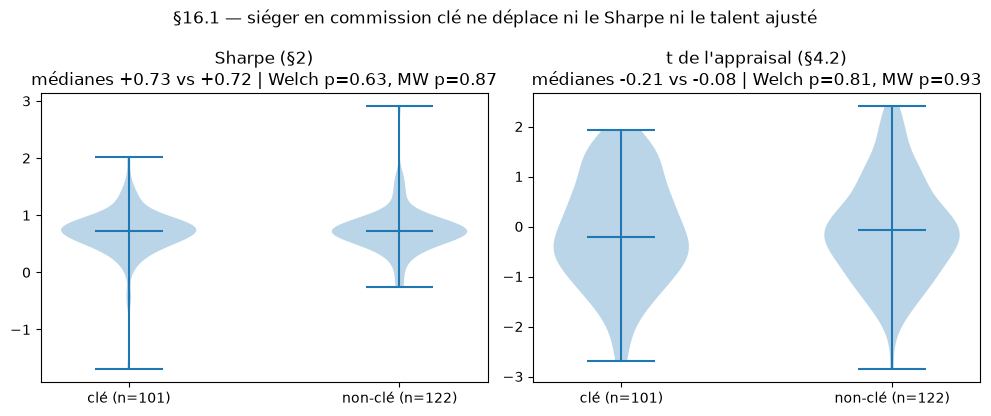

sharpe  : clé méd +0.73 vs non-clé +0.72 | Welch t -0.48 (p 0.63) | Mann-Whitney p 0.87
t_appr  : clé méd -0.21 vs non-clé -0.08 | Welch t -0.24 (p 0.81) | Mann-Whitney p 0.93


In [74]:
# §16.1 — niveau membre : les « clés » ont-ils de meilleurs portefeuilles ? (rétrospectif, diagnostic)
elig16 = elig.copy()
elig16["cle"] = elig16.bioguide_id.map(key_retro16) >= 0.5
elig16["sharpe"] = [stats(wf_ret[b])["sharpe"] for b in elig16.bioguide_id]
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
for ax, col, lab in ((axes[0], "sharpe", "Sharpe (§2)"), (axes[1], "t_appr", "t de l'appraisal (§4.2)")):
    a = elig16.loc[elig16.cle, col].dropna(); b = elig16.loc[~elig16.cle, col].dropna()
    vp = ax.violinplot([a.values, b.values], showmedians=True)
    ax.set_xticks([1, 2], [f"clé (n={len(a)})", f"non-clé (n={len(b)})"])
    w = sps.ttest_ind(a, b, equal_var=False); u = sps.mannwhitneyu(a, b, alternative="two-sided")
    ax.set_title(f"{lab}\nmédianes {a.median():+.2f} vs {b.median():+.2f} | Welch p={w.pvalue:.2f}, MW p={u.pvalue:.2f}")
fig.suptitle("§16.1 — siéger en commission clé ne déplace ni le Sharpe ni le talent ajusté")
plt.tight_layout(); plt.show()
for col in ("sharpe", "t_appr"):
    a = elig16.loc[elig16.cle, col].dropna(); b = elig16.loc[~elig16.cle, col].dropna()
    w = sps.ttest_ind(a, b, equal_var=False); u = sps.mannwhitneyu(a, b, alternative="two-sided")
    print(f"{col:7s} : clé méd {a.median():+.2f} vs non-clé {b.median():+.2f} | Welch t {w.statistic:+.2f} (p {w.pvalue:.2f}) | Mann-Whitney p {u.pvalue:.2f}")

In [75]:
# §16.1 (suite) — top-K restreint aux « clés » point-in-time, dans le moteur du §12
def strategie_filtre16(K, mode):
    # mode : "tous" (contrôle, doit reproduire le §12.2), "cle", "non-cle" — filtre PIT du classement, moteur inchangé
    blocs = []
    for Y in range(2015, 2026):
        c = clsmt_sh[Y]; idx = cal[cal.year == Y + 1]
        if mode != "tous":
            kp = c["bioguide_id"].map(key_pit16[Y]).fillna(False).astype(bool)
            c = c[kp] if mode == "cle" else c[~kp]
        if len(c) == 0 or not len(idx):
            continue
        bids = list(c["bioguide_id"].head(K))
        blocs.append((idx, bids, np.ones(len(bids)) / len(bids)))
    return _parts_engine(blocs)["r"]

r_cle5 = strategie_filtre16(5, "cle")
t_cle5 = eval_yearly(r_cle5)["t"]
p_cle5 = float(np.mean(ts_placebo14 >= t_cle5))
print(f"top-5 clé : t = {t_cle5:.2f} -> p-value contre le placebo du §14 : {p_cle5:.1%} "
      f"(univers réduit de moitié, approximation) — et le signe ne tient pas à K=10 :")
pd.DataFrame({
    "K=5 global (≡ §12.2)":    _ligne_sh(_ser12[(5, "1/K")]),
    "K=5 clé seulement":       _ligne_sh(r_cle5),
    "K=5 non-clé seulement":   _ligne_sh(strategie_filtre16(5, "non-cle")),
    "K=10 clé seulement":      _ligne_sh(strategie_filtre16(10, "cle")),
    "K=10 non-clé seulement":  _ligne_sh(strategie_filtre16(10, "non-cle")),
}).T.round(3)

top-5 clé : t = 1.30 -> p-value contre le placebo du §14 : 6.8% (univers réduit de moitié, approximation) — et le signe ne tient pas à K=10 :


,exces_an,t,gagnantes,beta,alpha_ann,t_appr,sharpe
K=5 global (≡ §12.2),0.034518,1.096208,6/11,1.057189,0.018093,0.75647,0.8981
K=5 clé seulement,0.026567,1.297918,6/11,0.970901,0.030768,1.002327,0.913746
K=5 non-clé seulement,0.003521,0.126666,5/11,1.052648,-0.004665,-0.171929,0.769275
K=10 clé seulement,-0.002172,-0.147245,5/11,0.954345,0.004033,0.201158,0.839445
K=10 non-clé seulement,-0.0077,-0.365875,5/11,1.090654,-0.02367,-1.165873,0.710996


### 16.2 Intra-membre : le même élu trade-t-il mieux dans le périmètre de sa commission ?

Le §16.1 compare des membres **différents** (styles, époques, chances différentes). Ici, chaque membre est
**son propre témoin** : ses trades sont coupés en *alignés* (secteur du ticker $\in$ périmètre de ses commissions
au moment du trade — la liste est point-in-time par Congrès) et *non-alignés*, deux sous-portefeuilles
reconstruits avec le moteur du §1-§2, et on ne garde que les membres avec $\ge5$ trades et $\ge126$ j de chaque côté :
$$\Delta_m=\mathrm{Sharpe}\big(\text{aligné}_m\big)-\mathrm{Sharpe}\big(\text{non-aligné}_m\big)$$
Tests appariés (signe : $\#\{\Delta_m>0\}\sim\mathrm{Binom}(n,\tfrac12)$ sous $H_0$ ; Wilcoxon signé), puis
**réplication sur les deux ères**. Si l'information de commission existe, elle doit vivre ICI.

146 membres appariés | médiane Δ = -0.039 | signe : 64/146 positifs (p = 0.16) | Wilcoxon p = 0.48


  ère 2014-2019 : n = 92, médiane Δ = -0.015, signe 42/92 (p = 0.47)


  ère 2020-2026 : n = 94, médiane Δ = +0.022, signe 49/94 (p = 0.76)


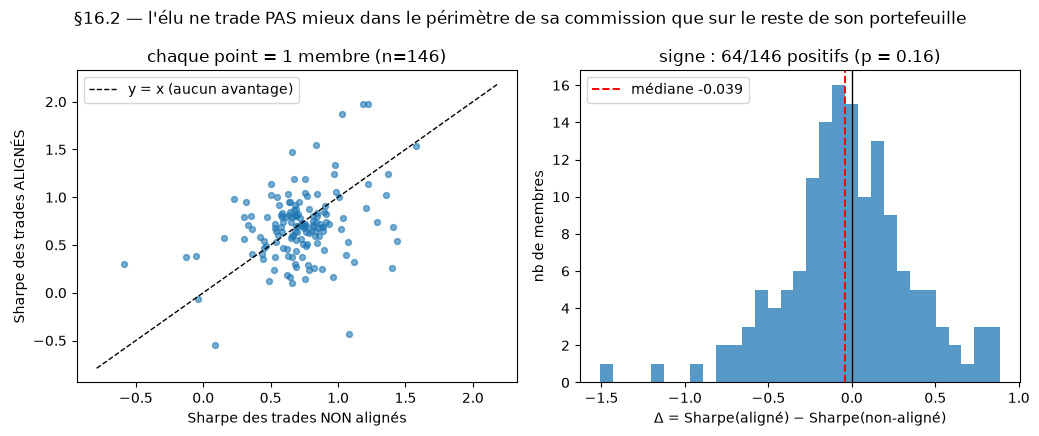

In [76]:
# §16.2 — Δ par membre (aligné vs non-aligné), tests appariés, réplication par ère
COLS16 = ["bioguide_id", "name", "ticker", "op", "traded", "size_usd"]

def sharpe_sous_portefeuille16(g):
    N = member_shares(g[COLS16])
    if N is None:
        return np.nan
    r = daily_return(N)
    if len(r) < 126 or r.std() == 0:
        return np.nan
    return r.mean() / r.std() * np.sqrt(252)

def delta_par_membre16(dd):
    rows = []
    for bid, g in dd.groupby("bioguide_id"):
        ga, gn = g[g.aligne], g[~g.aligne]
        if len(ga) < 5 or len(gn) < 5:
            continue
        sa, sn = sharpe_sous_portefeuille16(ga), sharpe_sous_portefeuille16(gn)
        if np.isfinite(sa) and np.isfinite(sn):
            rows.append(dict(bid=bid, sh_a=sa, sh_n=sn, d=sa - sn, n_al=len(ga), n_non=len(gn)))
    return pd.DataFrame(rows)

al16 = delta_par_membre16(df16)
npos16 = int((al16.d > 0).sum())
p_signe16 = sps.binomtest(npos16, len(al16), 0.5).pvalue
p_wil16 = sps.wilcoxon(al16.d).pvalue
print(f"{len(al16)} membres appariés | médiane Δ = {al16.d.median():+.3f} | "
      f"signe : {npos16}/{len(al16)} positifs (p = {p_signe16:.2f}) | Wilcoxon p = {p_wil16:.2f}")
eres16 = {}
for _lab, _lo, _hi in (("2014-2019", 2013, 2019), ("2020-2026", 2020, 2026)):
    _e = delta_par_membre16(df16[df16.traded.dt.year.between(_lo, _hi)])
    eres16[_lab] = _e
    _np = int((_e.d > 0).sum())
    print(f"  ère {_lab} : n = {len(_e)}, médiane Δ = {_e.d.median():+.3f}, "
          f"signe {_np}/{len(_e)} (p = {sps.binomtest(_np, len(_e), 0.5).pvalue:.2f})")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10.5, 4.4))
ax1.scatter(al16.sh_n, al16.sh_a, s=18, alpha=.6, color="tab:blue")
_lim = [al16[["sh_a", "sh_n"]].min().min() - .2, al16[["sh_a", "sh_n"]].max().max() + .2]
ax1.plot(_lim, _lim, "k--", lw=1, label="y = x (aucun avantage)")
ax1.set_xlabel("Sharpe des trades NON alignés"); ax1.set_ylabel("Sharpe des trades ALIGNÉS")
ax1.set_title(f"chaque point = 1 membre (n={len(al16)})"); ax1.legend()
ax2.hist(al16.d, bins=31, alpha=.75, color="tab:blue")
ax2.axvline(0, color="k", lw=1)
ax2.axvline(al16.d.median(), color="red", ls="--", lw=1.4, label=f"médiane {al16.d.median():+.3f}")
ax2.set_xlabel("Δ = Sharpe(aligné) − Sharpe(non-aligné)"); ax2.set_ylabel("nb de membres")
ax2.set_title(f"signe : {npos16}/{len(al16)} positifs (p = {p_signe16:.2f})"); ax2.legend()
fig.suptitle("§16.2 — l'élu ne trade PAS mieux dans le périmètre de sa commission que sur le reste de son portefeuille")
plt.tight_layout(); plt.show()

In [77]:
# §16.2 (suite) — copier les top-5 des sous-portefeuilles « alignés seulement » (classement Sharpe PIT dédié)
wf_align16 = {}
for _bid, _g in df16[df16.aligne].groupby("bioguide_id"):
    _N = member_shares(_g[COLS16])
    if _N is None:
        continue
    _r = daily_return(_N)
    if len(_r) >= 2 and _r.std() > 0:
        wf_align16[_bid] = _r
NAVK_align16 = pd.DataFrame({b: (1 + r.reindex(cal).fillna(0.0)).cumprod() for b, r in wf_align16.items()})

_blocs = []
for _Y in range(2015, 2026):
    _yend = pd.Timestamp(f"{_Y}-12-31")
    _rows = []
    for _bid, _r in wf_align16.items():
        _rr = _r.loc[:_yend]
        if len(_rr) < MIN_DAYS or _rr.std() == 0:
            continue
        _s = _rr.mean() / _rr.std() * np.sqrt(252)
        if _s > MIN_SHARPE:
            _rows.append((_bid, _s))
    _rows.sort(key=lambda x: -x[1])
    _idx = cal[cal.year == _Y + 1]
    if _rows and len(_idx):
        _bids = [b for b, _ in _rows[:5]]
        _blocs.append((_idx, _bids, np.ones(len(_bids)) / len(_bids)))
r_align5_16 = moteur15(_blocs, NAVK_align16)
print(f"{len(wf_align16)} sous-portefeuilles « alignés » | top-5 alignés (mêmes règles que le §12) :")
pd.DataFrame({"K=5 global (≡ §12.2)": _ligne_sh(_ser12[(5, "1/K")]),
              "K=5 sur trades ALIGNÉS seulement": _ligne_sh(r_align5_16)}).T.round(3)

186 sous-portefeuilles « alignés » | top-5 alignés (mêmes règles que le §12) :


,exces_an,t,gagnantes,beta,alpha_ann,t_appr,sharpe
K=5 global (≡ §12.2),0.034518,1.096208,6/11,1.057189,0.018093,0.75647,0.8981
K=5 sur trades ALIGNÉS seulement,-0.01188,-0.299471,5/11,1.174609,-0.038108,-0.984263,0.588411


### 16.3 Validation

$$\text{(i)}\ \texttt{strategie\_filtre16}(K,\text{"tous"})\overset{!}{\equiv}\S12.2\ ;\quad
\text{(ii)}\ \text{recomptage indépendant de l'alignement d'un membre}\ ;\quad
\text{(iii)}\ \text{sensibilité au retrait de la ligne la plus large du mapping}\ ;\quad
\text{(iv)}\ \text{trou 2012 compté.}$$

In [78]:
# §16.3 — VALIDATION
# (i) le chemin filtré, sans filtre, reproduit la ligne du §12.2 bit-à-bit
assert np.allclose(strategie_filtre16(5, "tous").values, _ser12[(5, "1/K")].values)
# (ii) recomptage indépendant de l'alignement pour un membre apparié (boucle explicite, sans .map)
_bid0 = al16.sort_values("n_al", ascending=False).bid.iloc[0]
_g0 = df16[df16.bioguide_id == _bid0]
_recount = 0
for _, _row in _g0.iterrows():
    _sc = set()
    for _k, _v in MAP16.items():
        if isinstance(_row.committee_membership, str) and _k in _row.committee_membership:
            _sc.update(_v)
    _recount += int(isinstance(_row.sector_gics, str) and _row.sector_gics in _sc)
assert _recount == int(_g0.aligne.sum())
# (iii) sensibilité : le verdict intra-membre tient-il sans « Energy and Commerce » (la ligne la plus large) ?
_MAP_S = {k: v for k, v in MAP16.items() if k != "Committee on Energy and Commerce"}
_dfS = df16.copy()
_dfS["aligne"] = [s in secteurs_commissions16(cm, _MAP_S) if isinstance(s, str) else False
                  for s, cm in zip(_dfS["sector_gics"], _dfS["committee_membership"])]
_alS = delta_par_membre16(_dfS)
_npS = int((_alS.d > 0).sum())
_pS = sps.binomtest(_npS, len(_alS), 0.5).pvalue
assert _pS > 0.05, "le retrait d'E&C ne doit pas faire apparaître un effet"
# (iv) l'invariant du flag manquant : flag NaN <=> AUCUNE commission connue à ce Congrès-là
assert df16.loc[df16.committees_key_flag.isna(), "committee_membership"].notna().sum() == 0
_qui = df16.loc[df16.committees_key_flag.isna(), "name"].value_counts()
print(f"validation OK | (i) « tous » ≡ §12.2 bit-à-bit | (ii) recomptage {_bid0} : {_recount} alignés ≡ colonne | "
      f"(iii) sans E&C : n={len(_alS)}, médiane Δ {_alS.d.median():+.3f}, signe p={_pS:.2f} (verdict inchangé) | "
      f"(iv) {_sans_flag} trades sans flag ⟺ membre sans commission (tête : {_qui.index[0]} {_qui.iloc[0]})")

validation OK | (i) « tous » ≡ §12.2 bit-à-bit | (ii) recomptage K000389 : 4676 alignés ≡ colonne | (iii) sans E&C : n=136, médiane Δ -0.013, signe p=0.35 (verdict inchangé) | (iv) 1036 trades sans flag ⟺ membre sans commission (tête : Marjorie Taylor Greene 368)


### 16.4 Lecture

$$\text{médiane}(\Delta_m)=-0{,}04,\quad \text{signe }64/146\ (p=0{,}16),\quad \text{Wilcoxon }p=0{,}48,
\quad\text{répliqué sur les deux ères}\qquad\Longrightarrow\qquad\text{pas d'information de commission exploitable.}$$

- **Niveau membre** : les distributions de Sharpe et de $t_{\text{appr}}$ des « clés » et des « non-clés » sont
  indistinguables (médianes $+0{,}73$ vs $+0{,}72$ et $-0{,}21$ vs $-0{,}08$ ; Welch et Mann-Whitney $p\ge0{,}63$).
- **Top-5 clé** ($t=1{,}30$, Sharpe $0{,}91$) fait un peu mieux que le global ($1{,}10$) — la condition
  pré-annoncée « top-$K$ clé $\le$ global » est donc **prise en défaut à $K{=}5$** ; mais $p\approx7\,\%$
  contre le placebo du §14, le signe s'inverse dès $K=10$ ($t=-0{,}15$), et c'est une variante de plus dans la
  carte des 160 essais. Rien à promouvoir.
- **Intra-membre** (le test propre) : le même élu ne fait **pas** mieux dans le périmètre de ses commissions —
  médiane $\Delta_m=-0{,}04$, ni le signe ni Wilcoxon ne bougent, et les deux ères donnent $\Delta\approx0$
  ($-0{,}02$ / $+0{,}02$). Le verdict est insensible au retrait de la ligne la plus large du mapping (validation iii).
- **Top-5 « alignés seulement »** : excès $-1{,}2\,\%$/an, $t=-0{,}30$, Sharpe $0{,}59$ — copier la partie
  « informée » des portefeuilles fait *pire* que tout copier.
- **Décision** : piste **fermée**, aux deux niveaux — pas par le critère binaire du §16 (pris en défaut à
  $K{=}5$ côté top-$K$), mais par le faisceau : $\Delta_m\approx0$ répliqué par ère (la condition principale),
  placebo à $7\,\%$, inversion à $K{=}10$, multiplicité ; et le critère de **promotion** (médiane $\Delta_m>0$,
  $p<5\,\%$ répliqué, $t>1{,}81$) est loin. Cohérent avec Karadas
  (l'effet commission ne survit pas au STOCK Act). C'était la dernière hypothèse mécaniste du projet : il ne
  reste plus à tester que les dimensions descriptives de la table (§17).

<!-- S17-MARKER -->
## 17. Le balayage des dimensions jamais lues

La table canonique porte des colonnes qu'aucun notebook n'a exploitées : **qui** exécute le trade (`owner` :
conjoint, élu, compte joint, enfant), les **ventes** (49 % du flux, consommées par le moteur mais jamais
interrogées), la **taille** (`amount_midpoint`), le **délai de déclaration** (`lag_days`), l'**ère**
(2014-2019 vs 2020-2026), le **parti / la chambre / le leadership**. Un seul protocole pour toutes :

$$\Delta_m=\mathrm{Sharpe}\big(\text{sous-portefeuille A}_m\big)-\mathrm{Sharpe}\big(\text{sous-portefeuille B}_m\big)
\qquad\text{(§16.2 : chaque membre est son propre témoin, moteur du §1-§2)},$$
membres avec $\ge5$ trades et $\ge126$ j de chaque côté ; test de signe + Wilcoxon ; **réplication
systématique sur les deux ères** ; couverture affichée *avant* tout verdict.

| dimension | A vs B | le narratif testé |
|---|---|---|
| ① ère | trades 2020-26 vs 2014-19 | le signal a-t-il changé d'époque ? |
| ② owner | conjoint vs élu lui-même | « les trades du conjoint » (Pelosi) |
| ③ ventes | portefeuille réel vs contrefactuel sans ventes | les sorties déclarées ont-elles du timing ? |
| ④ taille | tercile gros vs tercile petit (par membre) | « les gros trades sont informés » |
| ⑤ délai | déclarés vite vs lentement (médiane du membre) | « déclaré vite = trade chaud » |
| ⑥ parti / chambre / leadership | descriptif (entre membres, non appariable) | folklore |

⚠ **Multiplicité annoncée d'avance** : 5 dimensions appariées testées à 5 % $\Rightarrow$ $\sim0{,}25$ fausse
découverte attendue. **Critère de promotion** : $p_{\text{signe}}<5\,\%$ **et** même signe répliqué
($p<10\,\%$) sur **les deux** ères — sinon, pas de Partie IV.

In [79]:
# §17 — protocole commun (réutilise df16 et le moteur de sous-portefeuilles du §16.2)
def paired17(split_fn, dd=None, min_n=5):
    # split_fn(g) -> (A, B) deux sous-ensembles des trades du membre ; Δ = Sharpe(A) − Sharpe(B)
    rows = []
    for _bid, _g in (df16 if dd is None else dd).groupby("bioguide_id"):
        _a, _b = split_fn(_g)
        if _a is None or _b is None or len(_a) < min_n or len(_b) < min_n:
            continue
        _sa, _sb = sharpe_sous_portefeuille16(_a), sharpe_sous_portefeuille16(_b)
        if np.isfinite(_sa) and np.isfinite(_sb):
            rows.append(dict(bid=_bid, d=_sa - _sb))
    return pd.DataFrame(rows)

def bilan17(nom, al):
    _nz = al.d[al.d != 0]                      # convention du test de signe : les ex æquo (Δ=0 exact) sont exclus
    _np = int((_nz > 0).sum())
    _p = sps.binomtest(_np, len(_nz), 0.5).pvalue
    _pw = sps.wilcoxon(al.d).pvalue if len(al) >= 10 else np.nan
    _tx = f" ; {len(al) - len(_nz)} ex æquo exclus" if len(al) != len(_nz) else ""
    print(f"{nom:26s}: n={len(al):3d} | médiane Δ {al.d.median():+.3f} | signe {_np}/{len(_nz)} (p {_p:.3f}{_tx}) | Wilcoxon p {_pw:.3f}")
    return dict(nom=nom, n=len(al), mediane=al.d.median(), p_signe=_p, p_wilcoxon=_pw, d=al.d.values)

SPLITS17 = {}   # nom -> (split_fn, min_n) ; rempli au fil des cellules, consommé par le forest plot
dims17 = {}     # nom -> bilan

# ① ère : le même membre, trades post-2020 vs pré-2020
SPLITS17["① ère (post − pré 2020)"] = (lambda g: (g[g.traded.dt.year >= 2020], g[g.traded.dt.year <= 2019]), 5)
dims17["① ère (post − pré 2020)"] = bilan17("① ère (post − pré 2020)", paired17(SPLITS17["① ère (post − pré 2020)"][0]))
_e5 = yearly_excess(_ser12[(5, "1/K")])
for _lab, _ee in (("2016-2019", _e5[_e5.index <= 2019]), ("2020-2026", _e5[_e5.index >= 2020])):
    print(f"   et la config gagnante par sous-période {_lab} : excès {100*_ee.mean():+.1f} %/an, "
          f"t {_ee.mean()/_ee.std(ddof=1)*np.sqrt(len(_ee)):+.2f} (n={len(_ee)}) — stable, NS des deux côtés")

① ère (post − pré 2020)   : n= 75 | médiane Δ -0.068 | signe 29/75 (p 0.064) | Wilcoxon p 0.055
   et la config gagnante par sous-période 2016-2019 : excès +2.7 %/an, t +0.63 (n=4) — stable, NS des deux côtés
   et la config gagnante par sous-période 2020-2026 : excès +3.9 %/an, t +0.86 (n=7) — stable, NS des deux côtés


In [80]:
# §17 ② — owner : les trades du CONJOINT contre ceux de l'élu lui-même (couverture d'abord)
# owner_n vient du PIPELINE (colonne de la table clean ; deux libellés complétés par
# tools.membre en attendant le correctif signalé côté backtest_clean)
print("couverture owner (trades exploitables) :", df16.owner_n.value_counts(dropna=False).to_dict())
SPLITS17["② conjoint − élu"] = (lambda g: (g[g.owner_n == "conjoint"], g[g.owner_n == "élu"]), 5)
dims17["② conjoint − élu"] = bilan17("② conjoint − élu", paired17(SPLITS17["② conjoint − élu"][0]))


couverture owner (trades exploitables) : {'conjoint': 44803, 'élu': 30088, 'joint': 23291, 'enfant': 20134}


② conjoint − élu          : n= 57 | médiane Δ +0.069 | signe 36/57 (p 0.063) | Wilcoxon p 0.168


In [81]:
# §17 ③ — les ventes : portefeuille réel vs contrefactuel « on ignore ses ventes » (achats buy-and-hold)
def _split_ventes17(g):
    if (g.op == "sell").sum() < 5 or (g.op == "buy").sum() < 5:
        return None, None
    return g, g[g.op == "buy"]
SPLITS17["③ avec − sans ventes"] = (_split_ventes17, 1)
dims17["③ avec − sans ventes"] = bilan17("③ avec − sans ventes", paired17(_split_ventes17, min_n=1))
print("   Δ > 0 = les sorties déclarées AJOUTENT du timing ; Δ < 0 = elles en détruisent")
print("   ⚠ fenêtre 2014-2026 haussière : sortir tôt coûte mécaniquement un peu — l'ampleur compte autant que le signe")

③ avec − sans ventes      : n=192 | médiane Δ -0.012 | signe 72/190 (p 0.001 ; 2 ex æquo exclus) | Wilcoxon p 0.000
   Δ > 0 = les sorties déclarées AJOUTENT du timing ; Δ < 0 = elles en détruisent
   ⚠ fenêtre 2014-2026 haussière : sortir tôt coûte mécaniquement un peu — l'ampleur compte autant que le signe


In [82]:
# §17 ④+⑤ — taille (terciles PAR MEMBRE, piège du plancher montré) et délai de déclaration
print(f"⚠ piège : {100 * (df16.size_usd <= 8000.5).mean():.0f} % des trades sont à la 1re fourchette STOCK Act "
      f"(midpoint 8 000,5 $) — les terciles ne se calculent que chez les membres à ≥ 3 tailles distinctes")
def _split_taille17(g):
    if g.size_usd.nunique() < 3:
        return None, None
    _q1, _q2 = g.size_usd.quantile([1/3, 2/3])
    return g[g.size_usd > _q2], g[g.size_usd <= _q1]
SPLITS17["④ gros − petits trades"] = (_split_taille17, 5)
dims17["④ gros − petits trades"] = bilan17("④ gros − petits trades", paired17(_split_taille17))

def _split_lag17(g):
    if g.lag_days.nunique() < 3:
        return None, None
    _m = g.lag_days.median()
    return g[g.lag_days <= _m], g[g.lag_days > _m]
SPLITS17["⑤ déclarés vite − lents"] = (_split_lag17, 5)
dims17["⑤ déclarés vite − lents"] = bilan17("⑤ déclarés vite − lents", paired17(_split_lag17))
print(f"   (délai médian de déclaration : {df16.lag_days.median():.0f} j, p90 {df16.lag_days.quantile(.9):.0f} j)")

⚠ piège : 75 % des trades sont à la 1re fourchette STOCK Act (midpoint 8 000,5 $) — les terciles ne se calculent que chez les membres à ≥ 3 tailles distinctes


④ gros − petits trades    : n= 96 | médiane Δ -0.045 | signe 38/96 (p 0.052) | Wilcoxon p 0.053


⑤ déclarés vite − lents   : n=192 | médiane Δ -0.013 | signe 87/192 (p 0.220) | Wilcoxon p 0.594
   (délai médian de déclaration : 27 j, p90 49 j)


In [83]:
# §17 ⑥ — parti / chambre / leadership (descriptif : entre membres, non appariable)
memb17 = df16.groupby("bioguide_id").agg(party=("party", lambda s: s.mode().iloc[0]),
                                         chamber=("chamber", lambda s: s.mode().iloc[0]))
memb17 = memb17.loc[[b for b in memb17.index if b in wf_ret]]
memb17["sharpe"] = [stats(wf_ret[b])["sharpe"] for b in memb17.index]
lead17 = pd.read_csv(os.path.join(BASE, "leadership_2014_2026.csv"))
_leaders = set(lead17.bioguide_id) & set(memb17.index)
_rows = []
for _lab, _ma, _mb in (("Démocrates vs Républicains", memb17.party == "Democrat", memb17.party == "Republican"),
                       ("House vs Sénat", memb17.chamber == "house", memb17.chamber == "senate"),
                       ("leadership vs autres", memb17.index.isin(_leaders), ~memb17.index.isin(_leaders))):
    _a, _b = memb17.loc[_ma, "sharpe"], memb17.loc[_mb, "sharpe"]
    _u = sps.mannwhitneyu(_a, _b, alternative="two-sided")
    _rows.append(dict(coupe=_lab, n_A=len(_a), mediane_A=_a.median(), n_B=len(_b), mediane_B=_b.median(),
                      p_MannWhitney=_u.pvalue))
print("Sharpe des membres par groupe (aucun test apparié possible — diagnostic seulement) :")
pd.DataFrame(_rows).set_index("coupe").round(3)

Sharpe des membres par groupe (aucun test apparié possible — diagnostic seulement) :


,n_A,mediane_A,n_B,mediane_B,p_MannWhitney
coupe,,,,,
Démocrates vs Républicains,113,0.732,152,0.681,0.206
House vs Sénat,224,0.709,42,0.703,0.847
leadership vs autres,8,0.752,258,0.707,0.600


② conjoint − élu          : 2014-19 n=40, méd +0.068, p 0.081 | 2020-26 n=29, méd +0.081, p 0.265
③ avec − sans ventes      : 2014-19 n=121, méd -0.006, p 0.004 | 2020-26 n=128, méd -0.010, p 0.050
④ gros − petits trades    : 2014-19 n=53, méd -0.068, p 0.005 | 2020-26 n=63, méd -0.016, p 0.615
⑤ déclarés vite − lents   : 2014-19 n=122, méd +0.008, p 0.928 | 2020-26 n=128, méd -0.034, p 0.331


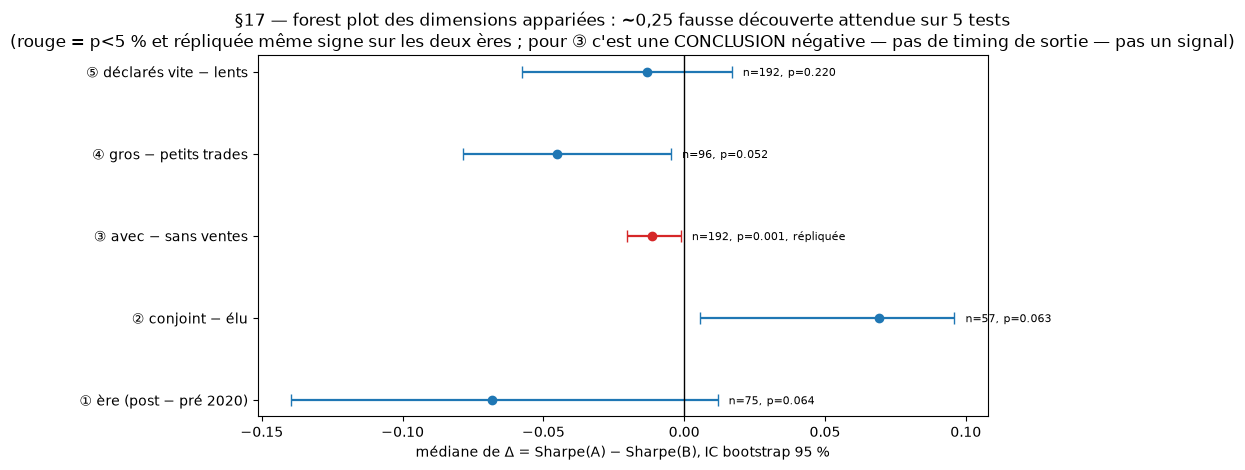

In [84]:
# §17 — RÉPLICATION par ère (systématique, dimensions ②-⑤) puis LE FOREST PLOT
rep17 = {}
for _nom in ["② conjoint − élu", "③ avec − sans ventes", "④ gros − petits trades", "⑤ déclarés vite − lents"]:
    _fn, _mn = SPLITS17[_nom]
    rep17[_nom] = {}
    for _lab, _lo, _hi in (("2014-19", 2013, 2019), ("2020-26", 2020, 2026)):
        _al = paired17(_fn, dd=df16[df16.traded.dt.year.between(_lo, _hi)], min_n=_mn)
        if len(_al) >= 10:
            _dz = _al.d[_al.d != 0]            # même convention qu'au bilan17 : ex æquo exclus du test de signe
            rep17[_nom][_lab] = dict(n=len(_al), med=_al.d.median(),
                                     p=sps.binomtest(int((_dz > 0).sum()), len(_dz), 0.5).pvalue)
        else:
            rep17[_nom][_lab] = dict(n=len(_al), med=np.nan, p=np.nan)
for _nom, _r in rep17.items():
    print(f"{_nom:26s}: " + " | ".join(f"{k} n={v['n']}, méd {v['med']:+.3f}, p {v['p']:.3f}" for k, v in _r.items()))

rng17 = np.random.default_rng(17)
def _ci_mediane17(d, B=2000):
    _meds = np.median(rng17.choice(d, size=(B, len(d)), replace=True), axis=1)
    return np.quantile(_meds, [.025, .975])

fig, ax = plt.subplots(figsize=(10, 4.8))
_noms = list(dims17)
_cis17 = {}                                    # IC tracés, gardés pour la validation (iv) du §17.1
for _i, _nom in enumerate(_noms):
    _dim = dims17[_nom]
    _lo, _hi = _ci_mediane17(_dim["d"]); _cis17[_nom] = (_lo, _hi)
    _rep = rep17.get(_nom, {})
    _rep_ok = all(np.isfinite(v["p"]) and v["p"] < .10 and np.sign(v["med"]) == np.sign(_dim["mediane"])
                  for v in _rep.values()) if _rep else False
    _c = "tab:red" if (_dim["p_signe"] < .05 and _rep_ok) else "tab:blue"
    ax.errorbar(_dim["mediane"], _i, xerr=[[_dim["mediane"] - _lo], [_hi - _dim["mediane"]]],
                fmt="o", color=_c, capsize=4, lw=1.6)
    ax.annotate(f"n={_dim['n']}, p={_dim['p_signe']:.3f}" + (", répliquée" if _rep_ok else ""),
                (_hi, _i), xytext=(8, -3), textcoords="offset points", fontsize=8)
ax.axvline(0, color="k", lw=1)
ax.set_yticks(range(len(_noms)), _noms)
ax.set_xlabel("médiane de Δ = Sharpe(A) − Sharpe(B), IC bootstrap 95 %")
ax.set_title("§17 — forest plot des dimensions appariées : ~0,25 fausse découverte attendue sur 5 tests\n"
             "(rouge = p<5 % et répliquée même signe sur les deux ères ; pour ③ c'est une CONCLUSION négative — pas de timing de sortie — pas un signal)")
plt.tight_layout(); plt.show()

### 17.1 Validation

$$\text{(i)}\ \text{membre sans vente : contrefactuel}\overset{!}{\equiv}\text{réel bit-à-bit}\ ;\quad
\text{(ii)}\ \text{recomptage owner d'un membre}\ ;\quad
\text{(iii)}\ p_{\text{signe}}\overset{!}{=}\text{binomiale exacte recalculée}\ ;\quad
\text{(iv)}\ \text{bootstrap déterministe (seed).}$$

In [85]:
# §17.1 — VALIDATION
# (i) propriété structurelle du contrefactuel « sans ventes » : sans vente, les parts par ticker ne
#     décroissent JAMAIS (vérifié sur le membre démo, boucle indépendante du moteur)
_g0 = df16[df16.bioguide_id == DEMO_BID]
_N0 = member_shares(_g0[_g0.op == "buy"][COLS16])
assert (_N0.diff().fillna(0.0) >= -1e-9).all().all(), "des parts décroissent sans vente"
# et le sous-portefeuille du split ③ == exactement les achats du membre (aucune vente ne fuit)
_a0, _b0 = _split_ventes17(_g0)
assert (_b0.op == "buy").all() and len(_b0) == int((_g0.op == "buy").sum())
# (ii) owner : la normalisation couvre TOUS les labels (0 NaN) et le recomptage du membre démo colle
assert int(df16.owner_n.isna().sum()) == 0
assert int((_g0.owner_n == "conjoint").sum()) == int(_g0.owner.isin(["Spouse", "SP"]).sum())
# (iii) oracle : le p du test de signe (scipy) == binomiale exacte « minlike » recalculée à la main (dimension ③)
_d3 = dims17["③ avec − sans ventes"]
_k, _n = int((_d3["d"] > 0).sum()), int((_d3["d"] != 0).sum())    # ex æquo exclus, comme bilan17
_pmf = sps.binom.pmf(np.arange(_n + 1), _n, 0.5)
_p_main = float(_pmf[_pmf <= _pmf[_k] * (1 + 1e-7)].sum())
assert abs(_d3["p_signe"] - min(1.0, _p_main)) < 1e-9
# (iv) reproductibilité du forest plot : on REJOUE le flux rng(17) séquentiel de la figure
#      et on doit retrouver exactement les IC tracés (ordre des dimensions compris)
_rng_chk = np.random.default_rng(17)
for _nom_chk in dims17:
    _d_chk = dims17[_nom_chk]["d"]
    _ci_chk = np.quantile(np.median(_rng_chk.choice(_d_chk, size=(2000, len(_d_chk)), replace=True), axis=1), [.025, .975])
    assert np.allclose(_ci_chk, _cis17[_nom_chk]), _nom_chk
print(f"validation OK | (i) parts jamais décroissantes sans vente ({DEMO}) + split ③ étanche | (ii) owner_n sans trou | "
      f"(iii) p signe ③ ≡ binomiale minlike ({_p_main:.2e}) | (iv) IC du forest plot reproduits en rejouant rng(17), "
      f"③ = {np.round(np.asarray(_cis17['③ avec − sans ventes']), 3)}")

validation OK | (i) parts jamais décroissantes sans vente (Nancy Pelosi) + split ③ étanche | (ii) owner_n sans trou | (iii) p signe ③ ≡ binomiale minlike (1.04e-03) | (iv) IC du forest plot reproduits en rejouant rng(17), ③ = [-0.02  -0.001]


### 17.2 Lecture

$$\text{5 dimensions appariées, }\sim0{,}25\text{ fausse découverte attendue : aucune ne livre un signal copiable}\ (\text{seule ③ est significative et répliquée — en négatif}).$$

- **① Ère** : le même membre fait légèrement *moins bien* post-2020 (médiane $\Delta=-0{,}07$, signe $p=0{,}064$,
  Wilcoxon $p=0{,}055$ — au bord du seuil sans le franchir) — un effet de **régime de marché**, pas un signal ; la config gagnante est stable et NS
  des deux côtés ($+2{,}7\,\%$/an $t\,0{,}63$ avant 2020, $+3{,}9\,\%$ $t\,0{,}86$ après).
- **② Conjoint vs élu** ($n=57$) : médiane $+0{,}07$, $p=0{,}063$ — le seul soupçon **cohérent en signe** sur les
  deux ères (médianes $+0{,}07$ et $+0{,}08$) mais répliqué à $p=0{,}081$ / $0{,}265$ : sous le critère. Le narratif
  « Pelosi » n'est ni démontré ni enterré — c'est la seule dimension à re-regarder si la table s'allonge.
- **③ Ventes** : la seule dimension qui **franchit le filtre statistique** (signe $72/190$, $p=0{,}001$,
  2 ex æquo structurels exclus ; répliqué $p=0{,}004$ / $0{,}050$) — mais dans le **mauvais sens** : le critère
  visait un avantage copiable, et un $\Delta$ **négatif** minuscule (médiane $-0{,}012$) est une **conclusion**
  (les sorties déclarées détruisent un peu de Sharpe, aucune information de sortie à copier), pas une Partie IV.
  L'ampleur est minuscule, la fenêtre haussière y contribue mécaniquement — cohérent avec la littérature.
- **④ Taille** : les **gros** trades du membre font *pires* que ses petits (médiane $-0{,}04$, $p=0{,}052$ —
  au-dessus du seuil), non répliqué post-2020 ($p=0{,}615$) — le narratif « gros trade $=$ informé » meurt (comme le $\ge250$ k\$
  clusterisé du notebook 03).
- **⑤ Délai de déclaration** : rien ($p=0{,}220$) — déclarer vite ne marque pas un trade « chaud ».
- **⑥ Parti / chambre / leadership** : médianes de Sharpe indistinguables (MW $p=0{,}21$ / $0{,}85$ / $0{,}60$ ;
  8 leaders seulement).
- **Décision (critère du §17)** : **zéro promotion** — seule ③ passe le filtre statistique, en négatif
  (une conclusion, pas un signal). L'inventaire des dimensions de la table est fermé :
  ni le qui (conjoint, parti, leadership), ni le comment (taille, ventes, délai), ni le quand (ère) ne portent
  un signal exploitable.